# 03 — Deep Learning Journey: 9 iterations (deep_1 → deep_9)

This notebook traces the full history of the 9 deep-learning iterations run on the
white blood cell classification project (13 classes, heavy imbalance — max/min class ratio
≈ 1183x). Each section summarises what changed in one iteration compared with the previous
one, followed by the key results.

Note: the code cells are excerpts from the original per-iteration notebooks (not included in
the repository), shown with their original saved outputs. This notebook is a record of the
experiments and is not meant to be re-executed top to bottom; the runnable pipeline lives in
`src/` and `notebooks/04_final_model.ipynb`.

Two milestones stand out:

- **deep_6** fixed the data leakage of deep_5 and gave the first trustworthy score
  (val macro-F1 = 0.6994).
- **deep_9 no-morph** (ConvNeXt-Base + SE-style attention gate + MLP head, no handcrafted
  morphology branch, HSV V-channel CLAHE preprocessing) is the **final model**: val
  macro-F1 = 0.7052, accuracy = 0.9367. It is reproduced in `notebooks/04_final_model.ipynb`
  (evaluation and inference from the saved checkpoint `models/best_model.pt`).

## deep_1 — EfficientNet-B3 Baseline

**Backbone**: EfficientNet-B3 (ImageNet). **Strategy**: 5-fold stratified CV, class-weighted
`CrossEntropyLoss` (1183x imbalance), `WeightedRandomSampler`, standard torchvision
augmentations (flips, rotation, color jitter, affine), and flip TTA at inference.

Result (re-run): val macro-F1 = **0.552**, accuracy = 0.716 on a single stratified 85/15 split
(15 epochs, no TTA). Rare classes remain very weak: BNE = 0.14, PLY = 0.25, VLY = 0.27,
MMY = 0.30, PC = 0.34.

Note: the original deep_1 notebook was saved without outputs; its score comes from a re-run on
a single stratified 85/15 split instead of the original 5-fold CV (`scripts/deep_1_rerun.py`,
results in `results/deep_1_rerun/`). The score is noisy: the validation macro-F1 still varied
between 0.44 and 0.55 over the last epochs, and an earlier unseeded run gave 0.489.

In [ ]:
# deep_1 — cell 4/9 of the original notebook (EfficientNet-B3 model definition)
# ============================================================
# 4. MODEL DEFINITION — EfficientNet-B3 (ImageNet)
# ============================================================

def create_model(num_classes, freeze_backbone=False):
    """EfficientNet-B3 pre-trained on ImageNet. Replace classifier head."""
    model = models.efficientnet_b3(weights=models.EfficientNet_B3_Weights.IMAGENET1K_V1)

    if freeze_backbone:
        for param in model.features.parameters():
            param.requires_grad = False

    # Replace classifier
    in_features = model.classifier[1].in_features
    model.classifier = nn.Sequential(
        nn.Dropout(p=0.4, inplace=True),
        nn.Linear(in_features, num_classes),
    )
    return model

# Quick test
_test_model = create_model(num_classes)
print(f"Model: EfficientNet-B3")
print(f"  Classifier input features: {_test_model.classifier[1].in_features}")
print(f"  Output classes: {num_classes}")
total_params = sum(p.numel() for p in _test_model.parameters())
trainable_params = sum(p.numel() for p in _test_model.parameters() if p.requires_grad)
print(f"  Total params: {total_params:,}")
print(f"  Trainable params: {trainable_params:,}")
del _test_model

In [ ]:
# deep_1 — cell 6/9 of the original notebook (5-fold training launch), excerpt
# ============================================================
# 6. RUN TRAINING (Stratified K-Fold)
# ============================================================

N_FOLDS = 5
BATCH_SIZE = 32
NUM_EPOCHS = 30
PATIENCE = 7
LR = 1e-4
WEIGHT_DECAY = 1e-4

dl_skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=42)
dl_labels = dl_le.transform(train_df['label'])

# Compute class weights for weighted loss
class_counts_dl = Counter(dl_labels)
total_samples = len(dl_labels)
class_weights = torch.tensor(
    [total_samples / (num_classes * class_counts_dl[i]) for i in range(num_classes)],
    dtype=torch.float32
).to(device)
print(f"Class weights: {class_weights.cpu().numpy().round(2)}")

# Store fold models and OOF predictions
fold_models = []
dl_oof_preds = np.zeros(len(train_df), dtype=int)
dl_oof_probs = np.zeros((len(train_df), num_classes), dtype=np.float32)
all_histories = []

for fold_idx, (train_idx, val_idx) in enumerate(dl_skf.split(train_df, dl_labels)):
    print(f"\n{'='*60}")
    print(f"FOLD {fold_idx + 1}/{N_FOLDS}")
    print(f"{'='*60}")

    train_fold_df = train_df.iloc[train_idx]
    val_fold_df = train_df.iloc[val_idx]
    print(f"  Train: {len(train_fold_df)}, Val: {len(val_fold_df)}")

    # Datasets & loaders
    train_ds = WBCDataset(train_fold_df, TRAIN_DIR, dl_le, train_transforms)
    val_ds = WBCDataset(val_fold_df, TRAIN_DIR, dl_le, val_transforms)
    ...  # (rest of the 5-fold loop omitted; same structure as the later iterations)

## deep_2 — CBAM Attention + Nucleus Cropping

**Backbone**: `timm` EfficientNet-B3 + **CBAM** (channel + spatial attention) to push the
network to focus on the nucleus. Adds a **crop around the nucleus** (runtime HSV
segmentation), domain-specific Albumentations augmentations (hue/saturation, CLAHE, 360°
rotation), Mixup and label smoothing. Two hybrid heads on top of the CNN features are
tested: **CNN+RF** and **CNN+SVM**.

Result: DL-only val macro-F1 = **0.552**, CNN+RF = 0.6315, CNN+SVM = **0.633** (best). Key
insight: an SVM trained on CNN features beats the plain softmax head for this backbone.

In [ ]:
# deep_2 — key change: CBAM block (channel + spatial attention) + hybrid CNN+SVM head
class ChannelAttention(nn.Module):
    def __init__(self, in_channels, reduction=16):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)
        self.fc = nn.Sequential(
            nn.Linear(in_channels, in_channels // reduction, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(in_channels // reduction, in_channels, bias=False),
        )

    def forward(self, x):
        b, c, _, _ = x.size()
        avg_out = self.fc(self.avg_pool(x).view(b, c))
        max_out = self.fc(self.max_pool(x).view(b, c))
        attn = torch.sigmoid(avg_out + max_out).view(b, c, 1, 1)
        return x * attn


class SpatialAttention(nn.Module):
    def __init__(self, kernel_size=7):
        super().__init__()
        self.conv = nn.Conv2d(2, 1, kernel_size, padding=kernel_size // 2, bias=False)

    def forward(self, x):
        avg_out = x.mean(dim=1, keepdim=True)
        max_out = x.max(dim=1, keepdim=True)[0]
        attn = torch.sigmoid(self.conv(torch.cat([avg_out, max_out], dim=1)))
        return x * attn


class CBAM(nn.Module):
    def __init__(self, in_channels, reduction=16, kernel_size=7):
        super().__init__()
        self.channel_attn = ChannelAttention(in_channels, reduction)
        self.spatial_attn = SpatialAttention(kernel_size)

    def forward(self, x):
        x = self.channel_attn(x)
        x = self.spatial_attn(x)
        return x

# --- Choice of the best head on top of the CNN (new compared with deep_1) ---
rf = RandomForestClassifier(n_estimators=500, class_weight='balanced', n_jobs=-1, random_state=42)
svm = SVC(kernel='rbf', C=10.0, gamma='scale', class_weight='balanced', random_state=42)
# compare DL-only vs CNN-features+RF vs CNN-features+SVM -> keep the best

Val features shape: (4336, 384)
Train features shape: (24565, 384)

Hybrid CNN+RF val macro-F1:  0.6315
Hybrid CNN+SVM val macro-F1: 0.6330
DL-only val macro-F1:        0.5523

★ Best approach: CNN+SVM (macro-F1=0.6330)


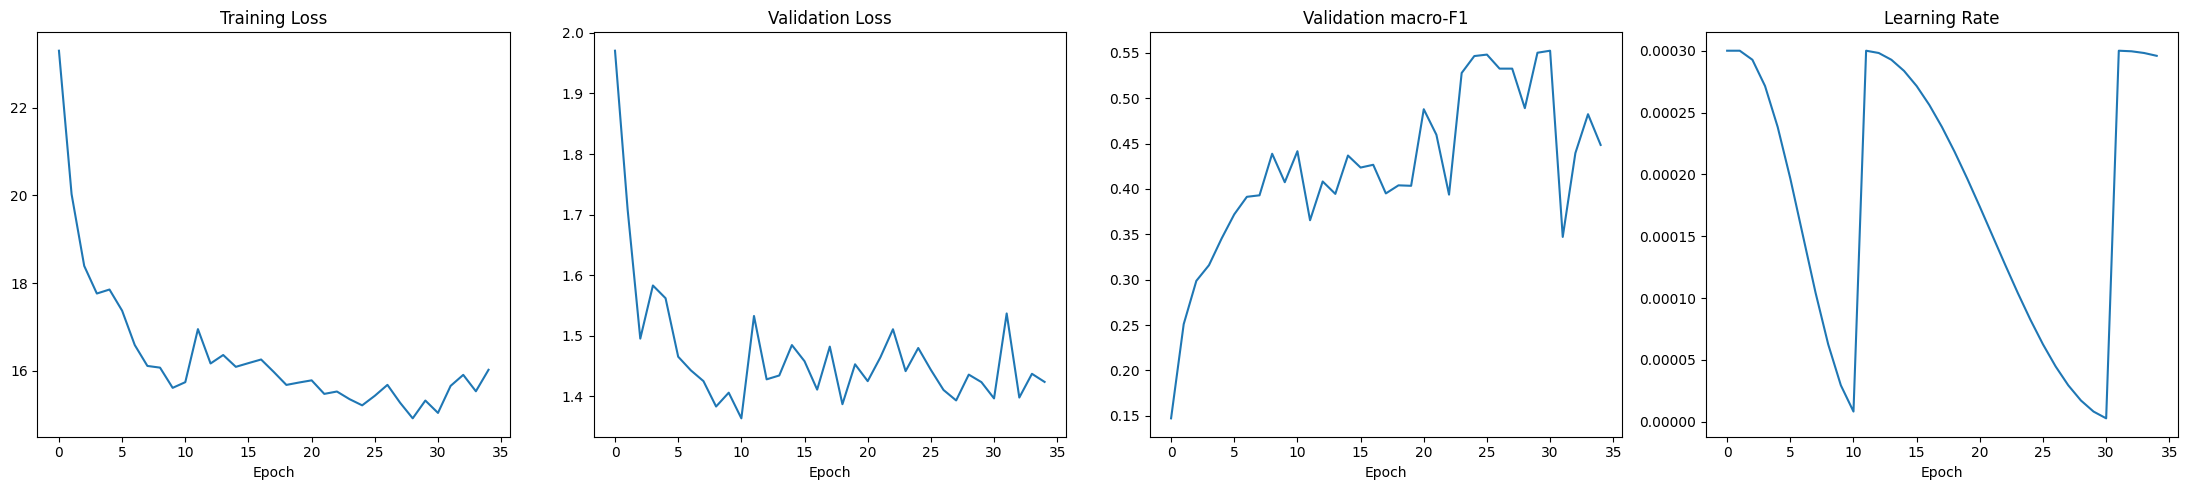

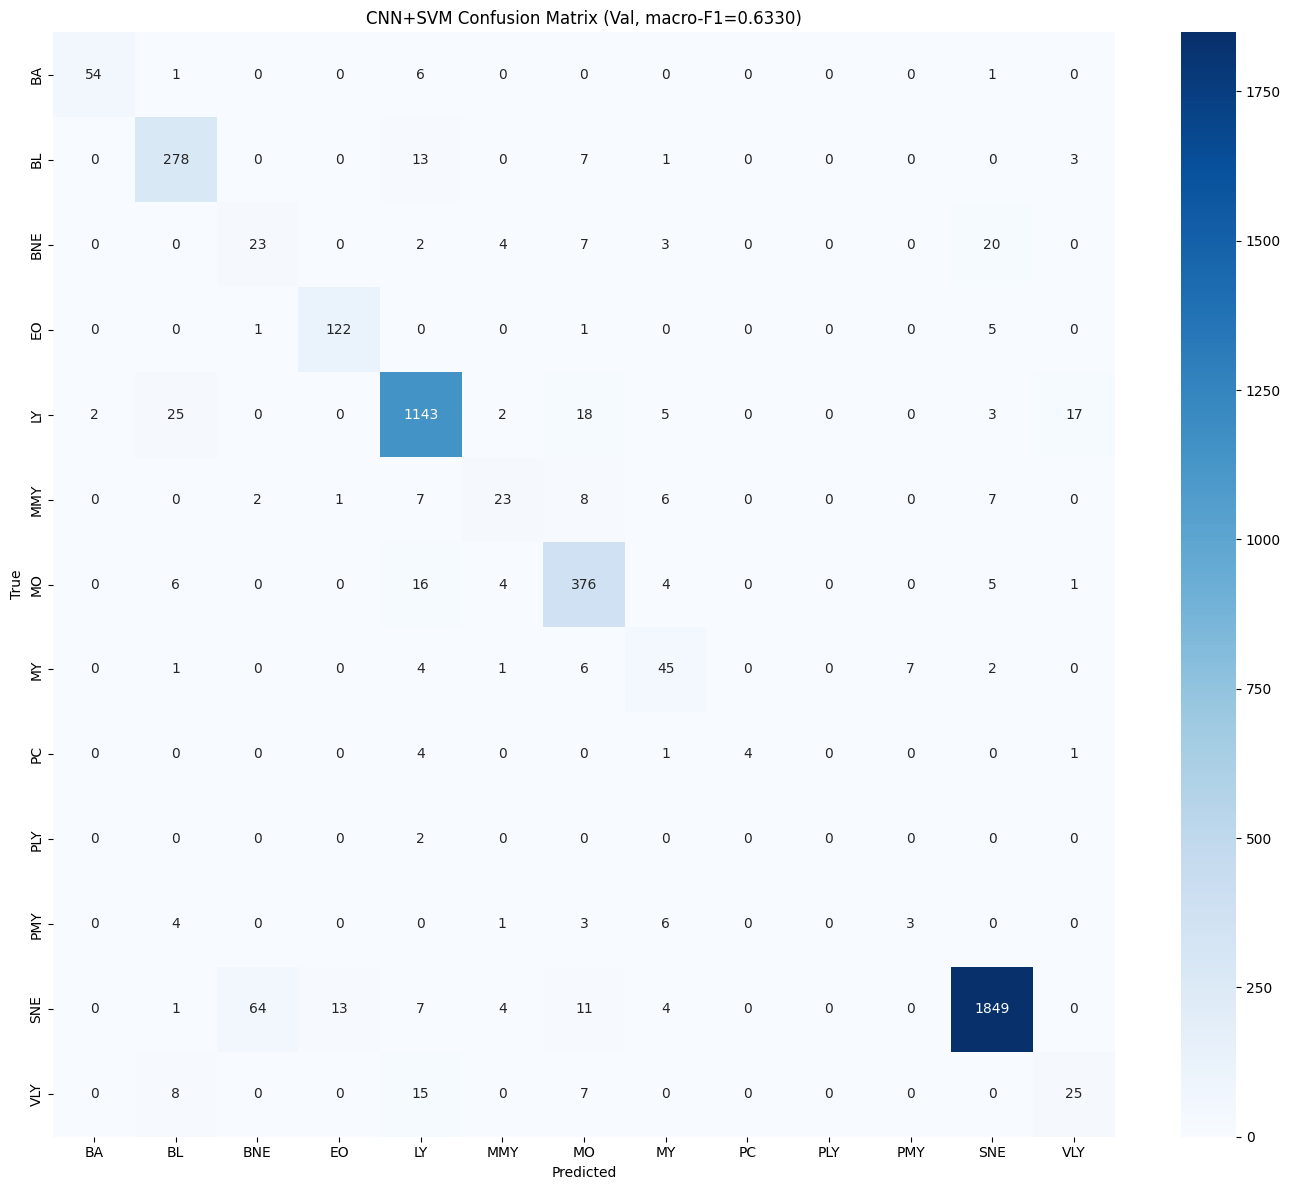

Per-class F1 scores (CNN+SVM):
  BA   (n=   62): F1 = 0.9153
  BL   (n=  302): F1 = 0.8882
  BNE  (n=   59): F1 = 0.3087
  EO   (n=  129): F1 = 0.9208
  LY   (n= 1215): F1 = 0.9392
  MMY  (n=   54): F1 = 0.4946
  MO   (n=  412): F1 = 0.8785
  MY   (n=   66): F1 = 0.6383
  PC   (n=   10): F1 = 0.5714
  PLY  (n=    2): F1 = 0.0000
  PMY  (n=   17): F1 = 0.2222
  SNE  (n= 1953): F1 = 0.9618
  VLY  (n=   55): F1 = 0.4902


In [ ]:
# ============================================================
# 7. HYBRID APPROACH: CNN Features → Random Forest / SVM
# ============================================================

print(f"Val features shape: {val_features.shape}")

# ---- Extract train features ----
train_features_list = []
model.eval()
with torch.no_grad():
    for imgs, _ in DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=False,
                               num_workers=4, pin_memory=True):
        imgs = imgs.to(device)
        train_features_list.append(model.extract_features(imgs).cpu().numpy())
train_features = np.concatenate(train_features_list)
train_labels_enc = dl_labels[train_idx]
print(f"Train features shape: {train_features.shape}")

# ---- Random Forest ----
rf = RandomForestClassifier(n_estimators=500, max_depth=None, min_samples_leaf=2,
                             class_weight='balanced', n_jobs=-1, random_state=42)
rf.fit(train_features, train_labels_enc)
rf_val_preds = rf.predict(val_features)
rf_val_f1 = f1_score(val_labels, rf_val_preds, average='macro')
print(f"\nHybrid CNN+RF val macro-F1:  {rf_val_f1:.4f}")

# ---- SVM ----
scaler = StandardScaler()
train_scaled = scaler.fit_transform(train_features)
val_scaled = scaler.transform(val_features)

svm = SVC(kernel='rbf', C=10.0, gamma='scale', class_weight='balanced',
          decision_function_shape='ovr', random_state=42)
svm.fit(train_scaled, train_labels_enc)
svm_val_preds = svm.predict(val_scaled)
svm_val_f1 = f1_score(val_labels, svm_val_preds, average='macro')
print(f"Hybrid CNN+SVM val macro-F1: {svm_val_f1:.4f}")
print(f"DL-only val macro-F1:        {val_f1:.4f}")

# ---- Choose best ----
best_approach = max(
    [('DL', val_f1, val_preds),
     ('CNN+RF', rf_val_f1, rf_val_preds),
     ('CNN+SVM', svm_val_f1, svm_val_preds)],
    key=lambda x: x[1]
)
print(f"\n★ Best approach: {best_approach[0]} (macro-F1={best_approach[1]:.4f})")
USE_HYBRID = best_approach[0]
final_val_f1 = best_approach[1]

# ---- Training curves ----
fig, axes = plt.subplots(1, 4, figsize=(22, 5))
for data, ax, title in zip(
    [history['train_loss'], history['val_loss'], history['val_f1'], history['lr']],
    axes, ['Training Loss', 'Validation Loss', 'Validation macro-F1', 'Learning Rate']):
    ax.plot(data)
    ax.set_title(title)
    ax.set_xlabel('Epoch')
plt.tight_layout()
plt.show()

# ---- Confusion Matrix ----
cm = confusion_matrix(val_labels, best_approach[2])
fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=dl_le.classes_, yticklabels=dl_le.classes_, ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_title(f'{best_approach[0]} Confusion Matrix (Val, macro-F1={final_val_f1:.4f})')
plt.tight_layout()
plt.show()

# Per-class F1
print(f"Per-class F1 scores ({best_approach[0]}):")
f1_per_class = f1_score(val_labels, best_approach[2], average=None)
for cls_name, f1_val in zip(dl_le.classes_, f1_per_class):
    count = np.sum(val_labels == dl_le.transform([cls_name])[0])
    print(f"  {cls_name:4s} (n={count:5d}): F1 = {f1_val:.4f}")

## deep_3 — Late Fusion + Wiener/Laplacian filtering + 4th channel

Two-branch **Late Fusion** architecture: a 4-channel image (RGB + nucleus mask, preprocessed
with a Wiener filter + Laplacian sharpening) fed to the CNN+CBAM, and an MLP on 8 nucleus
morphometry features (roundness, solidity, compactness, eccentricity, cytoplasm/nucleus
ratio, ...). Both embeddings are concatenated before the final classifier.

Result: DL-only = 0.552, **Fused+SVM = 0.641** (+0.008 vs deep_2). The extra complexity brings
no meaningful gain (+0.008 is within the noise of the validation split).

In [ ]:
# deep_3 — key change: Wiener/Laplacian filtering, nucleus mask as 4th channel, 8-feature morphometry MLP (Late Fusion)
# Wiener + Laplacian preprocessing (new compared with deep_2) ----------------
def wiener_laplacian_preprocess(img, wiener_size=5, laplacian_weight=0.3):
    """Wiener denoising followed by Laplacian edge enhancement
    (paper 'Statistical Pattern Analysis of WBC Nuclei Morphometry', 2010)."""
    ...

# Nucleus mask added as a 4th channel (RGBM) ---------------------------------
USE_NUCLEUS_MASK_CHANNEL = True
NUM_HANDCRAFTED = 8   # roundness, solidity, compactness, eccentricity,
                       # C/N ratio, norm_area, norm_perimeter, extent
IN_CHANS = 4 if USE_NUCLEUS_MASK_CHANNEL else 3

# Late Fusion architecture: 2 branches ---------------------------------------
class WBCClassifier(nn.Module):
    """Late Fusion: branch 1 = CNN (4 channels) + CBAM  |  branch 2 = MLP (8 features)
    Fusion = concat(image_embedding, morpho_embedding) -> final classifier."""
    def __init__(self, num_classes, backbone='efficientnet_b3', dropout=0.5):
        super().__init__()
        self.cnn = timm.create_model(backbone, pretrained=True, in_chans=IN_CHANS, num_classes=0)
        self.cbam = CBAM(self.cnn.num_features)
        self.mlp_handcrafted = nn.Sequential(
            nn.Linear(NUM_HANDCRAFTED, 64), nn.ReLU(),
            nn.Linear(64, 32), nn.ReLU(),
        )
        # fusion: concat(cnn_features, mlp_features) -> classifier

Val fused features shape: (4336, 416)


Train fused features shape: (24565, 416)

Hybrid FusedFeatures+RF val macro-F1:  0.6282
Hybrid FusedFeatures+SVM val macro-F1: 0.6414
DL Late Fusion val macro-F1:           0.5517

★ Best approach: Fused+SVM (macro-F1=0.6414)


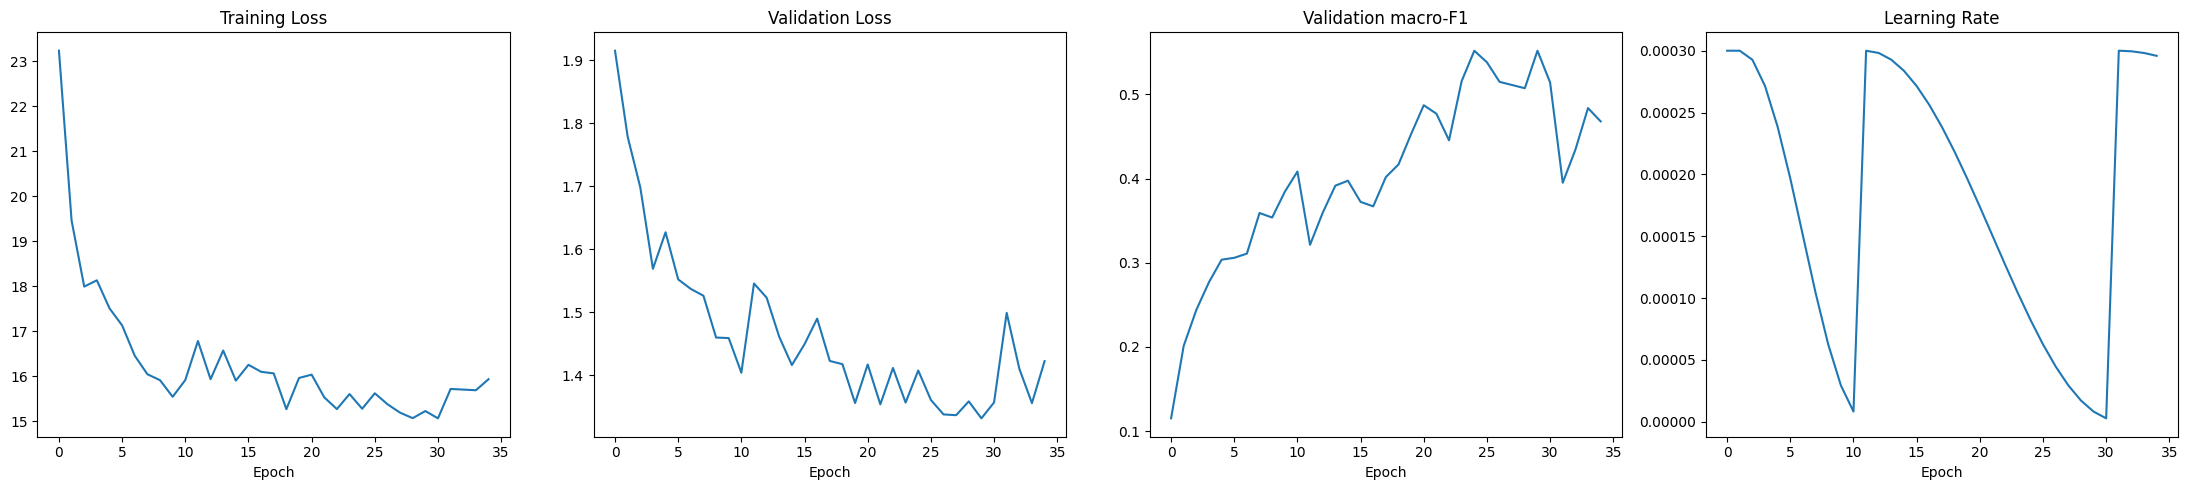

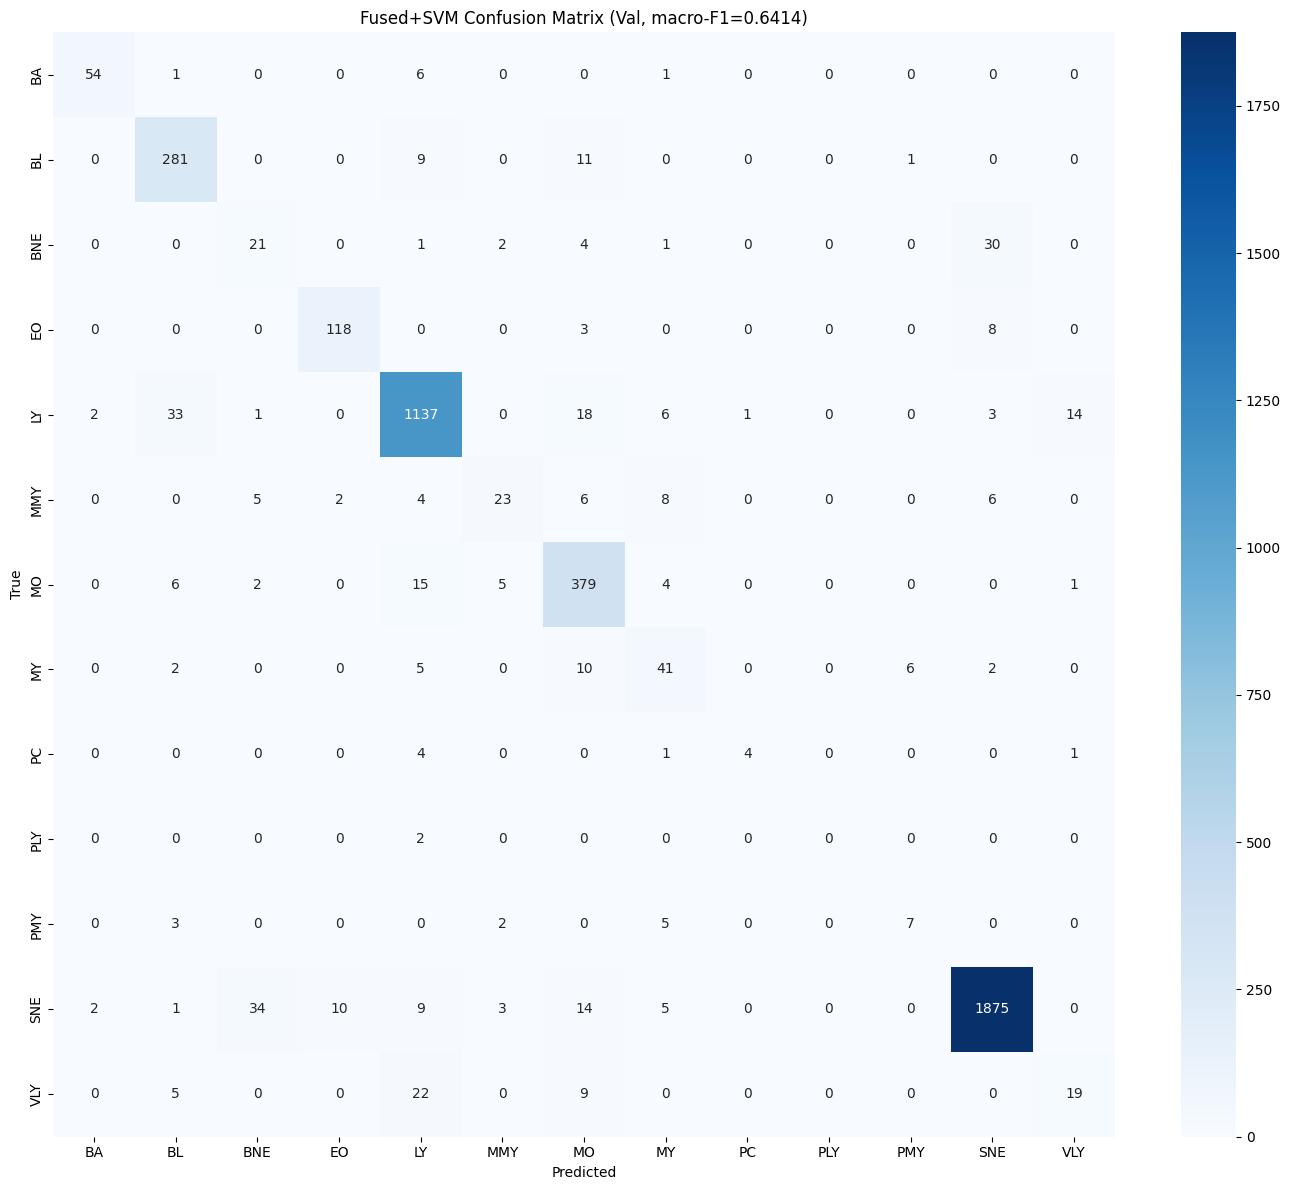

Per-class F1 scores (Fused+SVM):
  BA   (n=   62): F1 = 0.9000
  BL   (n=  302): F1 = 0.8864
  BNE  (n=   59): F1 = 0.3443
  EO   (n=  129): F1 = 0.9112
  LY   (n= 1215): F1 = 0.9362
  MMY  (n=   54): F1 = 0.5169
  MO   (n=  412): F1 = 0.8753
  MY   (n=   66): F1 = 0.5942
  PC   (n=   10): F1 = 0.5333
  PLY  (n=    2): F1 = 0.0000
  PMY  (n=   17): F1 = 0.4516
  SNE  (n= 1953): F1 = 0.9672
  VLY  (n=   55): F1 = 0.4222


In [ ]:
# ============================================================
# 7. HYBRID APPROACH: Fused Features → Random Forest / SVM
# ============================================================

print(f"Val fused features shape: {val_features.shape}")

# ---- Extract train fused features ----
train_features_list = []
model.eval()
with torch.no_grad():
    for imgs, hc_features, _ in DataLoader(train_ds, batch_size=BATCH_SIZE,
                                            shuffle=False, num_workers=4,
                                            pin_memory=True):
        imgs = imgs.to(device)
        hc_features = hc_features.to(device)
        train_features_list.append(
            model.extract_features(imgs, hc_features).cpu().numpy())
train_features = np.concatenate(train_features_list)
train_labels_enc = dl_labels[train_idx]
print(f"Train fused features shape: {train_features.shape}")

# ---- Random Forest ----
rf = RandomForestClassifier(n_estimators=500, max_depth=None, min_samples_leaf=2,
                             class_weight='balanced', n_jobs=-1, random_state=42)
rf.fit(train_features, train_labels_enc)
rf_val_preds = rf.predict(val_features)
rf_val_f1 = f1_score(val_labels, rf_val_preds, average='macro')
print(f"\nHybrid FusedFeatures+RF val macro-F1:  {rf_val_f1:.4f}")

# ---- SVM ----
scaler = StandardScaler()
train_scaled = scaler.fit_transform(train_features)
val_scaled = scaler.transform(val_features)

svm = SVC(kernel='rbf', C=10.0, gamma='scale', class_weight='balanced',
          decision_function_shape='ovr', random_state=42)
svm.fit(train_scaled, train_labels_enc)
svm_val_preds = svm.predict(val_scaled)
svm_val_f1 = f1_score(val_labels, svm_val_preds, average='macro')
print(f"Hybrid FusedFeatures+SVM val macro-F1: {svm_val_f1:.4f}")
print(f"DL Late Fusion val macro-F1:           {val_f1:.4f}")

# ---- Choose best ----
best_approach = max(
    [('LateFusion-DL', val_f1, val_preds),
     ('Fused+RF', rf_val_f1, rf_val_preds),
     ('Fused+SVM', svm_val_f1, svm_val_preds)],
    key=lambda x: x[1]
)
print(f"\n★ Best approach: {best_approach[0]} (macro-F1={best_approach[1]:.4f})")
USE_HYBRID = best_approach[0]
final_val_f1 = best_approach[1]

# ---- Training curves ----
fig, axes = plt.subplots(1, 4, figsize=(22, 5))
for data, ax, title in zip(
    [history['train_loss'], history['val_loss'], history['val_f1'], history['lr']],
    axes, ['Training Loss', 'Validation Loss', 'Validation macro-F1', 'Learning Rate']):
    ax.plot(data)
    ax.set_title(title)
    ax.set_xlabel('Epoch')
plt.tight_layout()
plt.show()

# ---- Confusion Matrix ----
cm = confusion_matrix(val_labels, best_approach[2])
fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=dl_le.classes_, yticklabels=dl_le.classes_, ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_title(f'{best_approach[0]} Confusion Matrix (Val, macro-F1={final_val_f1:.4f})')
plt.tight_layout()
plt.show()

# Per-class F1
print(f"Per-class F1 scores ({best_approach[0]}):")
f1_per_class = f1_score(val_labels, best_approach[2], average=None)
for cls_name, f1_val in zip(dl_le.classes_, f1_per_class):
    count = np.sum(val_labels == dl_le.transform([cls_name])[0])
    print(f"  {cls_name:4s} (n={count:5d}): F1 = {f1_val:.4f}")

## deep_4 — "Paper 2014" segmentation (failed experiment)

The nucleus segmentation is replaced by a published pipeline: grayscale → contrast
stretching + histogram equalisation → addition/subtraction to isolate the nucleus →
minimum filter → Otsu thresholding → morphological closing → removal of cells touching the
image border. The handcrafted features are reduced to **4** (area, perimeter, eccentricity,
circularity) instead of 8.

Result: val macro-F1 = **0.591** (Fused+RF), worse than deep_3 (0.641) on almost every
class. Insight: classical segmentation generalises poorly, which motivated dropping manual
feature engineering in the following iterations.

Note: in the original run, the kernel crashed at the end of the submission cell, after the
submission CSV had been written; the crash message is omitted from the output below.

In [ ]:
# deep_4 — key change (and regression): 'paper 2014' segmentation pipeline replacing the HSV crop, only 4 features
def segment_nucleus_paper2014(img_rgb):
    """Segmentation pipeline from the 2014 paper:
    1. Grayscale
    2. Contrast stretching (min-max normalisation to [0, 255])
    3. Histogram equalisation
    4. Addition (stretched + equalised) -> brightens the background
    5. Subtraction of the original grayscale -> isolates the dark nucleus
    6. 3x3 minimum filter -> reduces noise, enhances the nucleus
    7. Otsu thresholding -> binary mask
    8. Morphological closing -> fills holes in the nucleus
    9. clear_border -> removes cells touching the image border
    """
    gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY)
    gmin, gmax = gray.min(), gray.max()
    contrast_stretched = ((gray - gmin) / (gmax - gmin) * 255).astype(np.uint8) if gmax > gmin else gray.copy()
    hist_equalized = cv2.equalizeHist(gray)
    added = cv2.add(contrast_stretched, hist_equalized)
    subtracted = cv2.subtract(added, gray)
    filtered = minimum_filter(subtracted, size=3).astype(np.uint8)
    _, binary = cv2.threshold(filtered, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7, 7))
    closed = cv2.morphologyEx(binary, cv2.MORPH_CLOSE, kernel)
    mask = clear_border(closed)
    return mask
    # -> only 4 features extracted: Area, Perimeter, Eccentricity, Circularity
NUM_HANDCRAFTED = 4  # instead of 8 in deep_3

# NOTE: class weights removed from the loss (correcting twice, together with the
# WeightedRandomSampler, caused NaN losses through exploding gradients)
print("Class weights: NONE (WeightedRandomSampler handles imbalance)")

Val fused features shape: (4336, 400)


Train fused features shape: (24565, 400)

Hybrid FusedFeatures+RF val macro-F1:  0.5906
Hybrid FusedFeatures+SVM val macro-F1: 0.5854
DL Late Fusion val macro-F1:           0.5504

★ Best approach: Fused+RF (macro-F1=0.5906)


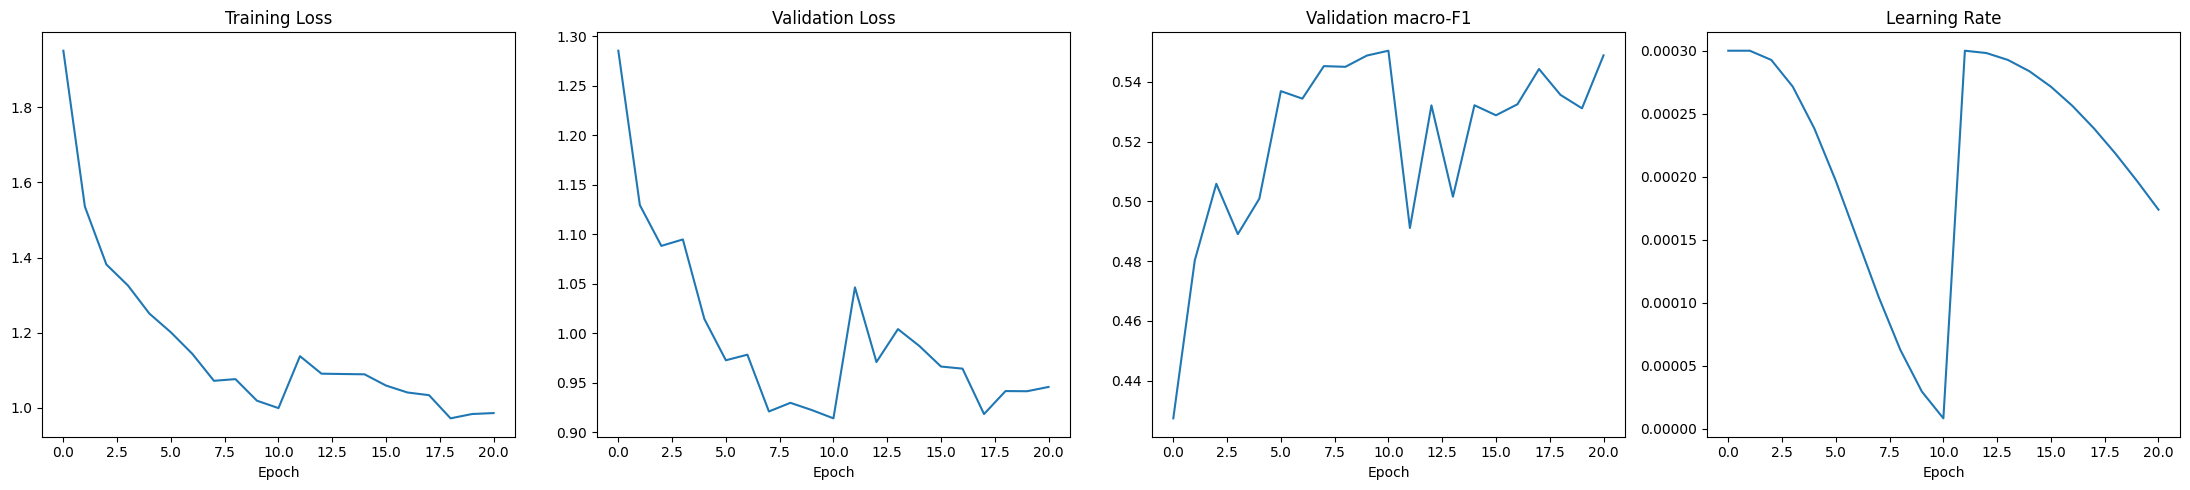

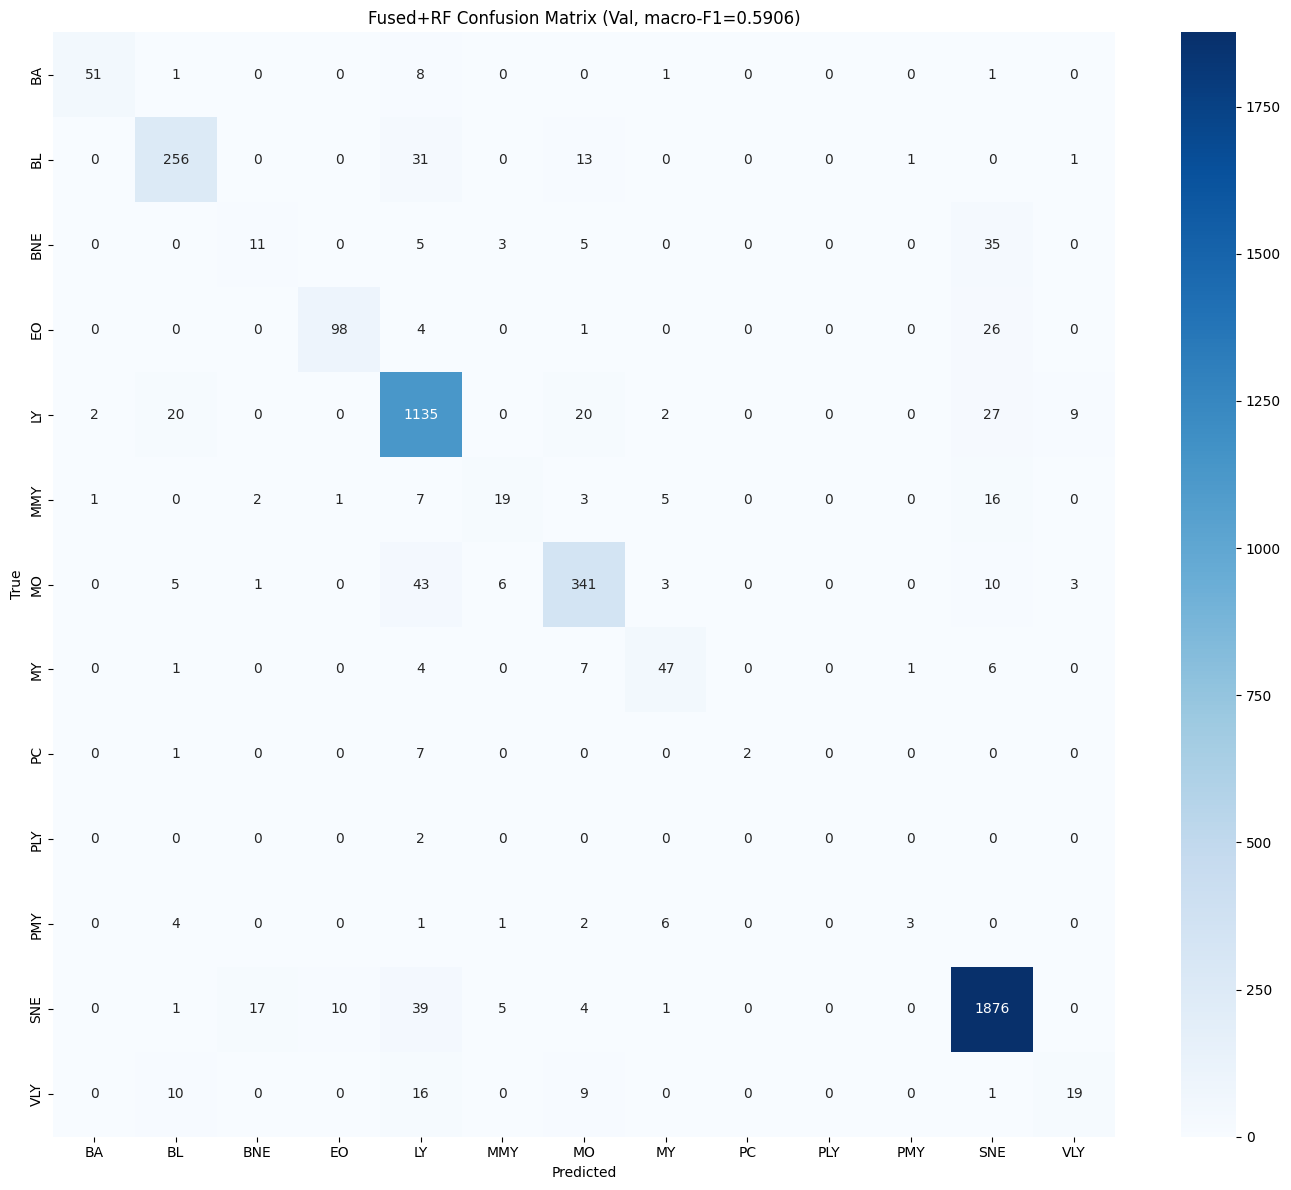

Per-class F1 scores (Fused+RF):
  BA   (n=   62): F1 = 0.8793
  BL   (n=  302): F1 = 0.8519
  BNE  (n=   59): F1 = 0.2444
  EO   (n=  129): F1 = 0.8235
  LY   (n= 1215): F1 = 0.9019
  MMY  (n=   54): F1 = 0.4318
  MO   (n=  412): F1 = 0.8348
  MY   (n=   66): F1 = 0.7176
  PC   (n=   10): F1 = 0.3333
  PLY  (n=    2): F1 = 0.0000
  PMY  (n=   17): F1 = 0.2727
  SNE  (n= 1953): F1 = 0.9496
  VLY  (n=   55): F1 = 0.4368


In [ ]:
# ============================================================
# 7. HYBRID APPROACH: Fused Features → Random Forest / SVM
# ============================================================

print(f"Val fused features shape: {val_features.shape}")

# ---- Extract train fused features ----
train_features_list = []
model.eval()
with torch.no_grad():
    for imgs, hc_features, _ in DataLoader(train_ds, batch_size=BATCH_SIZE,
                                            shuffle=False, num_workers=4,
                                            pin_memory=True):
        imgs = imgs.to(device)
        hc_features = hc_features.to(device)
        train_features_list.append(
            model.extract_features(imgs, hc_features).cpu().numpy())
train_features = np.concatenate(train_features_list)
train_labels_enc = dl_labels[train_idx]
print(f"Train fused features shape: {train_features.shape}")

# ---- Random Forest ----
rf = RandomForestClassifier(n_estimators=500, max_depth=None, min_samples_leaf=2,
                             class_weight='balanced', n_jobs=-1, random_state=42)
rf.fit(train_features, train_labels_enc)
rf_val_preds = rf.predict(val_features)
rf_val_f1 = f1_score(val_labels, rf_val_preds, average='macro')
print(f"\nHybrid FusedFeatures+RF val macro-F1:  {rf_val_f1:.4f}")

# ---- SVM ----
scaler = StandardScaler()
train_scaled = scaler.fit_transform(train_features)
val_scaled = scaler.transform(val_features)

svm = SVC(kernel='rbf', C=10.0, gamma='scale', class_weight='balanced',
          decision_function_shape='ovr', random_state=42)
svm.fit(train_scaled, train_labels_enc)
svm_val_preds = svm.predict(val_scaled)
svm_val_f1 = f1_score(val_labels, svm_val_preds, average='macro')
print(f"Hybrid FusedFeatures+SVM val macro-F1: {svm_val_f1:.4f}")
print(f"DL Late Fusion val macro-F1:           {val_f1:.4f}")

# ---- Choose best ----
best_approach = max(
    [('LateFusion-DL', val_f1, val_preds),
     ('Fused+RF', rf_val_f1, rf_val_preds),
     ('Fused+SVM', svm_val_f1, svm_val_preds)],
    key=lambda x: x[1]
)
print(f"\n★ Best approach: {best_approach[0]} (macro-F1={best_approach[1]:.4f})")
USE_HYBRID = best_approach[0]
final_val_f1 = best_approach[1]

# ---- Training curves ----
fig, axes = plt.subplots(1, 4, figsize=(22, 5))
for data, ax, title in zip(
    [history['train_loss'], history['val_loss'], history['val_f1'], history['lr']],
    axes, ['Training Loss', 'Validation Loss', 'Validation macro-F1', 'Learning Rate']):
    ax.plot(data)
    ax.set_title(title)
    ax.set_xlabel('Epoch')
plt.tight_layout()
plt.show()

# ---- Confusion Matrix ----
cm = confusion_matrix(val_labels, best_approach[2])
fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=dl_le.classes_, yticklabels=dl_le.classes_, ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_title(f'{best_approach[0]} Confusion Matrix (Val, macro-F1={final_val_f1:.4f})')
plt.tight_layout()
plt.show()

# Per-class F1
print(f"Per-class F1 scores ({best_approach[0]}):")
f1_per_class = f1_score(val_labels, best_approach[2], average=None)
for cls_name, f1_val in zip(dl_le.classes_, f1_per_class):
    count = np.sum(val_labels == dl_le.transform([cls_name])[0])
    print(f"  {cls_name:4s} (n={count:5d}): F1 = {f1_val:.4f}")

In [ ]:
# ============================================================
# 9. GENERATE SUBMISSION CSV
# ============================================================

print(f"Best approach: {USE_HYBRID}")
print(f"Val macro-F1:  {final_val_f1:.4f}")

final_submission = pd.DataFrame({
    'ID': test_df['ID'],
    'label': dl_test_labels
})

print(f"\nSubmission shape: {final_submission.shape}")
print(f"Sample sub shape: {sample_sub.shape}")
print(f"\nFirst rows:")
print(final_submission.head(10))

print("\nPrediction distribution:")
pred_counts = final_submission['label'].value_counts()
for cls, count in pred_counts.items():
    print(f"  {cls:4s}: {count:5d}")

output_path = BASE_DIR / "submission.csv"
final_submission.to_csv(output_path, index=False)
print(f"\nSubmission saved: {output_path}")
print(f"  {len(final_submission)} rows, columns: {list(final_submission.columns)}")

# ---- Summary ----
print(f"\n{'='*60}")
print("IMPROVEMENTS APPLIED:")
print(f"{'='*60}")
print("Paper 2014 — Morphological analysis of leukocyte nuclei:")
print(f"  1. Segmentation: contrast stretch + hist eq + add/sub + min filter + Otsu")
print(f"  2. Morphological closing + clear border cells")
print(f"  3. 360° rotation invariance (orientation non-discriminative)")
print(f"  4. Late Fusion: CNN branch + MLP branch")
print(f"     MLP features ({NUM_HANDCRAFTED}): Area, Perimeter, Eccentricity, Circularity")
print(f"  5. Nucleus mask as 4th channel (RGBM): {USE_NUCLEUS_MASK_CHANNEL}")
print(f"  6. Nucleus cropping (CenterCrop on darkest region)")
print("Al-Dulaimi et al. (2018):")
print(f"  7. Transfer Learning: {BACKBONE} (ImageNet pretrained)")
print(f"  8. CBAM Spatial Attention (nucleus focus)")
print(f"  9. Staining augmentation: HueSaturationValue, RGBShift, ColorJitter")
print(f" 10. Label Smoothing: {LABEL_SMOOTHING}")
print(f" 11. Mixup: alpha={MIXUP_ALPHA}")
print(f" 12. Dropout: {DROPOUT}, Weight Decay: {WEIGHT_DECAY}")
print(f" 13. Cosine Annealing LR, TTA: {len(tta_augs)} variants")
print(f" 14. Hybrid: Fused features → RF + SVM tested")
print(f"{'='*60}")
print(f"\n⚠️  K-Fold DISABLED for fast iteration.")

Best approach: Fused+RF
Val macro-F1:  0.5906

Submission shape: (9634, 2)
Sample sub shape: (9634, 3)

First rows:
               ID label
0  test_00000.png    LY
1  test_00001.png    BL
2  test_00002.png   SNE
3  test_00003.png   SNE
4  test_00004.png    LY
5  test_00005.png    MO
6  test_00006.png   SNE
7  test_00007.png    LY
8  test_00008.png   SNE
9  test_00009.png    BA

Prediction distribution:
  SNE :  4436
  LY  :  2904
  MO  :   883
  BL  :   659
  EO  :   250
  MY  :   137
  BA  :   123
  BNE :    79
  MMY :    76
  VLY :    62
  PMY :    15
  PC  :     9
  PLY :     1

Submission saved: submission.csv
  9634 rows, columns: ['ID', 'label']

IMPROVEMENTS APPLIED:
Paper 2014 — Morphological analysis of leukocyte nuclei:
  1. Segmentation: contrast stretch + hist eq + add/sub + min filter + Otsu
  2. Morphological closing + clear border cells
  3. 360° rotation invariance (orientation non-discriminative)
  4. Late Fusion: CNN branch + MLP branch
     MLP features (4): Area, Pe

## deep_5 — Pivot to ConvNeXt + discovery of a data leak

A radical change: manual feature engineering and CBAM are dropped in favour of a
**ConvNeXt-Base** backbone + simple MLP head, **Focal Loss**, **CutMix + Mixup** (disabled on
rare classes), **2-phase** training (warmup with frozen backbone → full fine-tuning), and
**offline oversampling** of rare classes (pre-cropped images written to disk before
training).

Apparent result: val macro-F1 = **0.822** (`Loaded checkpoint: epoch 8, val_f1=0.8217`).
This score is **inflated by data leakage**: augmented offline copies of the same original
image ended up in both train and validation, because the train/val split was made *after*
the augmentations were generated on disk. The leak is fixed in deep_6.

Note: the original deep_5 training run was interrupted manually, and its hybrid-approach
cell still held stale outputs from deep_4, so the only reliable deep_5 score is the checkpoint
reload shown below.

In [ ]:
# deep_5 — key change: pivot to ConvNeXt-Base, Focal Loss, CutMix, 2-phase training, offline oversampling (source of the leak fixed in deep_6)
class WBCClassifier(nn.Module):
    """ConvNeXt-Base + simple MLP head (new: CBAM and feature engineering dropped)."""
    def __init__(self, num_classes=13, dropout=0.3, pretrained=True):
        super().__init__()
        weights = ConvNeXt_Base_Weights.DEFAULT if pretrained else None
        full_model = convnext_base(weights=weights)
        self.backbone = nn.Sequential(full_model.features, full_model.avgpool)
        # ... 3-layer MLP head, no CBAM, no late fusion

# ---- Focal Loss (replaces the weighted cross-entropy) ----
class FocalLoss(nn.Module):
    def __init__(self, weight=None, gamma=2.0, label_smoothing=0.05):
        super().__init__()
        self.gamma = float(gamma)
        self.ce = nn.CrossEntropyLoss(weight=weight, label_smoothing=label_smoothing, reduction="none")

    def forward(self, logits, targets):
        ce = self.ce(logits, targets)
        pt = torch.exp(-ce)
        return (((1.0 - pt) ** self.gamma) * ce).mean()

# ---- CutMix (combined with Mixup, disabled on rare classes) ----
def cutmix_data(x, y, alpha=1.0):
    lam = np.random.beta(alpha, alpha) if alpha > 0 else 1.0
    index = torch.randperm(x.size(0), device=x.device)
    ...
    return mixed_x, y, y[index], lam

# ---- 2-phase training ----
# Phase 1 (warmup): backbone FROZEN, only the MLP head is trained
# Phase 2 (finetune): backbone UNFROZEN, lower LR
# ---- Offline oversampling (new): rare-class augmentations written to disk
# BEFORE the train/val split -> this is the source of the data leak fixed in deep_6

In [ ]:
# Excerpt: the original cell first re-created the model and reloaded its checkpoint,
# which printed the model summary shown at the top of the output.
# ============================================================
# 8. TEST SET PREDICTION (Stochastic TTA — 8 rounds)
# ============================================================
# If training was interrupted, load best checkpoint from disk.
# Just run cells 1-4 to define classes/model, then skip to here.
# ============================================================

CKPT_PATH = Path("models/best_model.pt")  # shared checkpoint path used by the original runs

# Load checkpoint if model wasn't trained in this session
if CKPT_PATH.exists():
    ckpt = torch.load(str(CKPT_PATH), map_location=device, weights_only=True)
    # Rebuild model if needed (e.g. after restart)
    try:
        model
    except NameError:
        model = WBCClassifier(num_classes=num_classes, dropout=0.3, pretrained=False)
    model.load_state_dict(ckpt['model_state_dict'])
    print(f"Loaded checkpoint: epoch {ckpt['epoch']}, val_f1={ckpt['val_f1']:.4f}")
else:
    print("No checkpoint found, using model from training.")

# Default to DL approach if hybrid wasn't computed
try:
    USE_HYBRID
except NameError:
    USE_HYBRID = 'ConvNeXt-DL'

# Default BATCH_SIZE if cell 6 was skipped
try:
    BATCH_SIZE
except NameError:
    BATCH_SIZE = 64

print(f"Predicting on test set with {TTA_ROUNDS} TTA rounds (approach: {USE_HYBRID})...")

model = model.to(device)
model.eval()

# Base prediction (no augmentation)
test_ds_base = WBCDataset(test_df, TEST_DIR, augmentation=val_aug, crop_wbc=True)
test_loader_base = DataLoader(test_ds_base, batch_size=BATCH_SIZE, shuffle=False,
                               num_workers=4, pin_memory=True)

base_logits = []
base_features = []
with torch.no_grad():
    for imgs in test_loader_base:
        if isinstance(imgs, (list, tuple)):
            imgs = imgs[0]
        imgs = imgs.to(device)
        outputs = model(imgs)
        features = model.extract_features(imgs)
        base_logits.append(outputs.cpu())
        base_features.append(features.cpu())

base_logits = torch.cat(base_logits, dim=0)
base_features = torch.cat(base_features, dim=0)

# TTA rounds (stochastic augmentation)
tta_logits_sum = torch.zeros_like(base_logits)
tta_features_sum = torch.zeros_like(base_features)

for tta_round in range(TTA_ROUNDS):
    test_ds_tta = WBCDataset(test_df, TEST_DIR, augmentation=tta_aug, crop_wbc=True)
    test_loader_tta = DataLoader(test_ds_tta, batch_size=BATCH_SIZE, shuffle=False,
                                  num_workers=4, pin_memory=True)

    round_logits, round_features = [], []
    with torch.no_grad():
        for imgs in test_loader_tta:
            if isinstance(imgs, (list, tuple)):
                imgs = imgs[0]
            imgs = imgs.to(device)
            outputs = model(imgs)
            features = model.extract_features(imgs)
            round_logits.append(outputs.cpu())
            round_features.append(features.cpu())

    tta_logits_sum += torch.cat(round_logits, dim=0)
    tta_features_sum += torch.cat(round_features, dim=0)

# Average: base + TTA rounds
avg_logits = (base_logits + tta_logits_sum) / (1 + TTA_ROUNDS)
avg_features = ((base_features + tta_features_sum) / (1 + TTA_ROUNDS)).numpy()

model = model.cpu()
if device.type == 'cuda':
    torch.cuda.empty_cache()

# ---- Predict based on best approach ----
if USE_HYBRID == 'Features+RF':
    print("Using Features+RF hybrid...")
    test_preds_int = rf.predict(avg_features)
else:
    print("Using ConvNeXt-DL...")
    test_probs = torch.softmax(avg_logits, dim=1).numpy()
    test_preds_int = test_probs.argmax(axis=1)

dl_test_labels = dl_le.inverse_transform(test_preds_int)

print(f"\nTest prediction distribution ({USE_HYBRID}):")
dl_pred_counts = pd.Series(dl_test_labels).value_counts()
for cls, count in dl_pred_counts.items():
    print(f"  {cls:4s}: {count:5d}")

missing_dl = set(dl_le.classes_) - set(dl_test_labels)
if missing_dl:
    print(f"\nWARNING: missing classes: {missing_dl}")
else:
    print("\nAll classes present.")

Model: ConvNeXt-Base + MLP Head
  Feature dim    : 1024
  Backbone params: 87,564,416
  Head params    : 659,469
  Total params   : 88,223,885
  Trainable      : 88,223,885
Loaded checkpoint: epoch 8, val_f1=0.8217
Predicting on test set with 8 TTA rounds (approach: ConvNeXt-DL)...
Using ConvNeXt-DL...

Test prediction distribution (ConvNeXt-DL):
  SNE :  4253
  LY  :  2750
  MO  :   938
  BL  :   611
  EO  :   321
  MY  :   176
  BNE :   168
  BA  :   143
  MMY :   111
  VLY :   101
  PMY :    46
  PC  :    11
  PLY :     5

All classes present.


## deep_6 — Leakage fix: first trustworthy score

Same architecture as deep_5 (ConvNeXt-Base + MLP head), but the train/val split is now made
**on original image identity, before** the offline augmentations are generated, which
removes the leak found in deep_5.

Real result: **macro-F1 = 0.6994**, **accuracy = 0.9360**. That is a 12-point absolute drop
(≈15% relative) from the apparent deep_5 score (0.822 → 0.699), which shows how large the
leak was. deep_6 is the first score that can be trusted and the reference point for the
following iterations; it is not the final model (see deep_9 no-morph).

In [ ]:
# deep_6 — key change: split on ORIGINAL images before adding the offline augmented copies
# (fixes the deep_5 leakage). Excerpt from the original deep_6 notebook.
orig_labels = dl_le.transform(train_df['label'])
train_orig_idx, val_orig_idx = train_test_split(
    np.arange(len(train_df)), test_size=VAL_RATIO,
    stratify=orig_labels, random_state=SEED)

train_orig_df = train_df.iloc[train_orig_idx]
val_orig_df = train_df.iloc[val_orig_idx]

# Build set of original train image stems (for matching augmented copies)
train_orig_ids = set(train_orig_df['ID'].tolist())
train_orig_stems = set(Path(img_id).stem for img_id in train_orig_ids)

def get_parent_stem(img_id):
    """Get the original image stem (strip _aug_XXXXX suffix if present)."""
    stem = Path(img_id).stem
    if '_aug_' in stem:
        return stem.rsplit('_aug_', 1)[0]
    return stem

# Training set: originals in train + their augmented copies
train_mask = train_df_aug['ID'].apply(
    lambda x: (x in train_orig_ids) or
              ('_aug_' in x and get_parent_stem(x) in train_orig_stems))
train_fold_df = train_df_aug[train_mask].reset_index(drop=True)

# Validation set: ONLY original images from val split (no augmented!)
val_fold_df = val_orig_df.reset_index(drop=True)

Val backbone features shape: (2891, 1024)
Train backbone features shape: (27081, 1024)

Hybrid Features+RF val macro-F1:  0.6815
DL ConvNeXt val macro-F1:          0.6994

★ Best approach: ConvNeXt-DL (macro-F1=0.6994)


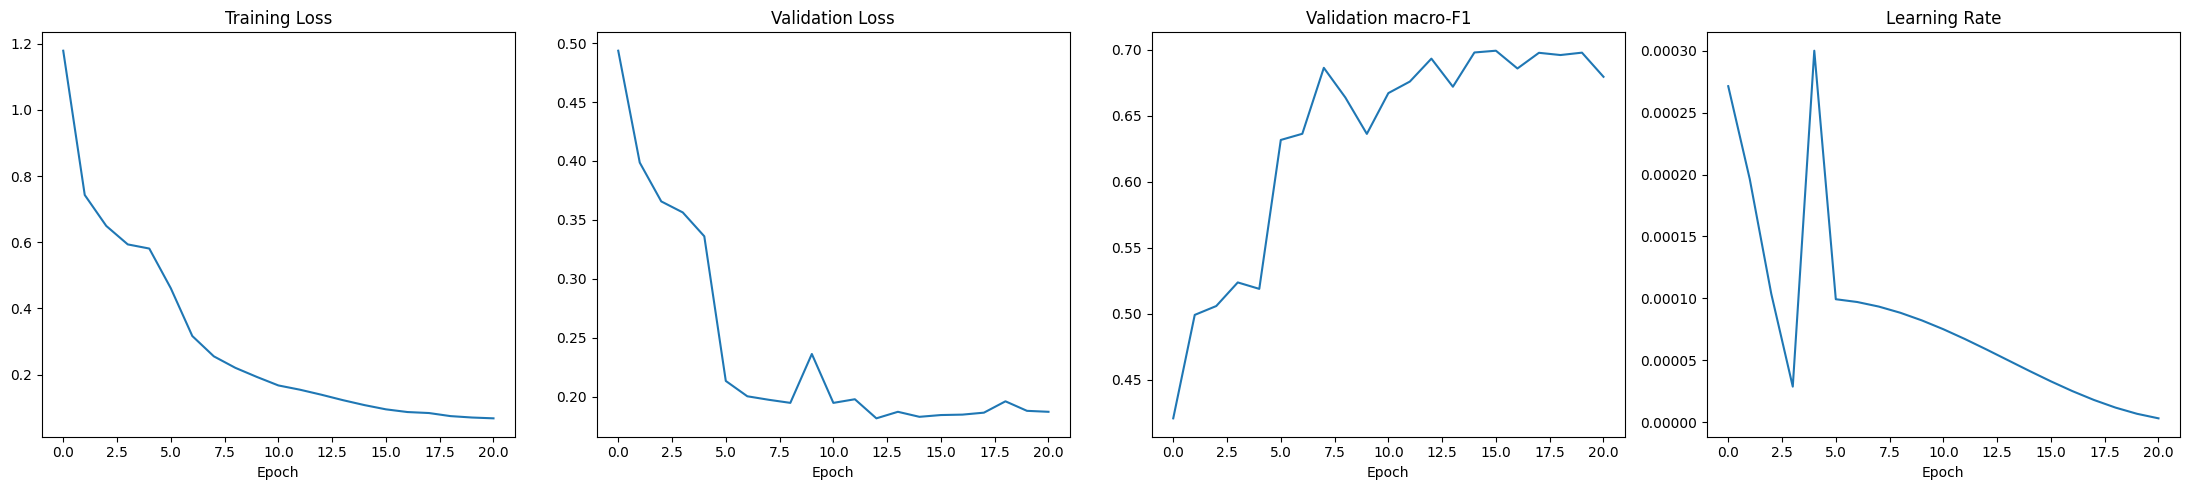

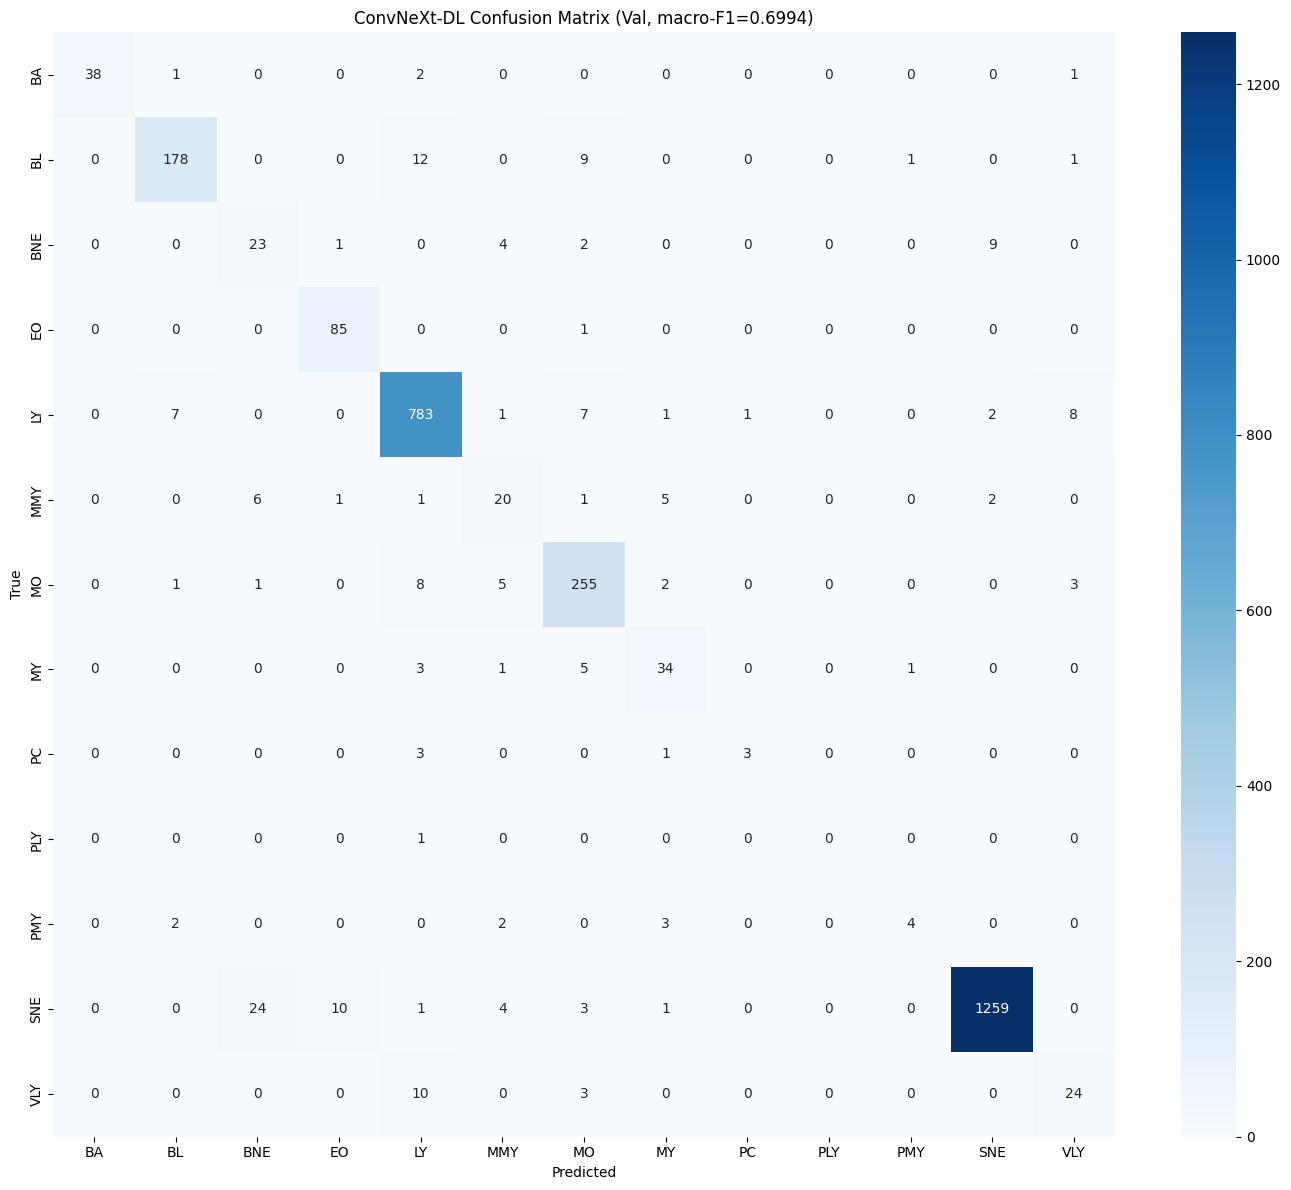

Per-class F1 scores (ConvNeXt-DL):
  BA   (n=   42): F1 = 0.9500
  BL   (n=  201): F1 = 0.9128
  BNE  (n=   39): F1 = 0.4946
  EO   (n=   86): F1 = 0.9290
  LY   (n=  810): F1 = 0.9584
  MMY  (n=   36): F1 = 0.5479
  MO   (n=  275): F1 = 0.9091
  MY   (n=   44): F1 = 0.7473
  PC   (n=    7): F1 = 0.5455
  PLY  (n=    1): F1 = 0.0000
  PMY  (n=   11): F1 = 0.4706
  SNE  (n= 1302): F1 = 0.9782
  VLY  (n=   37): F1 = 0.6486


In [ ]:
# ============================================================
# 7. HYBRID APPROACH: Backbone Features → Random Forest
# ============================================================

print(f"Val backbone features shape: {val_features.shape}")

# ---- Extract train backbone features ----
train_features_list = []
model.eval()
with torch.no_grad():
    for imgs, _ in DataLoader(train_ds, batch_size=BATCH_SIZE,
                               shuffle=False, num_workers=4, pin_memory=True):
        imgs = imgs.to(device)
        with torch.amp.autocast('cuda'):
            feats = model.extract_features(imgs)
        train_features_list.append(feats.float().cpu().numpy())
train_features = np.concatenate(train_features_list)
train_labels_enc = dl_le.transform(train_fold_df['label'])
print(f"Train backbone features shape: {train_features.shape}")

# ---- Random Forest on backbone features ----
rf = RandomForestClassifier(n_estimators=500, max_depth=None, min_samples_leaf=2,
                             class_weight='balanced', n_jobs=-1, random_state=SEED)
rf.fit(train_features, train_labels_enc)
rf_val_preds = rf.predict(val_features)
rf_val_f1 = f1_score(val_labels, rf_val_preds, average='macro')
print(f"\nHybrid Features+RF val macro-F1:  {rf_val_f1:.4f}")
print(f"DL ConvNeXt val macro-F1:          {val_f1:.4f}")

# ---- Choose best ----
best_approach = max(
    [('ConvNeXt-DL', val_f1, val_preds),
     ('Features+RF', rf_val_f1, rf_val_preds)],
    key=lambda x: x[1]
)
print(f"\n★ Best approach: {best_approach[0]} (macro-F1={best_approach[1]:.4f})")
USE_HYBRID = best_approach[0]
final_val_f1 = best_approach[1]

# ---- Training curves ----
fig, axes = plt.subplots(1, 4, figsize=(22, 5))
for data, ax, title in zip(
    [history['train_loss'], history['val_loss'], history['val_f1'], history['lr']],
    axes, ['Training Loss', 'Validation Loss', 'Validation macro-F1', 'Learning Rate']):
    ax.plot(data)
    ax.set_title(title)
    ax.set_xlabel('Epoch')
plt.tight_layout()
plt.show()

# ---- Confusion Matrix ----
cm = confusion_matrix(val_labels, best_approach[2])
fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=dl_le.classes_, yticklabels=dl_le.classes_, ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_title(f'{best_approach[0]} Confusion Matrix (Val, macro-F1={final_val_f1:.4f})')
plt.tight_layout()
plt.show()

# Per-class F1
print(f"Per-class F1 scores ({best_approach[0]}):")
f1_per_class = f1_score(val_labels, best_approach[2], average=None)
for cls_name, f1_val in zip(dl_le.classes_, f1_per_class):
    count = np.sum(val_labels == dl_le.transform([cls_name])[0])
    print(f"  {cls_name:4s} (n={count:5d}): F1 = {f1_val:.4f}")

  DETAILED RESULTS — ConvNeXt-DL (Val set)
  Overall accuracy: 0.9360  |  Macro-F1: 0.6994
  Class     Prec  Recall      F1     Acc  Support  Status
  -----------------------------------------------------------------
  BA       1.000   0.905   0.950   0.905       42  ✓ Good
  BL       0.942   0.886   0.913   0.886      201  ✓ Good
  BNE      0.426   0.590   0.495   0.590       39  ⚠ CRITICAL
  EO       0.876   0.988   0.929   0.988       86  ✓ Good
  LY       0.950   0.967   0.958   0.967      810  ✓ Good
  MMY      0.541   0.556   0.548   0.556       36  ⚠ Weak
  MO       0.892   0.927   0.909   0.927      275  ✓ Good
  MY       0.723   0.773   0.747   0.773       44  
  PC       0.750   0.429   0.545   0.429        7  ⚠ Weak
  PLY      0.000   0.000   0.000   0.000        1  ⚠ CRITICAL
  PMY      0.667   0.364   0.471   0.364       11  ⚠ CRITICAL
  SNE      0.990   0.967   0.978   0.967     1302  ✓ Good
  VLY      0.649   0.649   0.649   0.649       37  ⚠ Weak

  Ranked worst → best:

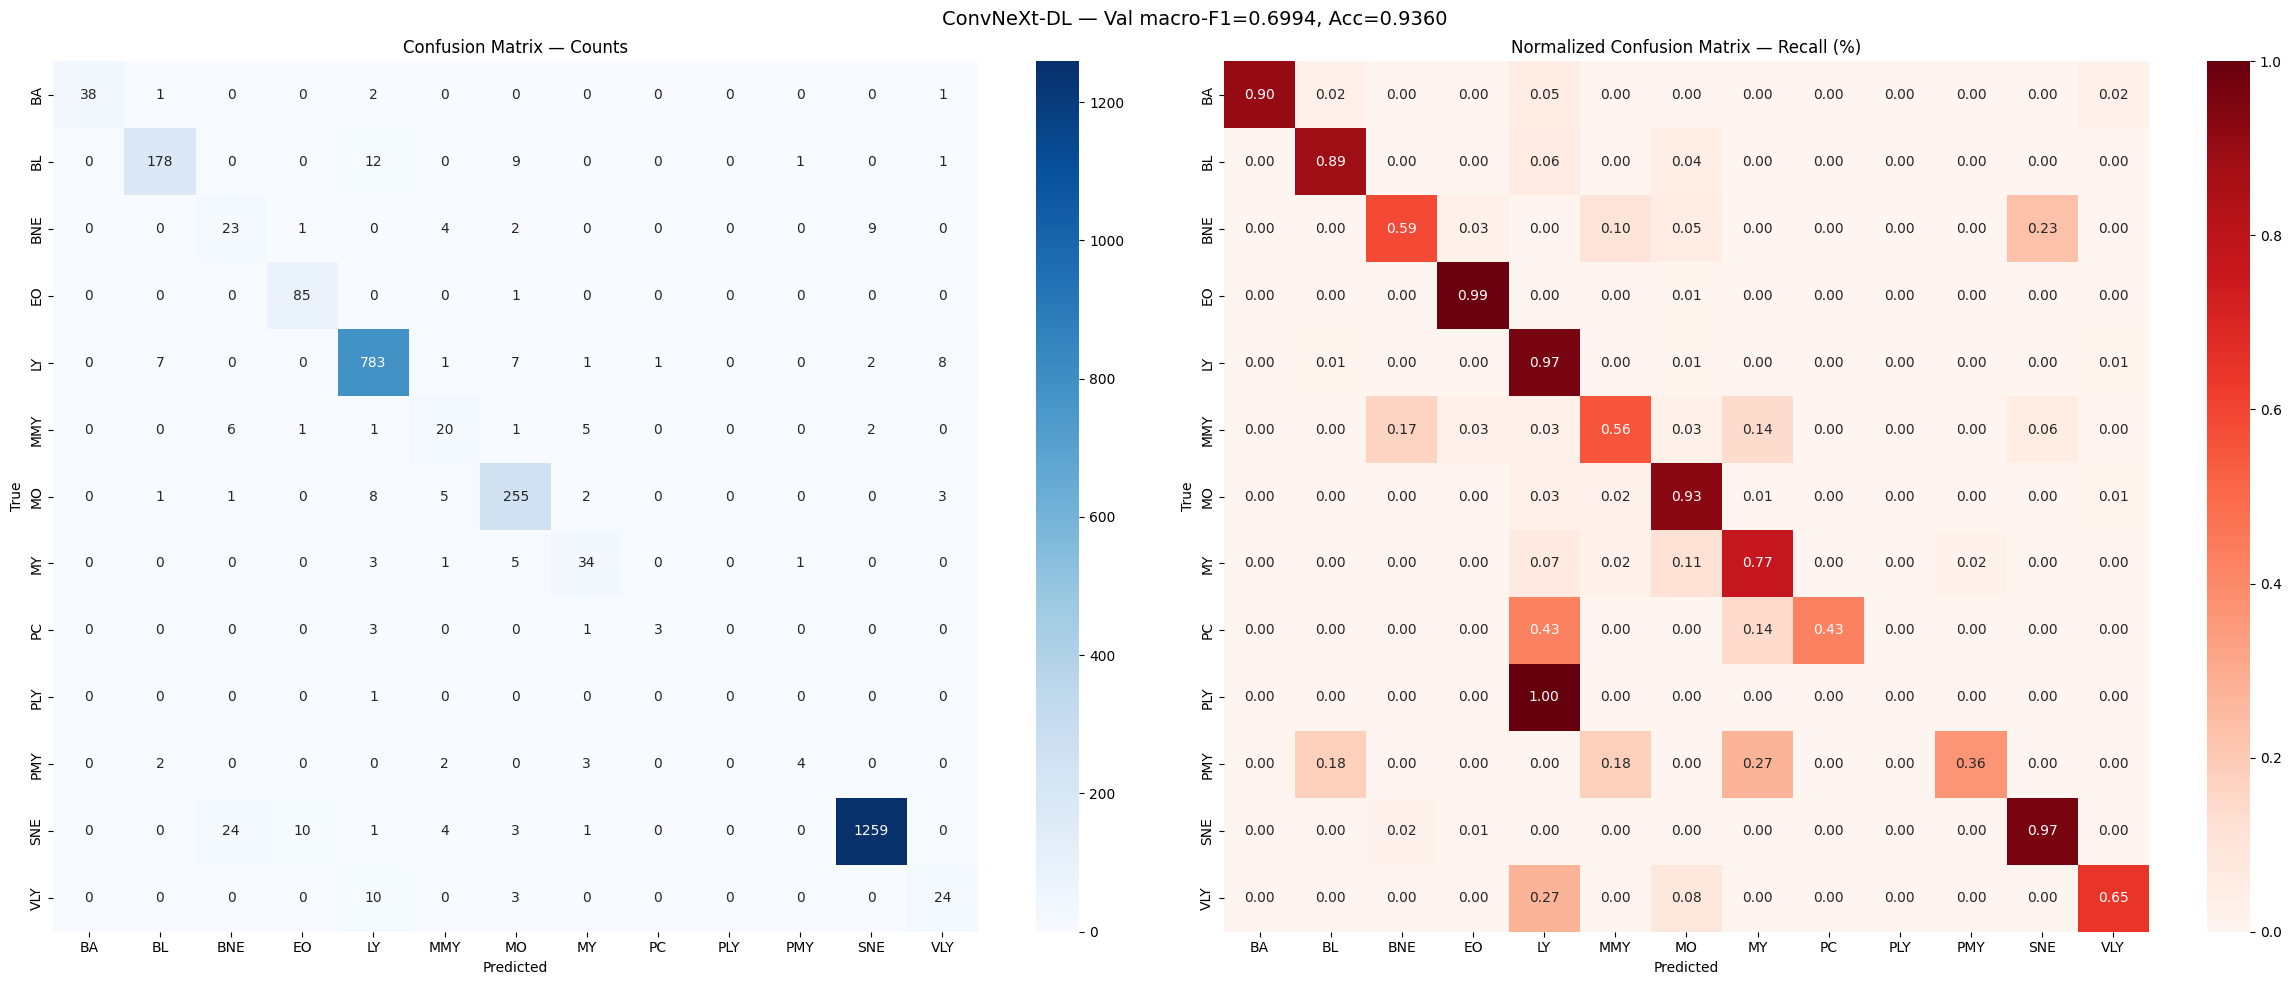


  TOP CONFUSED CLASS PAIRS (off-diagonal errors)
   1. SNE → BNE: 24 errors (1.8% of true SNE)
   2. BL → LY: 12 errors (6.0% of true BL)
   3. VLY → LY: 10 errors (27.0% of true VLY)
   4. SNE → EO: 10 errors (0.8% of true SNE)
   5. BNE → SNE: 9 errors (23.1% of true BNE)
   6. BL → MO: 9 errors (4.5% of true BL)
   7. MO → LY: 8 errors (2.9% of true MO)
   8. LY → VLY: 8 errors (1.0% of true LY)
   9. LY → MO: 7 errors (0.9% of true LY)
  10. LY → BL: 7 errors (0.9% of true LY)


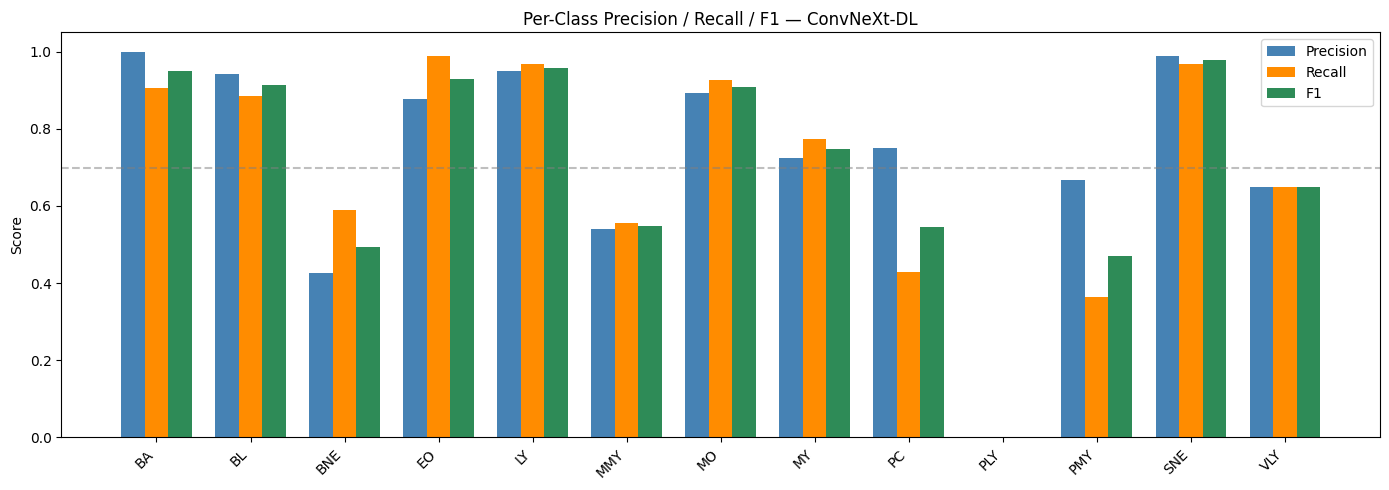


  CONFIDENCE ANALYSIS
  Mean confidence (all):     0.925
  Mean confidence (correct): 0.941
  Mean confidence (wrong):   0.704


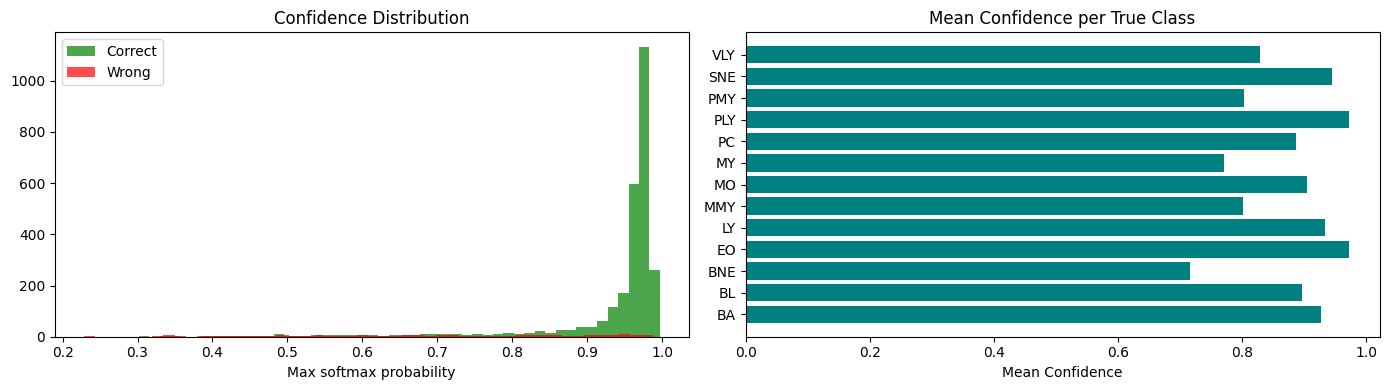


  Predictions with confidence < 0.5: 59 / 2891 (2.0%)
  Low-confidence samples come from:
    MO: 14
    SNE: 12
    LY: 7
    MY: 6
    BNE: 6
    MMY: 4
    VLY: 3
    PMY: 2
    BL: 2
    BA: 2
    EO: 1

  MISCLASSIFIED EXAMPLES (worst errors)


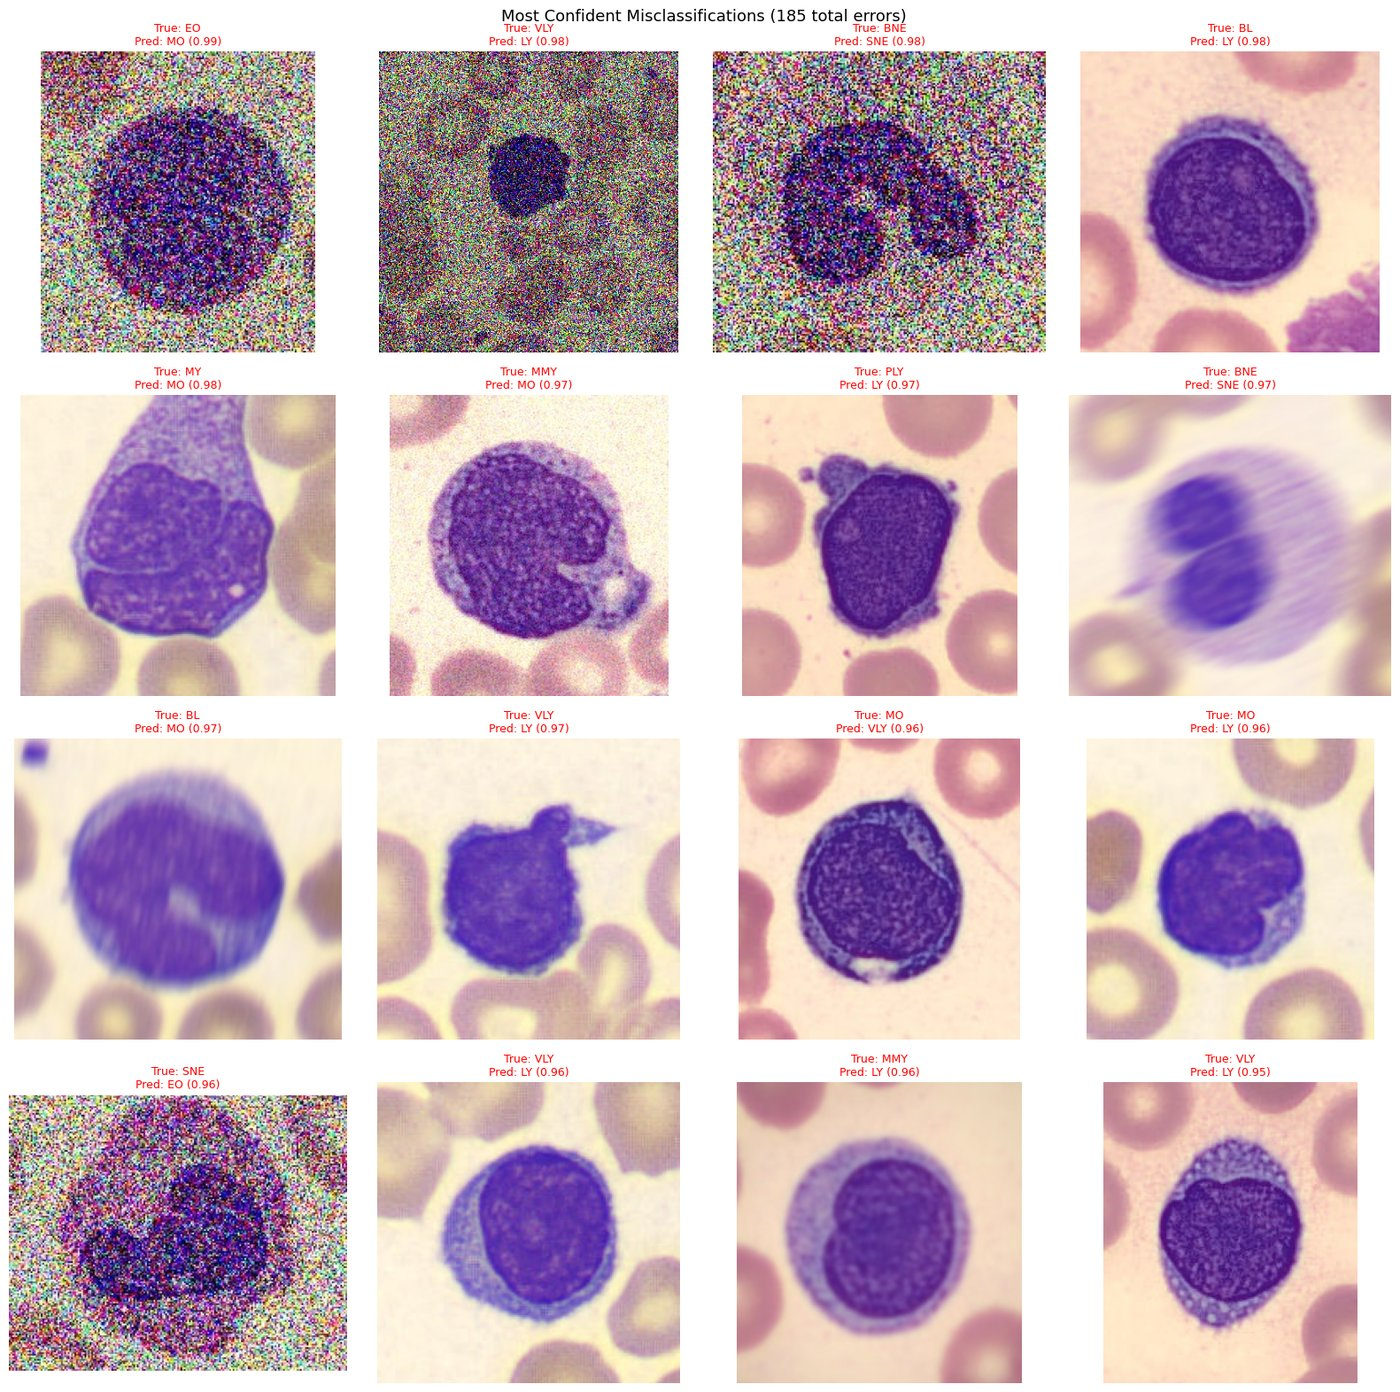


✓ Detailed analysis complete.


In [ ]:
# ============================================================
# 7b. DETAILED RESULTS ANALYSIS
# ============================================================
# Per-class accuracy, precision, recall, F1, support
# Normalized confusion matrix (recall-based)
# Top confused class pairs
# Misclassified examples visualization
# Confidence distribution analysis
# ============================================================

best_preds = best_approach[2]
best_name = best_approach[0]

# ---- 1. Per-class metrics table ----
from sklearn.metrics import precision_recall_fscore_support, accuracy_score

prec, rec, f1_arr, supp = precision_recall_fscore_support(
    val_labels, best_preds, average=None, zero_division=0)

overall_acc = accuracy_score(val_labels, best_preds)
overall_f1 = f1_score(val_labels, best_preds, average='macro')

print(f"{'='*75}")
print(f"  DETAILED RESULTS — {best_name} (Val set)")
print(f"{'='*75}")
print(f"  Overall accuracy: {overall_acc:.4f}  |  Macro-F1: {overall_f1:.4f}")
print(f"{'='*75}")
print(f"  {'Class':<6s}  {'Prec':>6s}  {'Recall':>6s}  {'F1':>6s}  {'Acc':>6s}  {'Support':>7s}  {'Status'}")
print(f"  {'-'*65}")

for i, cls in enumerate(dl_le.classes_):
    cls_mask = val_labels == i
    cls_acc = (best_preds[cls_mask] == i).sum() / max(cls_mask.sum(), 1)
    status = ""
    if f1_arr[i] < 0.5:
        status = "⚠ CRITICAL"
    elif f1_arr[i] < 0.7:
        status = "⚠ Weak"
    elif f1_arr[i] >= 0.9:
        status = "✓ Good"
    print(f"  {cls:<6s}  {prec[i]:>6.3f}  {rec[i]:>6.3f}  {f1_arr[i]:>6.3f}  "
          f"{cls_acc:>6.3f}  {supp[i]:>7d}  {status}")

# Sort by F1 to show worst classes
worst_idx = np.argsort(f1_arr)
print(f"\n  Ranked worst → best:")
for rank, i in enumerate(worst_idx, 1):
    print(f"    {rank:2d}. {dl_le.classes_[i]:<6s} F1={f1_arr[i]:.3f} "
          f"(prec={prec[i]:.3f}, rec={rec[i]:.3f}, n={supp[i]})")

# ---- 2. Normalized Confusion Matrix (recall-based) ----
cm_raw = confusion_matrix(val_labels, best_preds)
cm_norm = cm_raw.astype(float) / cm_raw.sum(axis=1, keepdims=True).clip(min=1)

fig, axes = plt.subplots(1, 2, figsize=(24, 10))

# Raw counts
sns.heatmap(cm_raw, annot=True, fmt='d', cmap='Blues',
            xticklabels=dl_le.classes_, yticklabels=dl_le.classes_, ax=axes[0])
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('True')
axes[0].set_title(f'Confusion Matrix — Counts')

# Normalized (recall per row)
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Reds',
            xticklabels=dl_le.classes_, yticklabels=dl_le.classes_, ax=axes[1])
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('True')
axes[1].set_title(f'Normalized Confusion Matrix — Recall (%)')

plt.suptitle(f'{best_name} — Val macro-F1={overall_f1:.4f}, Acc={overall_acc:.4f}', fontsize=14)
plt.tight_layout()
plt.show()

# ---- 3. Top confused class pairs ----
print(f"\n{'='*60}")
print("  TOP CONFUSED CLASS PAIRS (off-diagonal errors)")
print(f"{'='*60}")
n_errors_shown = 10
errors = []
for true_i in range(num_classes):
    for pred_j in range(num_classes):
        if true_i != pred_j and cm_raw[true_i, pred_j] > 0:
            errors.append((cm_raw[true_i, pred_j],
                          dl_le.classes_[true_i], dl_le.classes_[pred_j],
                          cm_norm[true_i, pred_j]))
errors.sort(reverse=True)
for rank, (cnt, true_cls, pred_cls, rate) in enumerate(errors[:n_errors_shown], 1):
    print(f"  {rank:2d}. {true_cls} → {pred_cls}: {cnt} errors ({rate:.1%} of true {true_cls})")

# ---- 4. Per-class bar chart ----
fig, ax = plt.subplots(figsize=(14, 5))
x = np.arange(num_classes)
width = 0.25
bars_p = ax.bar(x - width, prec, width, label='Precision', color='steelblue')
bars_r = ax.bar(x, rec, width, label='Recall', color='darkorange')
bars_f = ax.bar(x + width, f1_arr, width, label='F1', color='seagreen')
ax.set_xticks(x)
ax.set_xticklabels(dl_le.classes_, rotation=45, ha='right')
ax.set_ylabel('Score')
ax.set_title(f'Per-Class Precision / Recall / F1 — {best_name}')
ax.legend()
ax.axhline(y=overall_f1, color='gray', linestyle='--', alpha=0.5, label=f'Macro-F1={overall_f1:.3f}')
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.show()

# ---- 5. Confidence analysis ----
if val_probs is not None:
    print(f"\n{'='*60}")
    print("  CONFIDENCE ANALYSIS")
    print(f"{'='*60}")

    val_confs = val_probs.max(axis=1)
    val_pred_classes = val_probs.argmax(axis=1)
    correct_mask = val_pred_classes == val_labels

    print(f"  Mean confidence (all):     {val_confs.mean():.3f}")
    print(f"  Mean confidence (correct): {val_confs[correct_mask].mean():.3f}")
    print(f"  Mean confidence (wrong):   {val_confs[~correct_mask].mean():.3f}")

    # Confidence histogram for correct vs wrong
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    axes[0].hist(val_confs[correct_mask], bins=50, alpha=0.7, color='green', label='Correct')
    axes[0].hist(val_confs[~correct_mask], bins=50, alpha=0.7, color='red', label='Wrong')
    axes[0].set_title('Confidence Distribution')
    axes[0].set_xlabel('Max softmax probability')
    axes[0].legend()

    # Per-class mean confidence
    cls_conf = []
    for i in range(num_classes):
        mask = val_labels == i
        cls_conf.append(val_confs[mask].mean() if mask.sum() > 0 else 0)
    axes[1].barh(dl_le.classes_, cls_conf, color='teal')
    axes[1].set_xlabel('Mean Confidence')
    axes[1].set_title('Mean Confidence per True Class')
    plt.tight_layout()
    plt.show()

    # Low confidence predictions (potential errors)
    LOW_CONF_THR = 0.5
    low_conf_mask = val_confs < LOW_CONF_THR
    print(f"\n  Predictions with confidence < {LOW_CONF_THR}: "
          f"{low_conf_mask.sum()} / {len(val_confs)} ({100*low_conf_mask.mean():.1f}%)")
    if low_conf_mask.sum() > 0:
        low_conf_classes = val_labels[low_conf_mask]
        low_conf_dist = pd.Series(dl_le.inverse_transform(low_conf_classes)).value_counts()
        print("  Low-confidence samples come from:")
        for cls, cnt in low_conf_dist.items():
            print(f"    {cls}: {cnt}")

# ---- 6. Show misclassified examples ----
print(f"\n{'='*60}")
print("  MISCLASSIFIED EXAMPLES (worst errors)")
print(f"{'='*60}")

wrong_mask = best_preds != val_labels
wrong_indices = np.where(wrong_mask)[0]

if len(wrong_indices) > 0:
    # Sort by confidence (show most confident wrong predictions first)
    if val_probs is not None:
        wrong_confs = val_probs[wrong_indices].max(axis=1)
        sorted_wrong = wrong_indices[np.argsort(-wrong_confs)]  # highest confidence first
    else:
        sorted_wrong = wrong_indices

    n_show = min(16, len(sorted_wrong))
    ncols = 4
    nrows = (n_show + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 4 * nrows))
    fig.suptitle(f"Most Confident Misclassifications ({len(wrong_indices)} total errors)", fontsize=13)
    axes_flat = axes.flatten() if n_show > ncols else [axes] if n_show == 1 else axes

    for k in range(n_show):
        ax = axes_flat[k] if hasattr(axes_flat, '__len__') else axes_flat
        idx = sorted_wrong[k]
        val_row = val_fold_df.iloc[idx]
        img_path = TRAIN_IMG_DIR / val_row['ID']
        try:
            img = np.array(Image.open(img_path).convert('RGB'))
        except Exception:
            img = np.zeros((100, 100, 3), dtype=np.uint8)

        true_cls = dl_le.inverse_transform([val_labels[idx]])[0]
        pred_cls = dl_le.inverse_transform([best_preds[idx]])[0]
        conf = val_probs[idx].max() if val_probs is not None else 0

        ax = axes_flat[k]
        ax.imshow(img)
        ax.set_title(f"True: {true_cls}\nPred: {pred_cls} ({conf:.2f})",
                     fontsize=9, color='red')
        ax.axis('off')

    # Hide unused axes
    for k in range(n_show, len(axes_flat)):
        axes_flat[k].axis('off')

    plt.tight_layout()
    plt.show()
else:
    print("  No misclassifications!")

print(f"\n✓ Detailed analysis complete.")

In [ ]:
# ============================================================
# 9. GENERATE SUBMISSION CSV
# ============================================================

print(f"Best approach: {USE_HYBRID}")
print(f"Val macro-F1:  {final_val_f1:.4f}")

final_submission = pd.DataFrame({
    'ID': test_df['ID'],
    'label': dl_test_labels
})

print(f"\nSubmission shape: {final_submission.shape}")
print(f"Sample sub shape: {sample_sub.shape}")
print(f"\nFirst rows:")
print(final_submission.head(10))

print("\nPrediction distribution:")
pred_counts = final_submission['label'].value_counts()
for cls, count in pred_counts.items():
    print(f"  {cls:4s}: {count:5d}")

output_path = BASE_DIR / "submission.csv"
final_submission.to_csv(output_path, index=False)
print(f"\nSubmission saved: {output_path}")
print(f"  {len(final_submission)} rows, columns: {list(final_submission.columns)}")

Best approach: ConvNeXt-DL
Val macro-F1:  0.6994

Submission shape: (9634, 2)
Sample sub shape: (9634, 3)

First rows:
               ID label
0  test_00000.png    LY
1  test_00001.png    BL
2  test_00002.png   SNE
3  test_00003.png   SNE
4  test_00004.png    LY
5  test_00005.png    MO
6  test_00006.png   SNE
7  test_00007.png    LY
8  test_00008.png    EO
9  test_00009.png    BA

Prediction distribution:
  SNE :  4231
  LY  :  2716
  MO  :   929
  BL  :   643
  EO  :   325
  BNE :   175
  MY  :   146
  MMY :   144
  BA  :   138
  VLY :   138
  PMY :    33
  PC  :    14
  PLY :     2

Submission saved: submission.csv
  9634 rows, columns: ['ID', 'label']


## deep_7 — ResNet50 + Spatial Attention + Late Fusion

Back to a Late Fusion architecture (image + tabular), this time with an ImageNet-pretrained
**ResNet50** backbone, a **spatial attention gate** (not the full CBAM), and a tabular branch
reduced to **4 morphology features**.

Result: val macro-F1 = **0.6507**. Setting the 4 morphology inputs to zero at inference (no retraining) lowers it by
0.0173: the network relies only slightly on its morphology branch (this measures reliance,
not the gain the features would bring to a model trained without them). This lighter backbone stays well below
ConvNeXt (deep_6 = 0.6994).

In [ ]:
# deep_7 — key change: ResNet50 backbone + spatial attention gate (spatial only, no channel branch) + 4-feature Late Fusion
class SpatialAttentionGate(nn.Module):
    """Simple spatial attention (no channel branch, unlike CBAM)."""
    def __init__(self, kernel_size=7):
        super().__init__()
        self.conv = nn.Conv2d(2, 1, kernel_size=kernel_size, padding=kernel_size // 2, bias=False)
        self.act = nn.Sigmoid()

    def forward(self, x):
        avg_map = torch.mean(x, dim=1, keepdim=True)
        max_map, _ = torch.max(x, dim=1, keepdim=True)
        return self.act(self.conv(torch.cat([avg_map, max_map], dim=1)))


class WBCClassifier(nn.Module):
    """ResNet50 (new backbone, lighter than ConvNeXt) + spatial attention + Late Fusion."""
    def __init__(self, num_classes=13, dropout=0.3, pretrained=True, tab_dim=TAB_FEATURE_DIM):
        super().__init__()
        weights = ResNet50_Weights.IMAGENET1K_V2 if pretrained else None
        base = resnet50(weights=weights)
        self.feature_extractor = nn.Sequential(*list(base.children())[:-2])  # Bx2048x7x7
        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        self.nucleus_attention = SpatialAttentionGate(kernel_size=7)
        self.img_proj = nn.Sequential(nn.Linear(2048, 512), nn.ReLU(), nn.Dropout(dropout),
                                       nn.Linear(512, 256), nn.ReLU())
        self.tab_mlp = nn.Sequential(nn.Linear(tab_dim, 64), nn.ReLU(), nn.BatchNorm1d(64),
                                      nn.Dropout(dropout * 0.5), nn.Linear(64, 64), nn.ReLU())
        self.classifier = nn.Sequential(nn.Linear(256 + 64, 256), nn.ReLU(), nn.Dropout(dropout),
                                         nn.Linear(256, num_classes))

    def extract_features(self, x):
        feat_map = self.feature_extractor(x)
        feat_map = feat_map * self.nucleus_attention(feat_map)
        return self.pool(feat_map).flatten(1)

    def forward(self, x, tab_feats):
        img_embed = self.img_proj(self.extract_features(x))
        tab_embed = self.tab_mlp(tab_feats)
        return self.classifier(torch.cat([img_embed, tab_embed], dim=1))

Val backbone features shape: (2891, 2048)
Train backbone features shape: (27081, 2048)

Hybrid Features+RF val macro-F1:  0.5933
DL Late-Fusion val macro-F1:       0.6507

* Best approach: LateFusion-DL (macro-F1=0.6507)


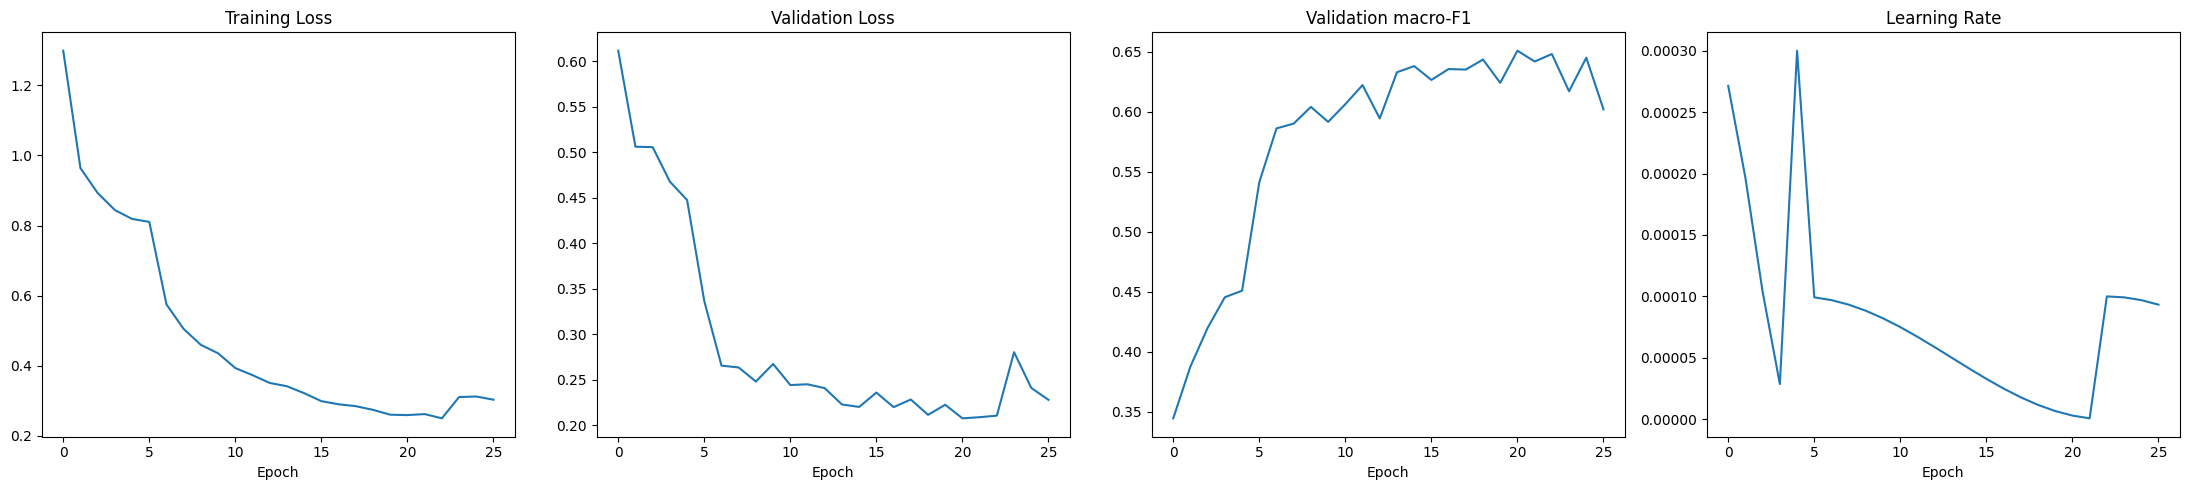

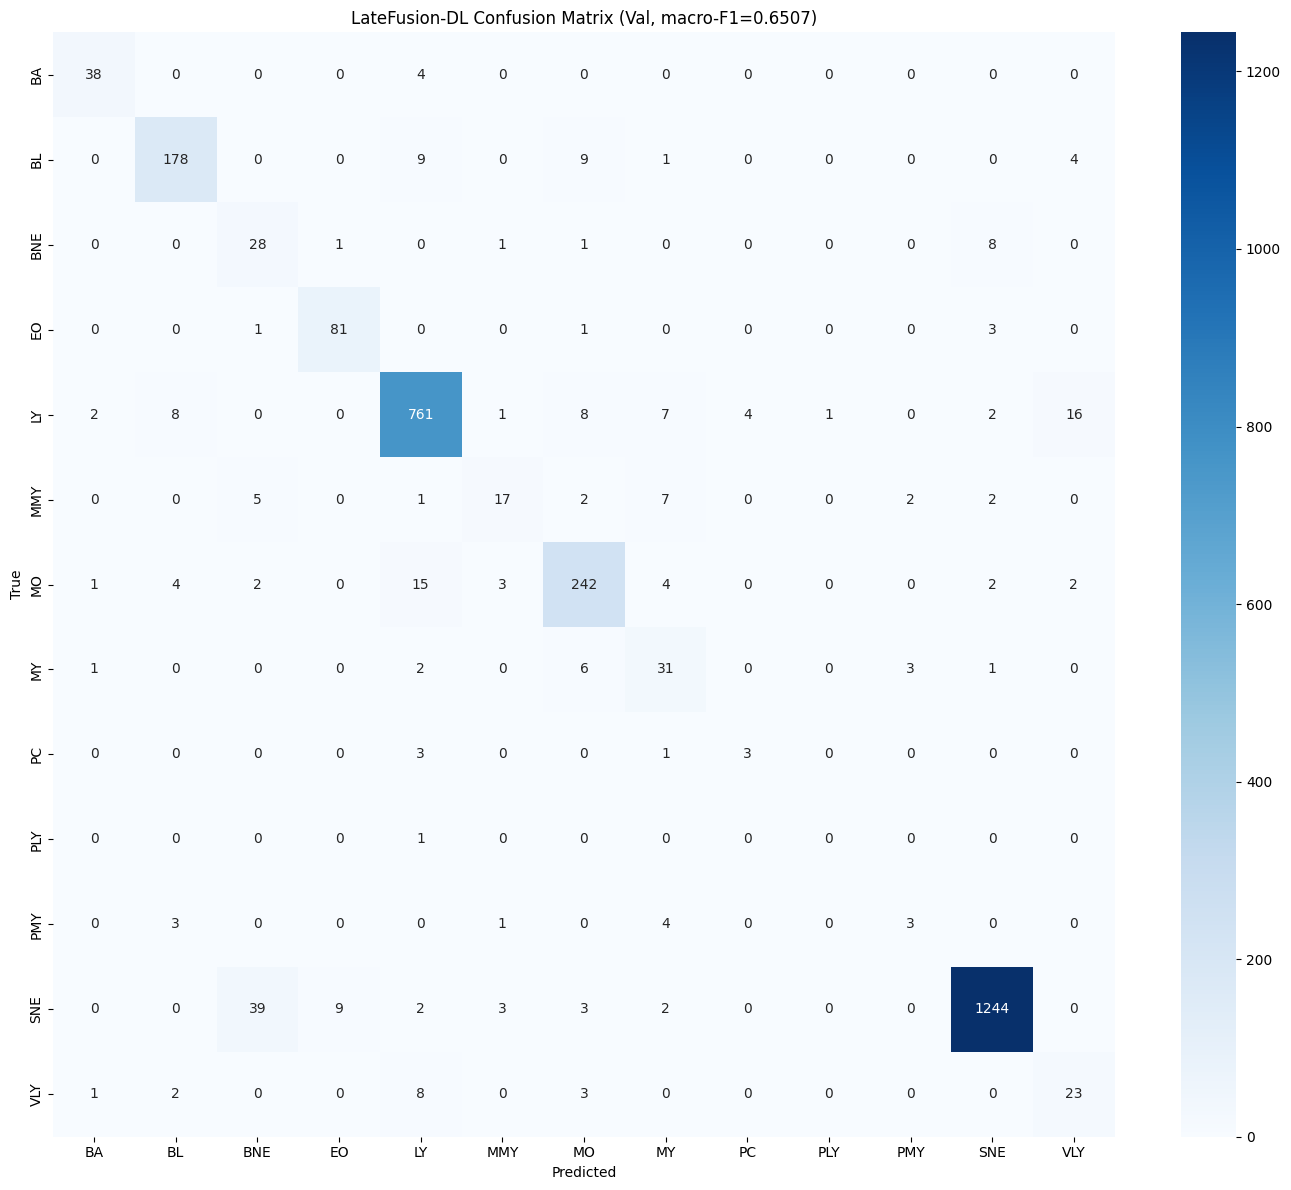

Per-class F1 scores (LateFusion-DL):
  BA   (n=   42): F1 = 0.8941
  BL   (n=  201): F1 = 0.8990
  BNE  (n=   39): F1 = 0.4912
  EO   (n=   86): F1 = 0.9153
  LY   (n=  810): F1 = 0.9418
  MMY  (n=   36): F1 = 0.5484
  MO   (n=  275): F1 = 0.8800
  MY   (n=   44): F1 = 0.6139
  PC   (n=    7): F1 = 0.4286
  PLY  (n=    1): F1 = 0.0000
  PMY  (n=   11): F1 = 0.3158
  SNE  (n= 1302): F1 = 0.9704
  VLY  (n=   37): F1 = 0.5610


In [ ]:
# ============================================================
# 7. HYBRID APPROACH: Backbone Features -> Random Forest
# ============================================================

print(f"Val backbone features shape: {val_features.shape}")

train_features_list = []
model.eval()
with torch.no_grad():
    for imgs, _, _ in DataLoader(train_ds, batch_size=BATCH_SIZE,
                                  shuffle=False, num_workers=4, pin_memory=True):
        imgs = imgs.to(device)
        with torch.amp.autocast('cuda', enabled=(device.type == 'cuda')):
            feats = model.extract_features(imgs)
        train_features_list.append(feats.float().cpu().numpy())
train_features = np.concatenate(train_features_list)
train_labels_enc = dl_le.transform(train_fold_df['label'])
print(f"Train backbone features shape: {train_features.shape}")

rf = RandomForestClassifier(n_estimators=500, max_depth=None, min_samples_leaf=2,
                             class_weight='balanced', n_jobs=-1, random_state=SEED)
rf.fit(train_features, train_labels_enc)
rf_val_preds = rf.predict(val_features)
rf_val_f1 = f1_score(val_labels, rf_val_preds, average='macro')
print(f"\nHybrid Features+RF val macro-F1:  {rf_val_f1:.4f}")
print(f"DL Late-Fusion val macro-F1:       {val_f1:.4f}")

best_approach = max(
    [('LateFusion-DL', val_f1, val_preds),
     ('Features+RF', rf_val_f1, rf_val_preds)],
    key=lambda x: x[1]
)
print(f"\n* Best approach: {best_approach[0]} (macro-F1={best_approach[1]:.4f})")
USE_HYBRID = best_approach[0]
final_val_f1 = best_approach[1]

fig, axes = plt.subplots(1, 4, figsize=(22, 5))
for data, ax, title in zip(
    [history['train_loss'], history['val_loss'], history['val_f1'], history['lr']],
    axes, ['Training Loss', 'Validation Loss', 'Validation macro-F1', 'Learning Rate']):
    ax.plot(data)
    ax.set_title(title)
    ax.set_xlabel('Epoch')
plt.tight_layout()
plt.show()

cm = confusion_matrix(val_labels, best_approach[2])
fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=dl_le.classes_, yticklabels=dl_le.classes_, ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_title(f'{best_approach[0]} Confusion Matrix (Val, macro-F1={final_val_f1:.4f})')
plt.tight_layout()
plt.show()

print(f"Per-class F1 scores ({best_approach[0]}):")
f1_per_class = f1_score(val_labels, best_approach[2], average=None)
for cls_name, f1_val in zip(dl_le.classes_, f1_per_class):
    count = np.sum(val_labels == dl_le.transform([cls_name])[0])
    print(f"  {cls_name:4s} (n={count:5d}): F1 = {f1_val:.4f}")

Ablation study (inference only, no retraining)
  Model                           Val macro-F1     Delta
  -------------------------------------------------------
  DL image-only (tab=zeros)             0.6334     (ref)
  DL + 4 morpho features                0.6507   +0.0173
  Backbone features + RF                0.5933   -0.0401

  Per-class F1 gain from morpho features (DL+morpho − DL-only):
  Class      DL-only  DL+morpho    Delta
  --------------------------------------
  BA           0.902      0.894   -0.008  
  BL           0.885      0.899   +0.013  
  BNE          0.444      0.491   +0.047 +
  EO           0.915      0.915   +0.000  
  LY           0.940      0.942   +0.002  
  MMY          0.525      0.548   +0.024 +
  MO           0.878      0.880   +0.002  
  MY           0.627      0.614   -0.014  
  PC           0.462      0.429   -0.033 -
  PLY          0.000      0.000   +0.000  
  PMY          0.133      0.316   +0.182 +
  SNE          0.968      0.970   +0.002  
  VL

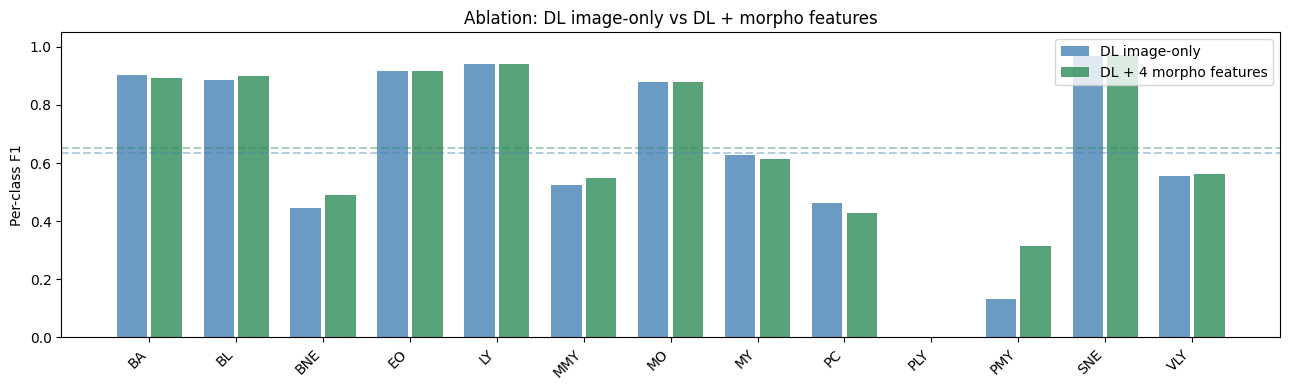


Morpho feature net contribution: macro-F1 +0.0173


In [ ]:

# ============================================================
# 7c. ABLATION — Contribution of morphological features
# ============================================================
# Inference-only, no retraining: we evaluate the already-trained
# model with tab=zeros to isolate the tabular branch contribution.
# Comparison: DL image-only | DL + morpho | Backbone + RF
# ============================================================

print("Ablation study (inference only, no retraining)")
print("=" * 55)

model.eval()
zeroed_preds = []
with torch.no_grad():
    for imgs, tab_feats, _ in DataLoader(val_ds, batch_size=BATCH_SIZE,
                                          shuffle=False, num_workers=4, pin_memory=True):
        imgs = imgs.to(device)
        zeros = torch.zeros_like(tab_feats).to(device)
        with torch.amp.autocast('cuda', enabled=(device.type == 'cuda')):
            outputs = model(imgs, zeros)
        zeroed_preds.extend(outputs.argmax(dim=1).cpu().numpy())

zeroed_preds = np.array(zeroed_preds)
zeroed_f1 = f1_score(val_labels, zeroed_preds, average='macro')

print(f"  {'Model':<30s}  {'Val macro-F1':>12s}  {'Delta':>8s}")
print(f"  {'-'*55}")
print(f"  {'DL image-only (tab=zeros)':<30s}  {zeroed_f1:>12.4f}  {'(ref)':>8s}")
print(f"  {'DL + 4 morpho features':<30s}  {val_f1:>12.4f}  {val_f1 - zeroed_f1:>+8.4f}")
print(f"  {'Backbone features + RF':<30s}  {rf_val_f1:>12.4f}  {rf_val_f1 - zeroed_f1:>+8.4f}")
print(f"  {'='*55}")

# Per-class impact of tabular features
f1_zeroed_per_class = f1_score(val_labels, zeroed_preds, average=None)
f1_full_per_class   = f1_score(val_labels, val_preds,    average=None)
delta_per_class     = f1_full_per_class - f1_zeroed_per_class

print(f"\n  Per-class F1 gain from morpho features (DL+morpho − DL-only):")
print(f"  {'Class':<8s}  {'DL-only':>8s}  {'DL+morpho':>9s}  {'Delta':>7s}")
print(f"  {'-'*38}")
for i, cls in enumerate(dl_le.classes_):
    mark = " +" if delta_per_class[i] > 0.02 else (" -" if delta_per_class[i] < -0.02 else "  ")
    print(f"  {cls:<8s}  {f1_zeroed_per_class[i]:>8.3f}  {f1_full_per_class[i]:>9.3f}  {delta_per_class[i]:>+7.3f}{mark}")

fig, ax = plt.subplots(figsize=(13, 4))
x = np.arange(num_classes)
ax.bar(x - 0.2, f1_zeroed_per_class, 0.35, label='DL image-only', color='steelblue', alpha=0.8)
ax.bar(x + 0.2, f1_full_per_class,   0.35, label='DL + 4 morpho features', color='seagreen', alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(dl_le.classes_, rotation=45, ha='right')
ax.set_ylabel('Per-class F1')
ax.set_title('Ablation: DL image-only vs DL + morpho features')
ax.legend()
ax.axhline(zeroed_f1, color='steelblue', linestyle='--', alpha=0.4, label=f'Macro (DL-only)={zeroed_f1:.3f}')
ax.axhline(val_f1,    color='seagreen',  linestyle='--', alpha=0.4, label=f'Macro (DL+morpho)={val_f1:.3f}')
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.show()

print(f"\nMorpho feature net contribution: macro-F1 {val_f1 - zeroed_f1:+.4f}")


## deep_8 — ResNeXt101 + CBAM + Multi-task learning

Stronger backbone: **ResNeXt101-32x8d** (~87M parameters) + **full CBAM** (channel + spatial),
tabular branch extended to **6 morphology features**, and **2 auxiliary heads** (morphology
regression + nucleus lobe-count classification) trained jointly (multi-task).

Result: val macro-F1 = **0.6654**, accuracy = 0.9256. Despite the added complexity (a backbone
about 3.5x larger than deep_7's, plus multi-task learning), the score still does not reach
deep_6 (0.6994).

In [ ]:
# deep_8 — key change: ResNeXt101-32x8d backbone + full CBAM + 6 morphology features + 2 auxiliary multi-task heads
class ChannelAttention(nn.Module):
    def __init__(self, channels, reduction=16):
        super().__init__()
        hidden = max(channels // reduction, 16)
        self.mlp = nn.Sequential(nn.Linear(channels, hidden, bias=False), nn.ReLU(inplace=True),
                                  nn.Linear(hidden, channels, bias=False))
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        b, c, _, _ = x.shape
        avg_pool = torch.mean(x, dim=(2, 3))
        max_pool = torch.amax(x, dim=(2, 3))
        attn = self.sigmoid(self.mlp(avg_pool) + self.mlp(max_pool)).view(b, c, 1, 1)
        return x * attn


class CBAM(nn.Module):
    """Full CBAM (channel + spatial) — back from the spatial-only attention of deep_7."""
    def __init__(self, channels, reduction=16, spatial_kernel=7):
        super().__init__()
        self.ca = ChannelAttention(channels, reduction=reduction)
        self.sa = SpatialAttention(kernel_size=spatial_kernel)  # see deep_2/deep_3

    def forward(self, x):
        return self.sa(self.ca(x))


class WBCClassifier(nn.Module):
    """ResNeXt101-32x8d (new, ~87M-parameter backbone, ~3.5x larger than deep_7) + CBAM
    + Late Fusion (6 features) + 2 auxiliary multi-task heads."""
    def __init__(self, num_classes=13, dropout=0.35, pretrained=True, tab_dim=TAB_FEATURE_DIM):
        super().__init__()
        weights = ResNeXt101_32X8D_Weights.IMAGENET1K_V1 if pretrained else None
        base = resnext101_32x8d(weights=weights)
        self.feature_extractor = nn.Sequential(*list(base.children())[:-2])
        self.cbam = CBAM(channels=2048, reduction=16, spatial_kernel=7)
        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        # ... img_proj + tab_mlp + classifier (Late Fusion, as in deep_7)
        # + auxiliary heads:
        # aux_reg_head  : regression of morphology features (auxiliary supervision)
        # aux_lobe_head : classification of the nucleus lobe count (5 classes)

Val backbone features shape: (2891, 2048)
Train backbone features shape: (27081, 2048)

Hybrid Features+RF val macro-F1:  0.6396
DL Late-Fusion val macro-F1:       0.6654

* Best approach: LateFusion-DL (macro-F1=0.6654)


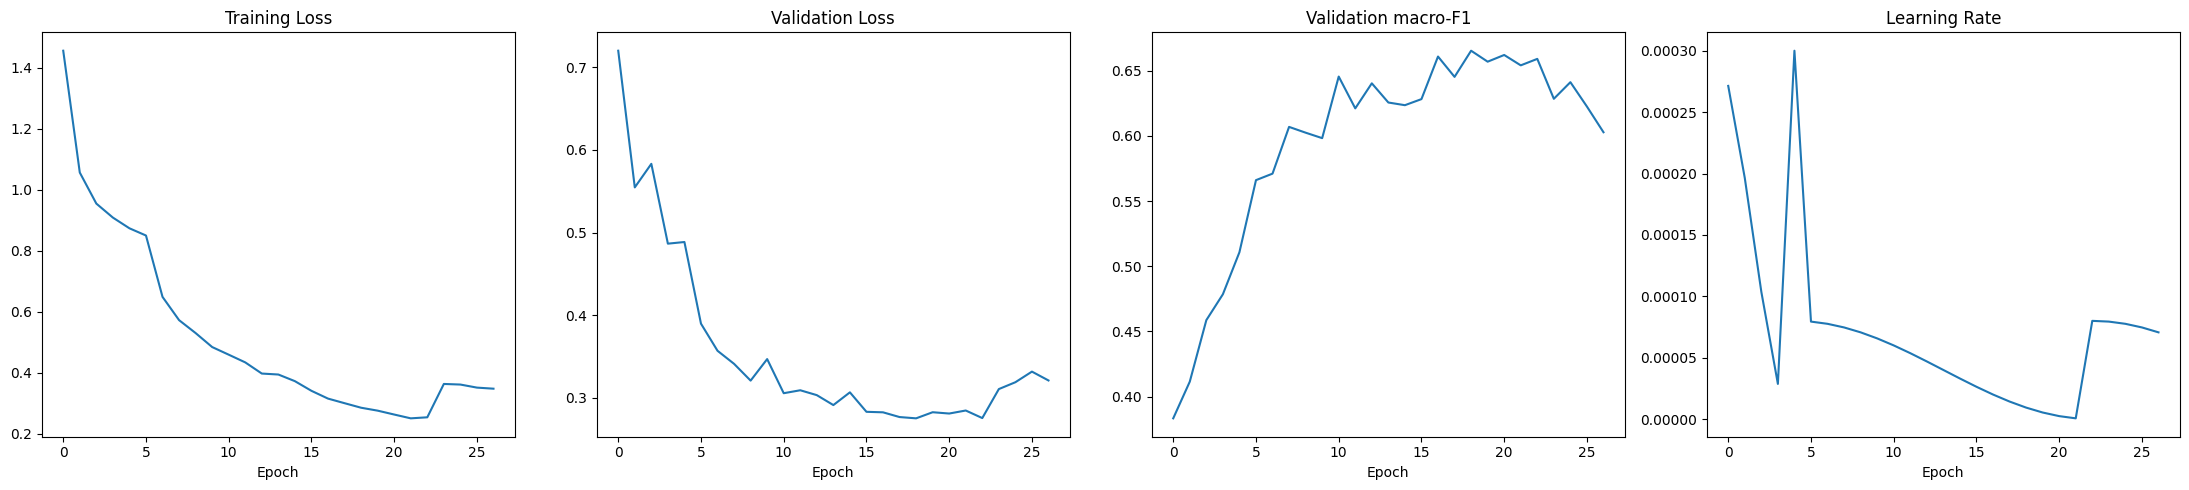

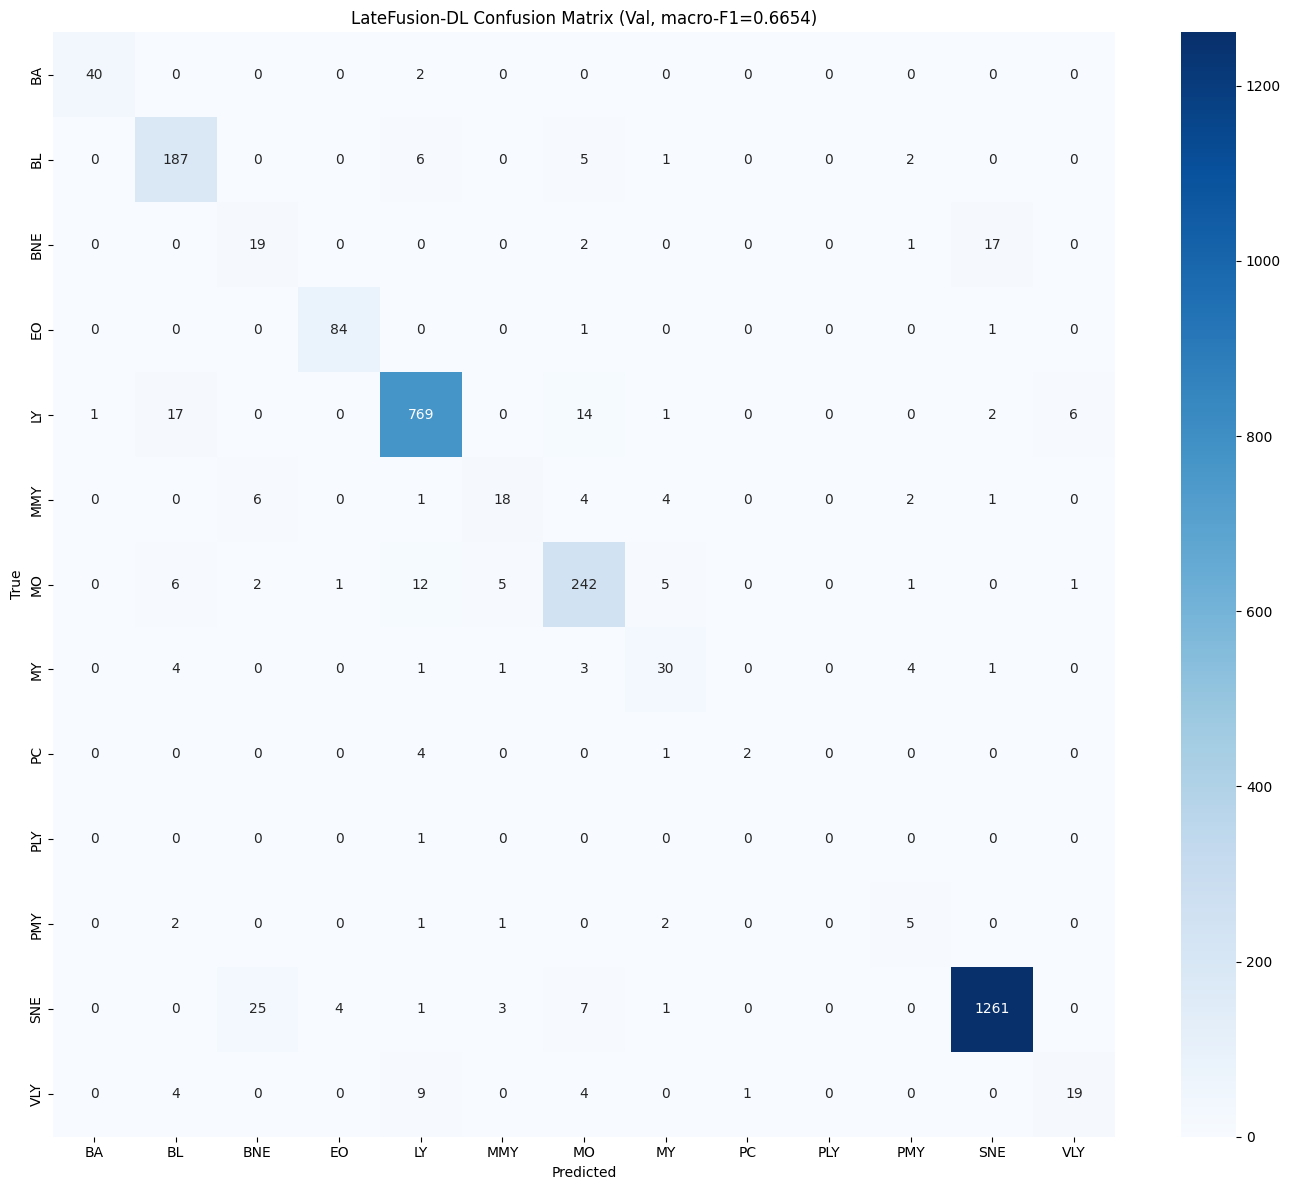

Per-class F1 scores (LateFusion-DL):
  BA   (n=   42): F1 = 0.9639
  BL   (n=  201): F1 = 0.8884
  BNE  (n=   39): F1 = 0.4176
  EO   (n=   86): F1 = 0.9600
  LY   (n=  810): F1 = 0.9511
  MMY  (n=   36): F1 = 0.5625
  MO   (n=  275): F1 = 0.8689
  MY   (n=   44): F1 = 0.6742
  PC   (n=    7): F1 = 0.4000
  PLY  (n=    1): F1 = 0.0000
  PMY  (n=   11): F1 = 0.3846
  SNE  (n= 1302): F1 = 0.9756
  VLY  (n=   37): F1 = 0.6032


In [ ]:
# ============================================================
# 7. HYBRID APPROACH: Backbone Features -> Random Forest
# ============================================================

print(f"Val backbone features shape: {val_features.shape}")

train_features_list = []
model.eval()
with torch.no_grad():
    for imgs, _, _, _, _ in DataLoader(train_ds, batch_size=BATCH_SIZE,
                                       shuffle=False, num_workers=4, pin_memory=True):
        imgs = imgs.to(device)
        with torch.amp.autocast('cuda', enabled=(device.type == 'cuda')):
            feats = model.extract_features(imgs)
        train_features_list.append(feats.float().cpu().numpy())
train_features = np.concatenate(train_features_list)
train_labels_enc = dl_le.transform(train_fold_df['label'])
print(f"Train backbone features shape: {train_features.shape}")

rf = RandomForestClassifier(n_estimators=600, max_depth=None, min_samples_leaf=2,
                             class_weight='balanced', n_jobs=-1, random_state=SEED)
rf.fit(train_features, train_labels_enc)
rf_val_preds = rf.predict(val_features)
rf_val_f1 = f1_score(val_labels, rf_val_preds, average='macro')
print(f"\nHybrid Features+RF val macro-F1:  {rf_val_f1:.4f}")
print(f"DL Late-Fusion val macro-F1:       {val_f1:.4f}")

best_approach = max(
    [('LateFusion-DL', val_f1, val_preds),
     ('Features+RF', rf_val_f1, rf_val_preds)],
    key=lambda x: x[1]
)
print(f"\n* Best approach: {best_approach[0]} (macro-F1={best_approach[1]:.4f})")
USE_HYBRID = best_approach[0]
final_val_f1 = best_approach[1]

fig, axes = plt.subplots(1, 4, figsize=(22, 5))
for data, ax, title in zip(
    [history['train_loss'], history['val_loss'], history['val_f1'], history['lr']],
    axes, ['Training Loss', 'Validation Loss', 'Validation macro-F1', 'Learning Rate']):
    ax.plot(data)
    ax.set_title(title)
    ax.set_xlabel('Epoch')
plt.tight_layout()
plt.show()

cm = confusion_matrix(val_labels, best_approach[2])
fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=dl_le.classes_, yticklabels=dl_le.classes_, ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_title(f'{best_approach[0]} Confusion Matrix (Val, macro-F1={final_val_f1:.4f})')
plt.tight_layout()
plt.show()

print(f"Per-class F1 scores ({best_approach[0]}):")
f1_per_class = f1_score(val_labels, best_approach[2], average=None)
for cls_name, f1_val in zip(dl_le.classes_, f1_per_class):
    count = np.sum(val_labels == dl_le.transform([cls_name])[0])
    print(f"  {cls_name:4s} (n={count:5d}): F1 = {f1_val:.4f}")

Ablation study (inference only, no retraining)
  Model                           Val macro-F1     Delta
  -------------------------------------------------------
  DL image-only (tab=zeros)             0.4921     (ref)
  DL + morpho features                  0.6654   +0.1733
  Backbone features + RF                0.6396   +0.1475

  Per-class F1 gain from morpho features (DL+morpho - DL-only):
  Class      DL-only  DL+morpho    Delta
  --------------------------------------
  BA           0.000      0.964   +0.964 +
  BL           0.832      0.888   +0.057 +
  BNE          0.439      0.418   -0.021 -
  EO           0.352      0.960   +0.608 +
  LY           0.867      0.951   +0.084 +
  MMY          0.548      0.562   +0.014  
  MO           0.750      0.869   +0.119 +
  MY           0.606      0.674   +0.069 +
  PC           0.444      0.400   -0.044 -
  PLY          0.000      0.000   +0.000  
  PMY          0.343      0.385   +0.042 +
  SNE          0.876      0.976   +0.100 +
  VL

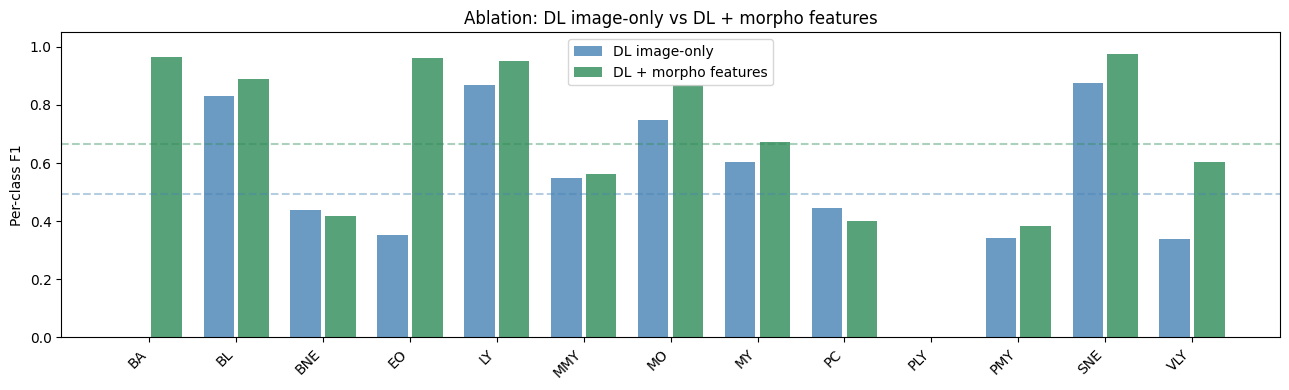


Morpho feature net contribution: macro-F1 +0.1733


In [ ]:
# ============================================================
# 7c. ABLATION — Contribution of morphological features
# ============================================================
# Inference-only, no retraining: evaluate model with tab=zeros
# to isolate tabular branch contribution.
# ============================================================

print("Ablation study (inference only, no retraining)")
print("=" * 55)

model.eval()
zeroed_preds = []
with torch.no_grad():
    for imgs, tab_feats, _, _, _ in DataLoader(val_ds, batch_size=BATCH_SIZE,
                                                shuffle=False, num_workers=4, pin_memory=True):
        imgs = imgs.to(device)
        zeros = torch.zeros_like(tab_feats).to(device)
        with torch.amp.autocast('cuda', enabled=(device.type == 'cuda')):
            outputs = model(imgs, zeros, return_aux=False)
        zeroed_preds.extend(outputs.argmax(dim=1).cpu().numpy())

zeroed_preds = np.array(zeroed_preds)
zeroed_f1 = f1_score(val_labels, zeroed_preds, average='macro')

print(f"  {'Model':<30s}  {'Val macro-F1':>12s}  {'Delta':>8s}")
print(f"  {'-'*55}")
print(f"  {'DL image-only (tab=zeros)':<30s}  {zeroed_f1:>12.4f}  {'(ref)':>8s}")
print(f"  {'DL + morpho features':<30s}  {val_f1:>12.4f}  {val_f1 - zeroed_f1:>+8.4f}")
print(f"  {'Backbone features + RF':<30s}  {rf_val_f1:>12.4f}  {rf_val_f1 - zeroed_f1:>+8.4f}")
print(f"  {'='*55}")

# Per-class impact of tabular features
f1_zeroed_per_class = f1_score(val_labels, zeroed_preds, average=None)
f1_full_per_class   = f1_score(val_labels, val_preds, average=None)
delta_per_class     = f1_full_per_class - f1_zeroed_per_class

print(f"\n  Per-class F1 gain from morpho features (DL+morpho - DL-only):")
print(f"  {'Class':<8s}  {'DL-only':>8s}  {'DL+morpho':>9s}  {'Delta':>7s}")
print(f"  {'-'*38}")
for i, cls in enumerate(dl_le.classes_):
    mark = " +" if delta_per_class[i] > 0.02 else (" -" if delta_per_class[i] < -0.02 else "  ")
    print(f"  {cls:<8s}  {f1_zeroed_per_class[i]:>8.3f}  {f1_full_per_class[i]:>9.3f}  {delta_per_class[i]:>+7.3f}{mark}")

fig, ax = plt.subplots(figsize=(13, 4))
x = np.arange(num_classes)
ax.bar(x - 0.2, f1_zeroed_per_class, 0.35, label='DL image-only', color='steelblue', alpha=0.8)
ax.bar(x + 0.2, f1_full_per_class, 0.35, label='DL + morpho features', color='seagreen', alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(dl_le.classes_, rotation=45, ha='right')
ax.set_ylabel('Per-class F1')
ax.set_title('Ablation: DL image-only vs DL + morpho features')
ax.legend()
ax.axhline(zeroed_f1, color='steelblue', linestyle='--', alpha=0.4, label=f'Macro (DL-only)={zeroed_f1:.3f}')
ax.axhline(val_f1, color='seagreen', linestyle='--', alpha=0.4, label=f'Macro (DL+morpho)={val_f1:.3f}')
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.show()

print(f"\nMorpho feature net contribution: macro-F1 {val_f1 - zeroed_f1:+.4f}")

  DETAILED RESULTS - LateFusion-DL (Val set)
  Overall accuracy: 0.9256  |  Macro-F1: 0.6654
  Class     Prec  Recall      F1     Acc  Support  Status
  -----------------------------------------------------------------
  BA       0.976   0.952   0.964   0.952       42  Good
  BL       0.850   0.930   0.888   0.930      201  
  BNE      0.365   0.487   0.418   0.487       39  CRITICAL
  EO       0.944   0.977   0.960   0.977       86  Good
  LY       0.953   0.949   0.951   0.949      810  Good
  MMY      0.643   0.500   0.562   0.500       36  Weak
  MO       0.858   0.880   0.869   0.880      275  
  MY       0.667   0.682   0.674   0.682       44  Weak
  PC       0.667   0.286   0.400   0.286        7  CRITICAL
  PLY      0.000   0.000   0.000   0.000        1  CRITICAL
  PMY      0.333   0.455   0.385   0.455       11  CRITICAL
  SNE      0.983   0.969   0.976   0.969     1302  Good
  VLY      0.731   0.514   0.603   0.514       37  Weak

  Ranked worst -> best:
     1. PLY    F1=0.

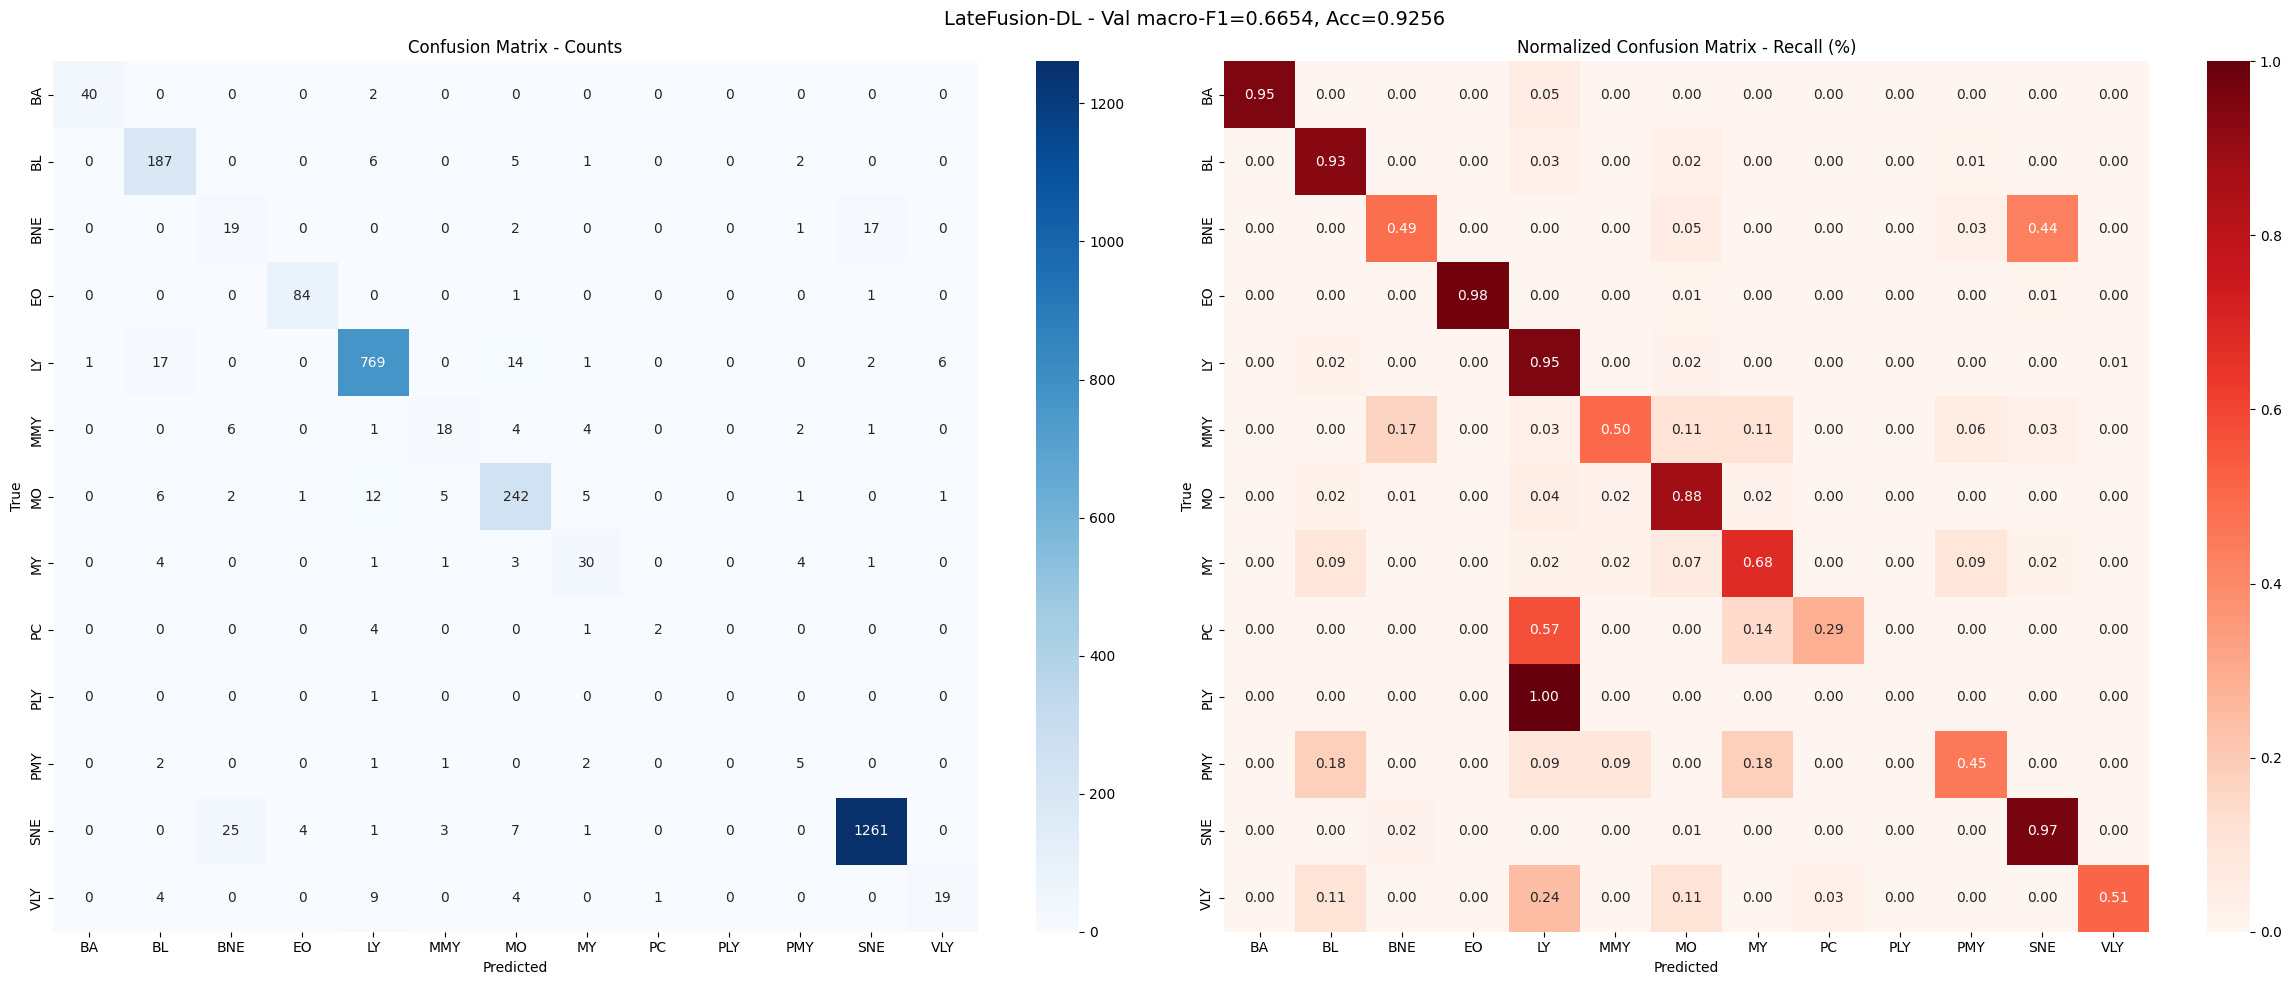


  TP / TN / FP / FN per class (one-vs-rest)
  Class       TP      TN      FP      FN
  ---------------------------------------------
  BA          40    2848       1       2
  BL         187    2657      33      14
  BNE         19    2819      33      20
  EO          84    2800       5       2
  LY         769    2043      38      41
  MMY         18    2845      10      18
  MO         242    2576      40      33
  MY          30    2832      15      14
  PC           2    2883       1       5
  PLY          0    2890       0       1
  PMY          5    2870      10       6
  SNE       1261    1567      22      41
  VLY         19    2847       7      18

  TOP CONFUSED CLASS PAIRS (off-diagonal errors)
   1. SNE -> BNE: 25 errors (1.9% of true SNE)
   2. LY -> BL: 17 errors (2.1% of true LY)
   3. BNE -> SNE: 17 errors (43.6% of true BNE)
   4. LY -> MO: 14 errors (1.7% of true LY)
   5. MO -> LY: 12 errors (4.4% of true MO)
   6. VLY -> LY: 9 errors (24.3% of true VLY)
   7. SNE 

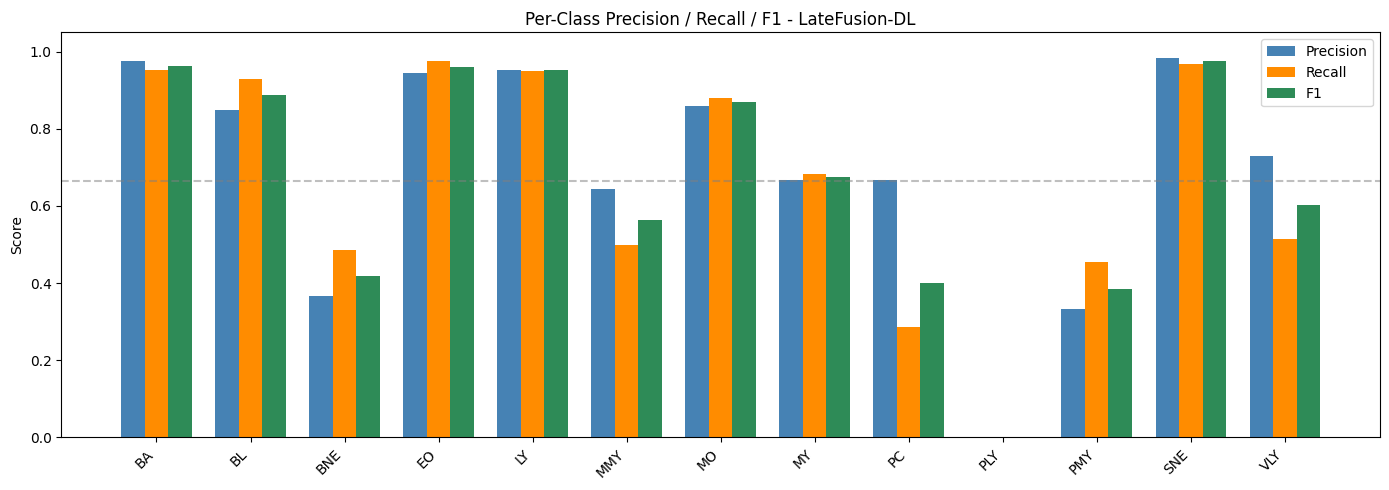


  CONFIDENCE ANALYSIS
  Mean confidence (all):     0.874
  Mean confidence (correct): 0.893
  Mean confidence (wrong):   0.631


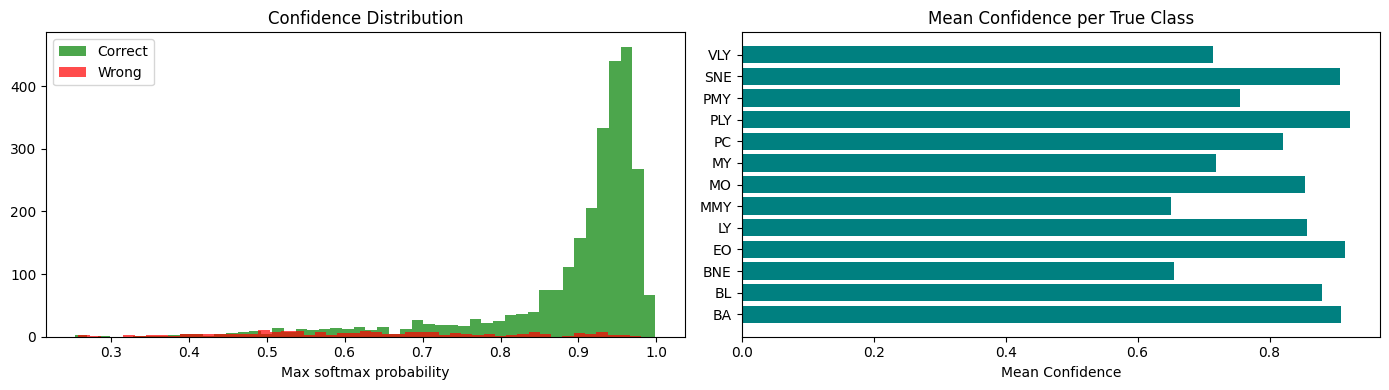


  Predictions with confidence < 0.5: 101 / 2891 (3.5%)
  Low-confidence samples come from:
    LY: 23
    MO: 21
    SNE: 17
    BL: 10
    MMY: 8
    VLY: 7
    BNE: 7
    MY: 4
    EO: 2
    PMY: 1
    BA: 1

  MISCLASSIFIED EXAMPLES (worst errors)


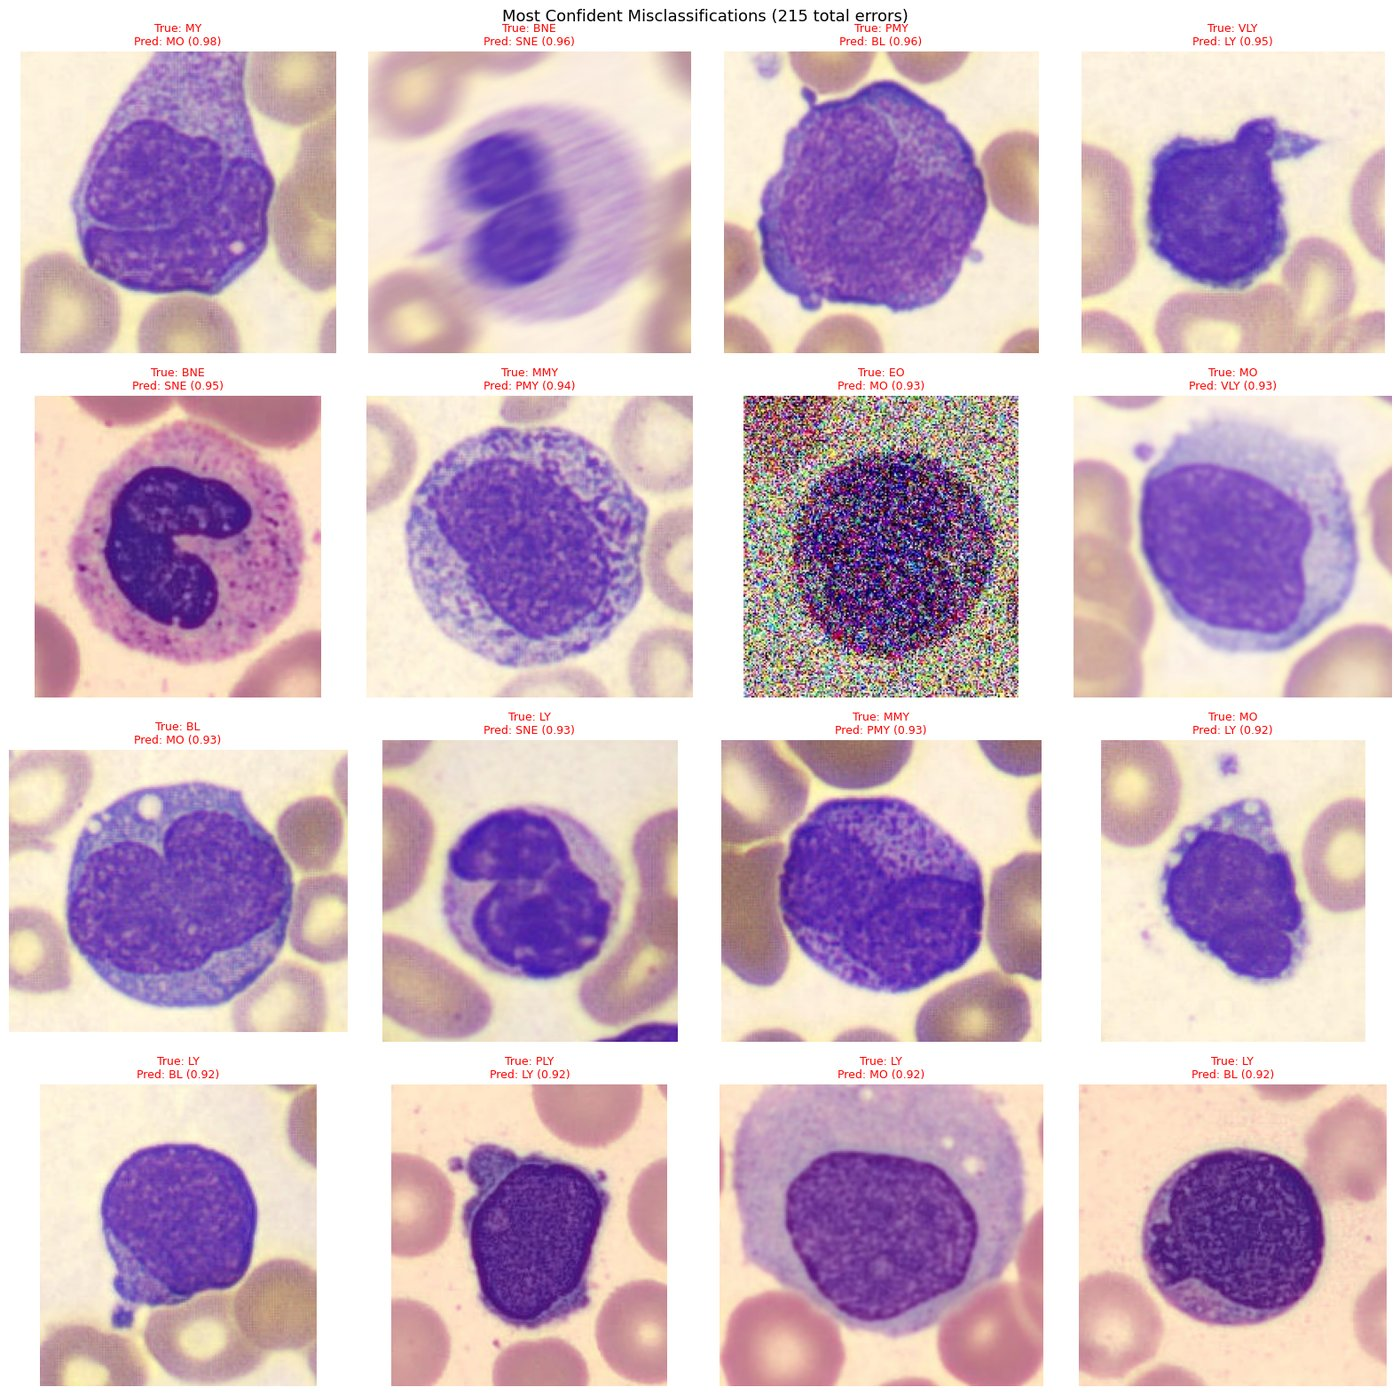


Detailed analysis complete.


In [ ]:
# ============================================================
# 7b. DETAILED RESULTS ANALYSIS
# ============================================================
# Per-class accuracy, precision, recall, F1, support
# Normalized confusion matrix (recall-based)
# TP/TN/FP/FN per class
# Top confused class pairs
# Misclassified examples visualization
# Confidence distribution analysis
# ============================================================

best_preds = best_approach[2]
best_name = best_approach[0]

# ---- 1. Per-class metrics table ----
from sklearn.metrics import precision_recall_fscore_support, accuracy_score

prec, rec, f1_arr, supp = precision_recall_fscore_support(
    val_labels, best_preds, average=None, zero_division=0)

overall_acc = accuracy_score(val_labels, best_preds)
overall_f1 = f1_score(val_labels, best_preds, average='macro')

print(f"{'='*75}")
print(f"  DETAILED RESULTS - {best_name} (Val set)")
print(f"{'='*75}")
print(f"  Overall accuracy: {overall_acc:.4f}  |  Macro-F1: {overall_f1:.4f}")
print(f"{'='*75}")
print(f"  {'Class':<6s}  {'Prec':>6s}  {'Recall':>6s}  {'F1':>6s}  {'Acc':>6s}  {'Support':>7s}  {'Status'}")
print(f"  {'-'*65}")

for i, cls in enumerate(dl_le.classes_):
    cls_mask = val_labels == i
    cls_acc = (best_preds[cls_mask] == i).sum() / max(cls_mask.sum(), 1)
    status = ""
    if f1_arr[i] < 0.5:
        status = "CRITICAL"
    elif f1_arr[i] < 0.7:
        status = "Weak"
    elif f1_arr[i] >= 0.9:
        status = "Good"
    print(f"  {cls:<6s}  {prec[i]:>6.3f}  {rec[i]:>6.3f}  {f1_arr[i]:>6.3f}  "
          f"{cls_acc:>6.3f}  {supp[i]:>7d}  {status}")

# Sort by F1 to show worst classes
worst_idx = np.argsort(f1_arr)
print(f"\n  Ranked worst -> best:")
for rank, i in enumerate(worst_idx, 1):
    print(f"    {rank:2d}. {dl_le.classes_[i]:<6s} F1={f1_arr[i]:.3f} "
          f"(prec={prec[i]:.3f}, rec={rec[i]:.3f}, n={supp[i]})")

# ---- 2. Confusion matrix + TP/TN/FP/FN ----
cm_raw = confusion_matrix(val_labels, best_preds)
cm_norm = cm_raw.astype(float) / cm_raw.sum(axis=1, keepdims=True).clip(min=1)

fig, axes = plt.subplots(1, 2, figsize=(24, 10))

# Raw counts
sns.heatmap(cm_raw, annot=True, fmt='d', cmap='Blues',
            xticklabels=dl_le.classes_, yticklabels=dl_le.classes_, ax=axes[0])
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('True')
axes[0].set_title('Confusion Matrix - Counts')

# Normalized (recall per row)
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Reds',
            xticklabels=dl_le.classes_, yticklabels=dl_le.classes_, ax=axes[1])
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('True')
axes[1].set_title('Normalized Confusion Matrix - Recall (%)')

plt.suptitle(f'{best_name} - Val macro-F1={overall_f1:.4f}, Acc={overall_acc:.4f}', fontsize=14)
plt.tight_layout()
plt.show()

# Explicit TP/TN/FP/FN per class (one-vs-rest)
tp = np.diag(cm_raw)
fp = cm_raw.sum(axis=0) - tp
fn = cm_raw.sum(axis=1) - tp
tn = cm_raw.sum() - (tp + fp + fn)

print(f"\n{'='*75}")
print("  TP / TN / FP / FN per class (one-vs-rest)")
print(f"{'='*75}")
print(f"  {'Class':<6s}  {'TP':>6s}  {'TN':>6s}  {'FP':>6s}  {'FN':>6s}")
print(f"  {'-'*45}")
for i, cls in enumerate(dl_le.classes_):
    print(f"  {cls:<6s}  {int(tp[i]):>6d}  {int(tn[i]):>6d}  {int(fp[i]):>6d}  {int(fn[i]):>6d}")

# ---- 3. Top confused class pairs ----
print(f"\n{'='*60}")
print("  TOP CONFUSED CLASS PAIRS (off-diagonal errors)")
print(f"{'='*60}")
n_errors_shown = 10
errors = []
for true_i in range(num_classes):
    for pred_j in range(num_classes):
        if true_i != pred_j and cm_raw[true_i, pred_j] > 0:
            errors.append((cm_raw[true_i, pred_j],
                          dl_le.classes_[true_i], dl_le.classes_[pred_j],
                          cm_norm[true_i, pred_j]))
errors.sort(reverse=True)
for rank, (cnt, true_cls, pred_cls, rate) in enumerate(errors[:n_errors_shown], 1):
    print(f"  {rank:2d}. {true_cls} -> {pred_cls}: {cnt} errors ({rate:.1%} of true {true_cls})")

# ---- 4. Per-class bar chart ----
fig, ax = plt.subplots(figsize=(14, 5))
x = np.arange(num_classes)
width = 0.25
ax.bar(x - width, prec, width, label='Precision', color='steelblue')
ax.bar(x, rec, width, label='Recall', color='darkorange')
ax.bar(x + width, f1_arr, width, label='F1', color='seagreen')
ax.set_xticks(x)
ax.set_xticklabels(dl_le.classes_, rotation=45, ha='right')
ax.set_ylabel('Score')
ax.set_title(f'Per-Class Precision / Recall / F1 - {best_name}')
ax.legend()
ax.axhline(y=overall_f1, color='gray', linestyle='--', alpha=0.5, label=f'Macro-F1={overall_f1:.3f}')
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.show()

# ---- 5. Confidence analysis ----
if val_probs is not None:
    print(f"\n{'='*60}")
    print("  CONFIDENCE ANALYSIS")
    print(f"{'='*60}")

    val_confs = val_probs.max(axis=1)
    val_pred_classes = val_probs.argmax(axis=1)
    correct_mask = val_pred_classes == val_labels

    print(f"  Mean confidence (all):     {val_confs.mean():.3f}")
    print(f"  Mean confidence (correct): {val_confs[correct_mask].mean():.3f}")
    print(f"  Mean confidence (wrong):   {val_confs[~correct_mask].mean():.3f}")

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    axes[0].hist(val_confs[correct_mask], bins=50, alpha=0.7, color='green', label='Correct')
    axes[0].hist(val_confs[~correct_mask], bins=50, alpha=0.7, color='red', label='Wrong')
    axes[0].set_title('Confidence Distribution')
    axes[0].set_xlabel('Max softmax probability')
    axes[0].legend()

    cls_conf = []
    for i in range(num_classes):
        mask = val_labels == i
        cls_conf.append(val_confs[mask].mean() if mask.sum() > 0 else 0)
    axes[1].barh(dl_le.classes_, cls_conf, color='teal')
    axes[1].set_xlabel('Mean Confidence')
    axes[1].set_title('Mean Confidence per True Class')
    plt.tight_layout()
    plt.show()

    LOW_CONF_THR = 0.5
    low_conf_mask = val_confs < LOW_CONF_THR
    print(f"\n  Predictions with confidence < {LOW_CONF_THR}: "
          f"{low_conf_mask.sum()} / {len(val_confs)} ({100*low_conf_mask.mean():.1f}%)")
    if low_conf_mask.sum() > 0:
        low_conf_classes = val_labels[low_conf_mask]
        low_conf_dist = pd.Series(dl_le.inverse_transform(low_conf_classes)).value_counts()
        print("  Low-confidence samples come from:")
        for cls, cnt in low_conf_dist.items():
            print(f"    {cls}: {cnt}")

# ---- 6. Show misclassified examples ----
print(f"\n{'='*60}")
print("  MISCLASSIFIED EXAMPLES (worst errors)")
print(f"{'='*60}")

wrong_mask = best_preds != val_labels
wrong_indices = np.where(wrong_mask)[0]

if len(wrong_indices) > 0:
    if val_probs is not None:
        wrong_confs = val_probs[wrong_indices].max(axis=1)
        sorted_wrong = wrong_indices[np.argsort(-wrong_confs)]
    else:
        sorted_wrong = wrong_indices

    n_show = min(16, len(sorted_wrong))
    ncols = 4
    nrows = (n_show + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 4 * nrows))
    fig.suptitle(f"Most Confident Misclassifications ({len(wrong_indices)} total errors)", fontsize=13)
    axes_flat = axes.flatten() if hasattr(axes, 'flatten') else [axes]

    for k in range(n_show):
        idx = sorted_wrong[k]
        val_row = val_fold_df.iloc[idx]
        img_path = TRAIN_IMG_DIR / val_row['ID']
        try:
            img = np.array(Image.open(img_path).convert('RGB'))
        except Exception:
            img = np.zeros((100, 100, 3), dtype=np.uint8)

        true_cls = dl_le.inverse_transform([val_labels[idx]])[0]
        pred_cls = dl_le.inverse_transform([best_preds[idx]])[0]
        conf = val_probs[idx].max() if val_probs is not None else 0

        ax = axes_flat[k]
        ax.imshow(img)
        ax.set_title(f"True: {true_cls}\nPred: {pred_cls} ({conf:.2f})", fontsize=9, color='red')
        ax.axis('off')

    for k in range(n_show, len(axes_flat)):
        axes_flat[k].axis('off')

    plt.tight_layout()
    plt.show()
else:
    print("  No misclassifications!")

print("\nDetailed analysis complete.")

## deep_9 — ConvNeXt-Base + SE attention gate, morphology ablation

Back to the ConvNeXt-Base backbone (as in deep_6), with a lightweight
**Squeeze-and-Excitation-style attention gate** on the global features (rather than
spatial/CBAM attention), HSV V-channel CLAHE preprocessing (`USE_HSV_CLAHE`), and an optional
6-feature morphology branch controlled by the `USE_HANDCRAFTED_FEATURES` flag. Two otherwise
identical runs are compared; only this flag changes:

- original deep_9 with-morph notebook → `USE_HANDCRAFTED_FEATURES = True`
- original deep_9 no-morph notebook → `USE_HANDCRAFTED_FEATURES = False`

Result: **deep_9 with-morph = 0.7036**, **deep_9 no-morph = 0.7052**, a negligible difference
(< 0.002). These 6 handcrafted features bring no additional information to this model, which makes
the tabular branch redundant here. **deep_9 no-morph is the
final model.**

In [ ]:
# deep_9 — key flag USE_HANDCRAFTED_FEATURES (True in with-morph, False in no-morph) + SE attention gate + optional morphology branch
# --- original deep_9 with-morph notebook ----------------------------------
IMAGENET_STD  = [0.229, 0.224, 0.225]

# New toggles
USE_HSV_CLAHE = True
USE_HANDCRAFTED_FEATURES = True
N_MORPH_FEATURES = 6


# --- original deep_9 no-morph notebook ------------------------------------
IMAGENET_STD  = [0.229, 0.224, 0.225]

# New toggles
USE_HSV_CLAHE = True
USE_HANDCRAFTED_FEATURES = False
N_MORPH_FEATURES = 6


# --- Model: ConvNeXt-Base + SE attention gate + optional morphology branch ---
class WBCClassifier(nn.Module):
    """ConvNeXt-Base + channel attention (SE style, new compared with deep_6/8) +
    optional morphology branch switched on/off via USE_HANDCRAFTED_FEATURES."""
    def __init__(self, num_classes=13, dropout=0.3, pretrained=True, n_morph_features=6):
        super().__init__()
        weights = ConvNeXt_Base_Weights.DEFAULT if pretrained else None
        full_model = convnext_base(weights=weights)
        self.backbone = nn.Sequential(full_model.features, full_model.avgpool)
        gate_hidden = max(self.feat_dim // 8, 64)
        self.feature_gate = nn.Sequential(  # lightweight SE-style attention gate
            nn.Linear(self.feat_dim, gate_hidden), nn.ReLU(inplace=True),
            nn.Linear(gate_hidden, self.feat_dim), nn.Sigmoid(),
        )
        self.use_morph = n_morph_features is not None and n_morph_features > 0
        if self.use_morph:
            self.morph_branch = nn.Sequential(
                nn.Linear(int(n_morph_features), 64), nn.ReLU(inplace=True),
                nn.Dropout(dropout), nn.Linear(64, 64), nn.ReLU(inplace=True))
        # head_in = feat_dim (+ 64 if use_morph) -> 3-layer MLP head -> num_classes

### Results — deep_9 with-morph (`USE_HANDCRAFTED_FEATURES = True`)

Val backbone features shape: (2891, 1024)
Train backbone features shape: (27081, 1024)

Hybrid Features+RF val macro-F1:  0.6810
DL ConvNeXt val macro-F1:          0.7036

★ Best approach: ConvNeXt-DL (macro-F1=0.7036)


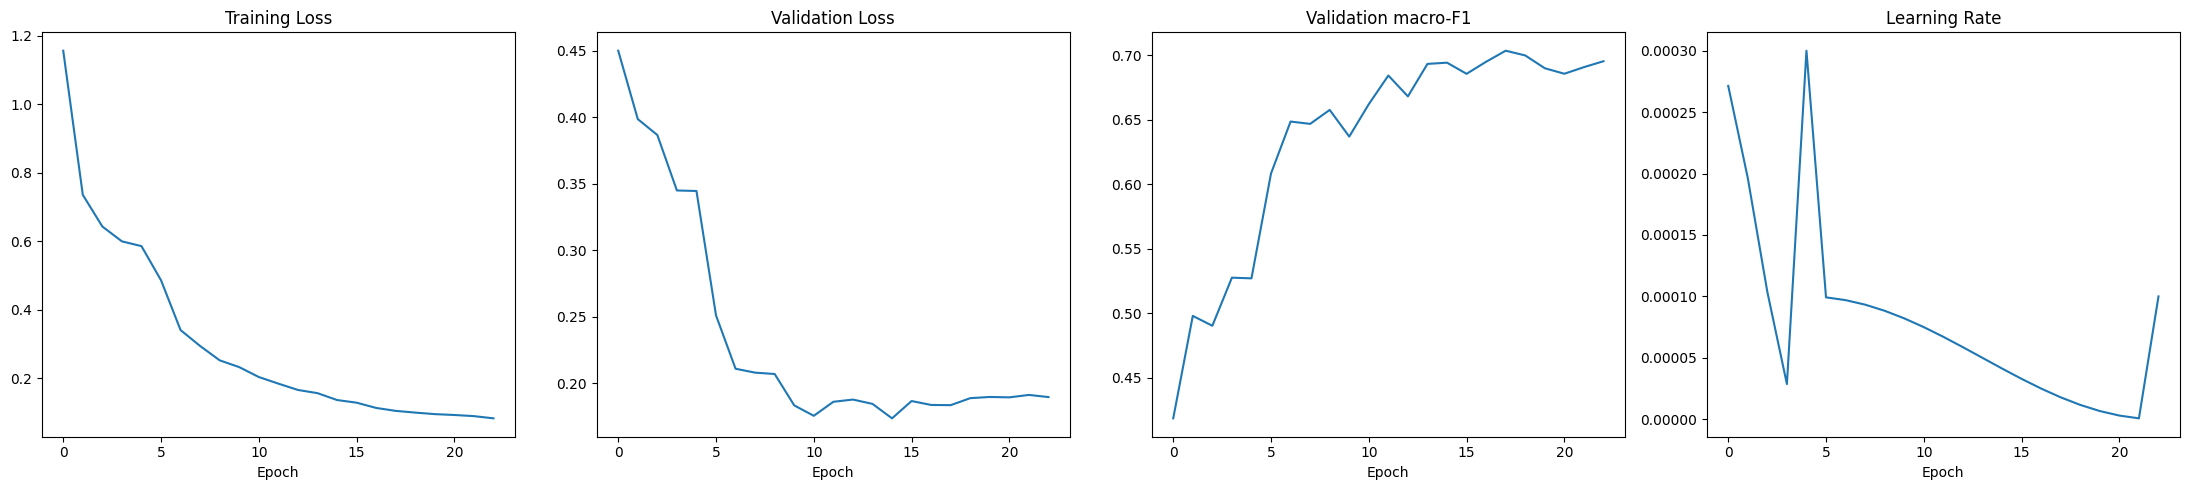

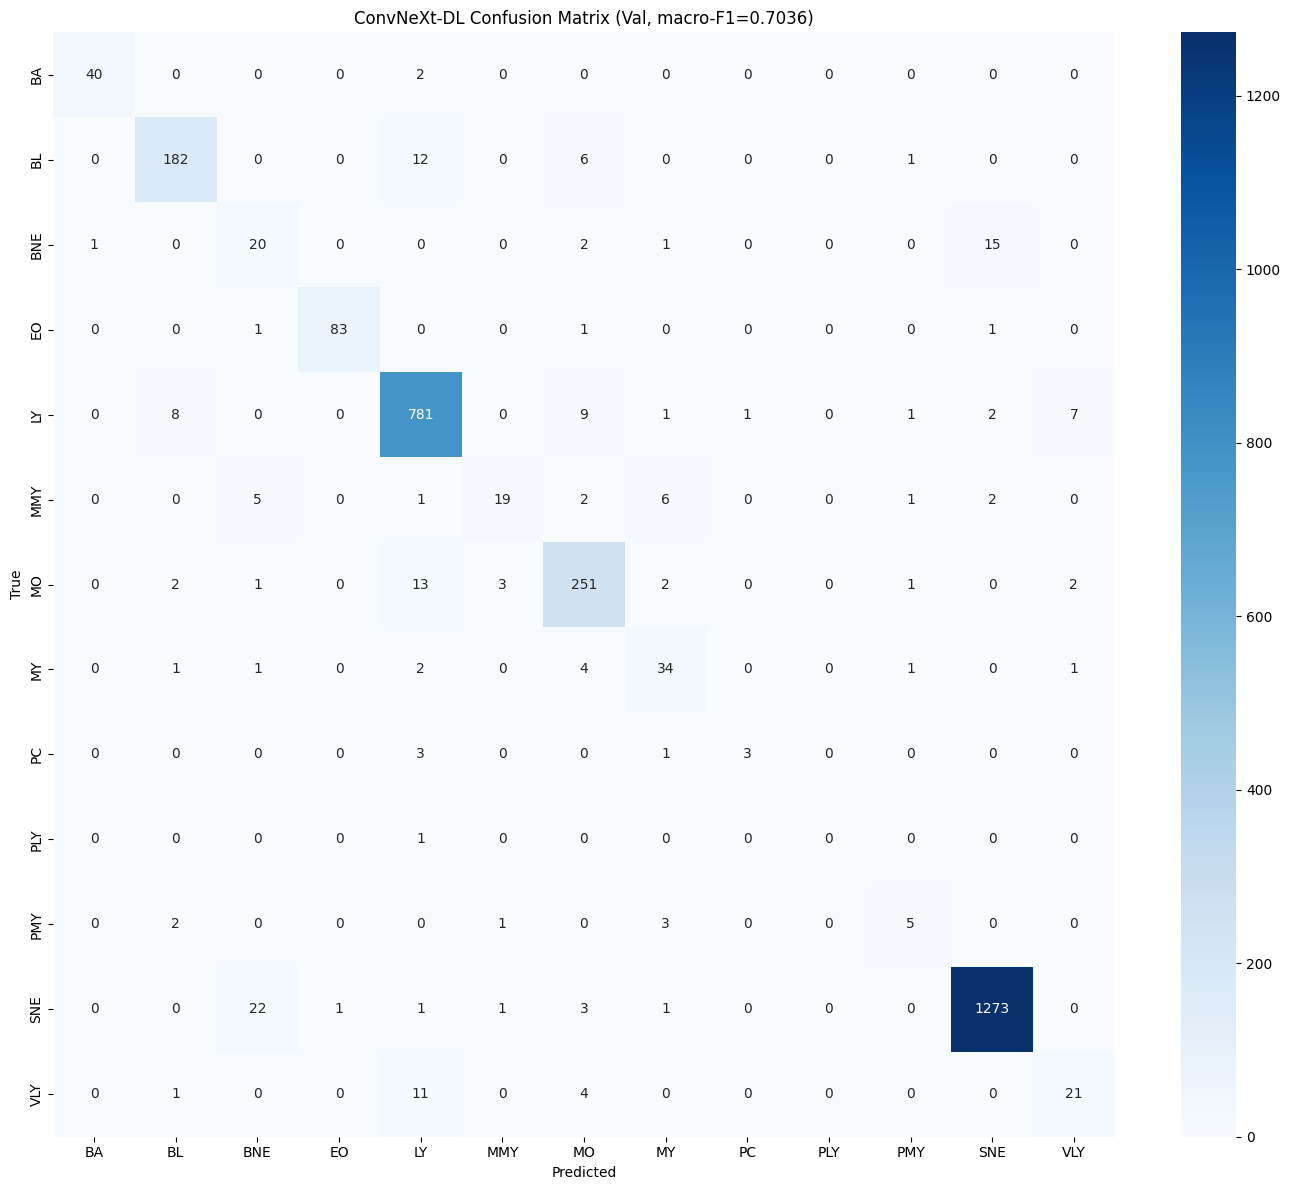

Per-class F1 scores (ConvNeXt-DL):
  BA   (n=   42): F1 = 0.9639
  BL   (n=  201): F1 = 0.9169
  BNE  (n=   39): F1 = 0.4494
  EO   (n=   86): F1 = 0.9765
  LY   (n=  810): F1 = 0.9542
  MMY  (n=   36): F1 = 0.6333
  MO   (n=  275): F1 = 0.9013
  MY   (n=   44): F1 = 0.7312
  PC   (n=    7): F1 = 0.5455
  PLY  (n=    1): F1 = 0.0000
  PMY  (n=   11): F1 = 0.4762
  SNE  (n= 1302): F1 = 0.9811
  VLY  (n=   37): F1 = 0.6176


In [ ]:
# ============================================================
# 7. HYBRID APPROACH: Backbone Features → Random Forest
# ============================================================

print(f"Val backbone features shape: {val_features.shape}")

# ---- Extract train backbone features ----
train_features_list = []
model.eval()
with torch.no_grad():
    for imgs, morph, _ in DataLoader(train_ds, batch_size=BATCH_SIZE,
                                     shuffle=False, num_workers=4, pin_memory=True):
        imgs = imgs.to(device)
        with torch.amp.autocast('cuda'):
            feats = model.extract_features(imgs)
        train_features_list.append(feats.float().cpu().numpy())
train_features = np.concatenate(train_features_list)
train_labels_enc = dl_le.transform(train_fold_df['label'])
print(f"Train backbone features shape: {train_features.shape}")

# ---- Random Forest on backbone features ----
rf = RandomForestClassifier(n_estimators=500, max_depth=None, min_samples_leaf=2,
                             class_weight='balanced', n_jobs=-1, random_state=SEED)
rf.fit(train_features, train_labels_enc)
rf_val_preds = rf.predict(val_features)
rf_val_f1 = f1_score(val_labels, rf_val_preds, average='macro')
print(f"\nHybrid Features+RF val macro-F1:  {rf_val_f1:.4f}")
print(f"DL ConvNeXt val macro-F1:          {val_f1:.4f}")

# ---- Choose best ----
best_approach = max(
    [('ConvNeXt-DL', val_f1, val_preds),
     ('Features+RF', rf_val_f1, rf_val_preds)],
    key=lambda x: x[1]
)
print(f"\n★ Best approach: {best_approach[0]} (macro-F1={best_approach[1]:.4f})")
USE_HYBRID = best_approach[0]
final_val_f1 = best_approach[1]

# ---- Training curves ----
fig, axes = plt.subplots(1, 4, figsize=(22, 5))
for data, ax, title in zip(
    [history['train_loss'], history['val_loss'], history['val_f1'], history['lr']],
    axes, ['Training Loss', 'Validation Loss', 'Validation macro-F1', 'Learning Rate']):
    ax.plot(data)
    ax.set_title(title)
    ax.set_xlabel('Epoch')
plt.tight_layout()
plt.show()

# ---- Confusion Matrix ----
cm = confusion_matrix(val_labels, best_approach[2])
fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=dl_le.classes_, yticklabels=dl_le.classes_, ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_title(f'{best_approach[0]} Confusion Matrix (Val, macro-F1={final_val_f1:.4f})')
plt.tight_layout()
plt.show()

# Per-class F1
print(f"Per-class F1 scores ({best_approach[0]}):")
f1_per_class = f1_score(val_labels, best_approach[2], average=None)
for cls_name, f1_val in zip(dl_le.classes_, f1_per_class):
    count = np.sum(val_labels == dl_le.transform([cls_name])[0])
    print(f"  {cls_name:4s} (n={count:5d}): F1 = {f1_val:.4f}")

  DETAILED RESULTS — ConvNeXt-DL (Val set)
  Overall accuracy: 0.9381  |  Macro-F1: 0.7036
  Class     Prec  Recall      F1     Acc  Support  Status
  -----------------------------------------------------------------
  BA       0.976   0.952   0.964   0.952       42  ✓ Good
  BL       0.929   0.905   0.917   0.905      201  ✓ Good
  BNE      0.400   0.513   0.449   0.513       39  ⚠ CRITICAL
  EO       0.988   0.965   0.976   0.965       86  ✓ Good
  LY       0.944   0.964   0.954   0.964      810  ✓ Good
  MMY      0.792   0.528   0.633   0.528       36  ⚠ Weak
  MO       0.890   0.913   0.901   0.913      275  ✓ Good
  MY       0.694   0.773   0.731   0.773       44  
  PC       0.750   0.429   0.545   0.429        7  ⚠ Weak
  PLY      0.000   0.000   0.000   0.000        1  ⚠ CRITICAL
  PMY      0.500   0.455   0.476   0.455       11  ⚠ CRITICAL
  SNE      0.985   0.978   0.981   0.978     1302  ✓ Good
  VLY      0.677   0.568   0.618   0.568       37  ⚠ Weak

  Ranked worst → best:

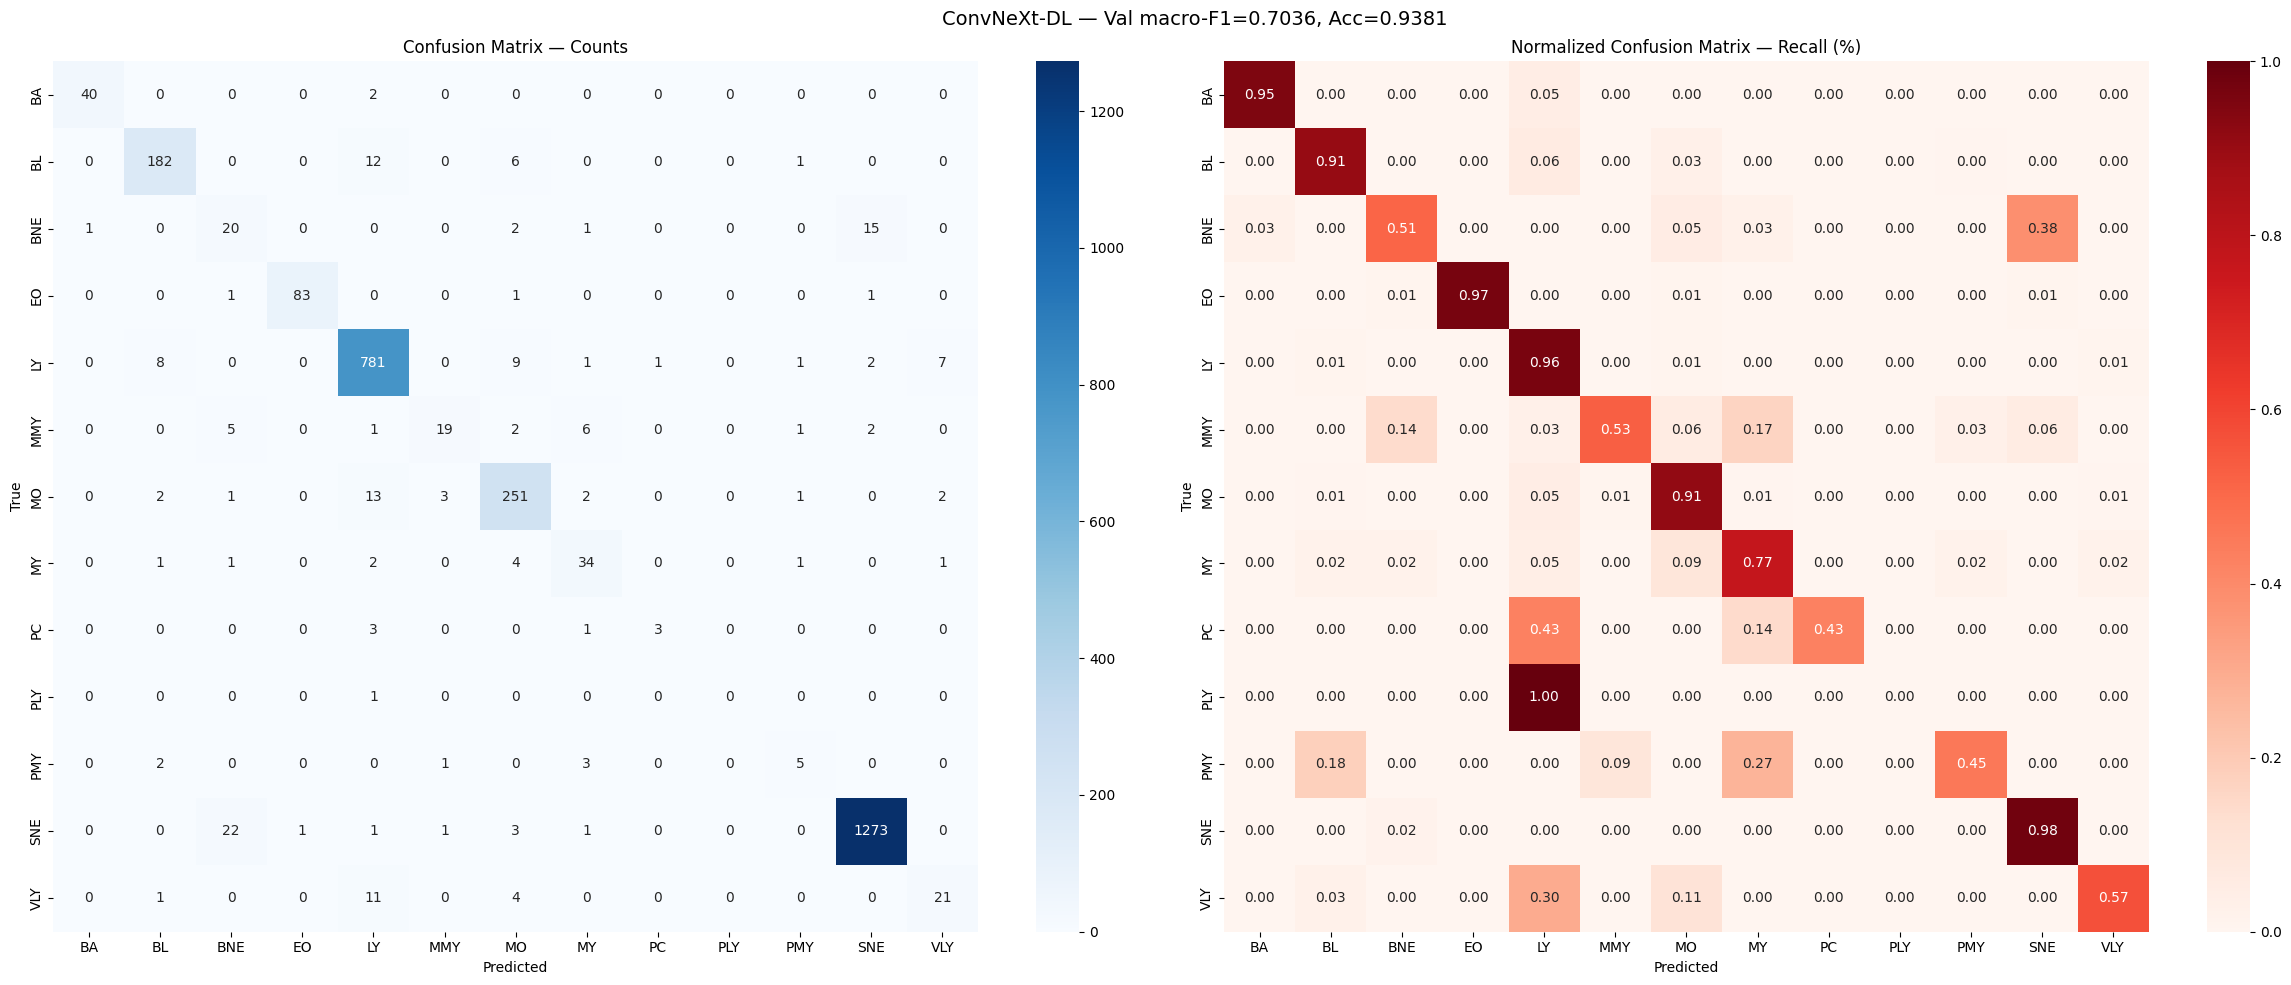


  TOP CONFUSED CLASS PAIRS (off-diagonal errors)
   1. SNE → BNE: 22 errors (1.7% of true SNE)
   2. BNE → SNE: 15 errors (38.5% of true BNE)
   3. MO → LY: 13 errors (4.7% of true MO)
   4. BL → LY: 12 errors (6.0% of true BL)
   5. VLY → LY: 11 errors (29.7% of true VLY)
   6. LY → MO: 9 errors (1.1% of true LY)
   7. LY → BL: 8 errors (1.0% of true LY)
   8. LY → VLY: 7 errors (0.9% of true LY)
   9. MMY → MY: 6 errors (16.7% of true MMY)
  10. BL → MO: 6 errors (3.0% of true BL)


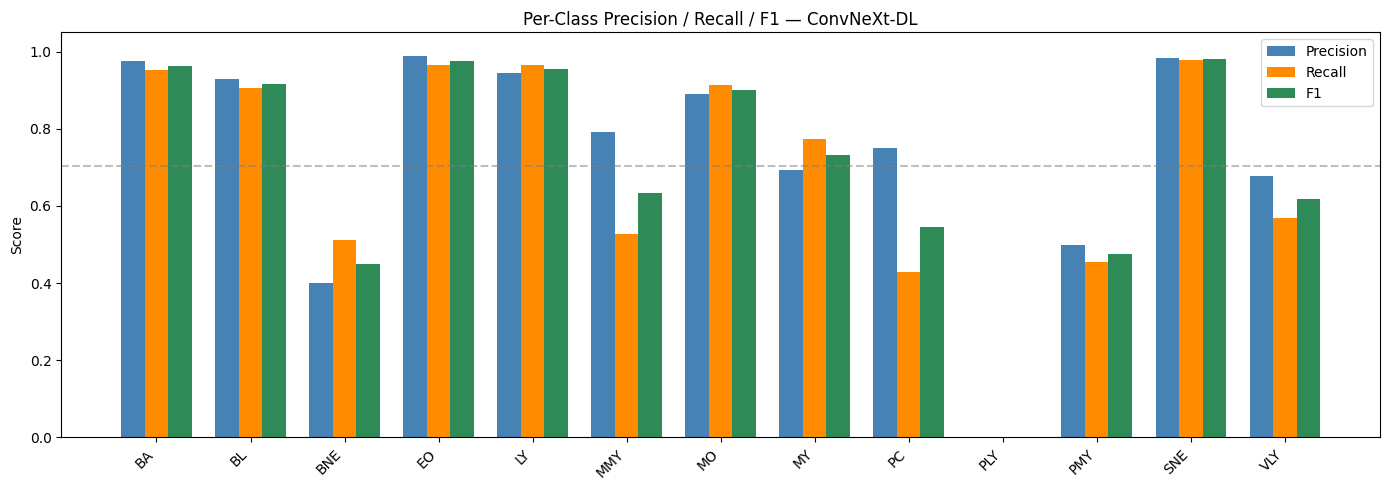


  CONFIDENCE ANALYSIS
  Mean confidence (all):     0.922
  Mean confidence (correct): 0.936
  Mean confidence (wrong):   0.706


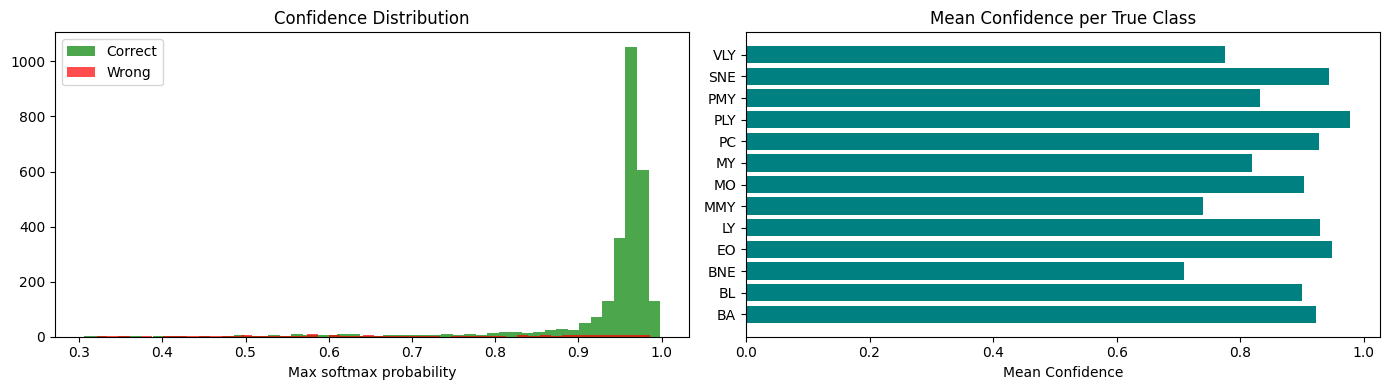


  Predictions with confidence < 0.5: 51 / 2891 (1.8%)
  Low-confidence samples come from:
    MO: 12
    BL: 7
    LY: 7
    SNE: 6
    BNE: 6
    MY: 5
    VLY: 3
    BA: 2
    MMY: 2
    EO: 1

  MISCLASSIFIED EXAMPLES (worst errors)


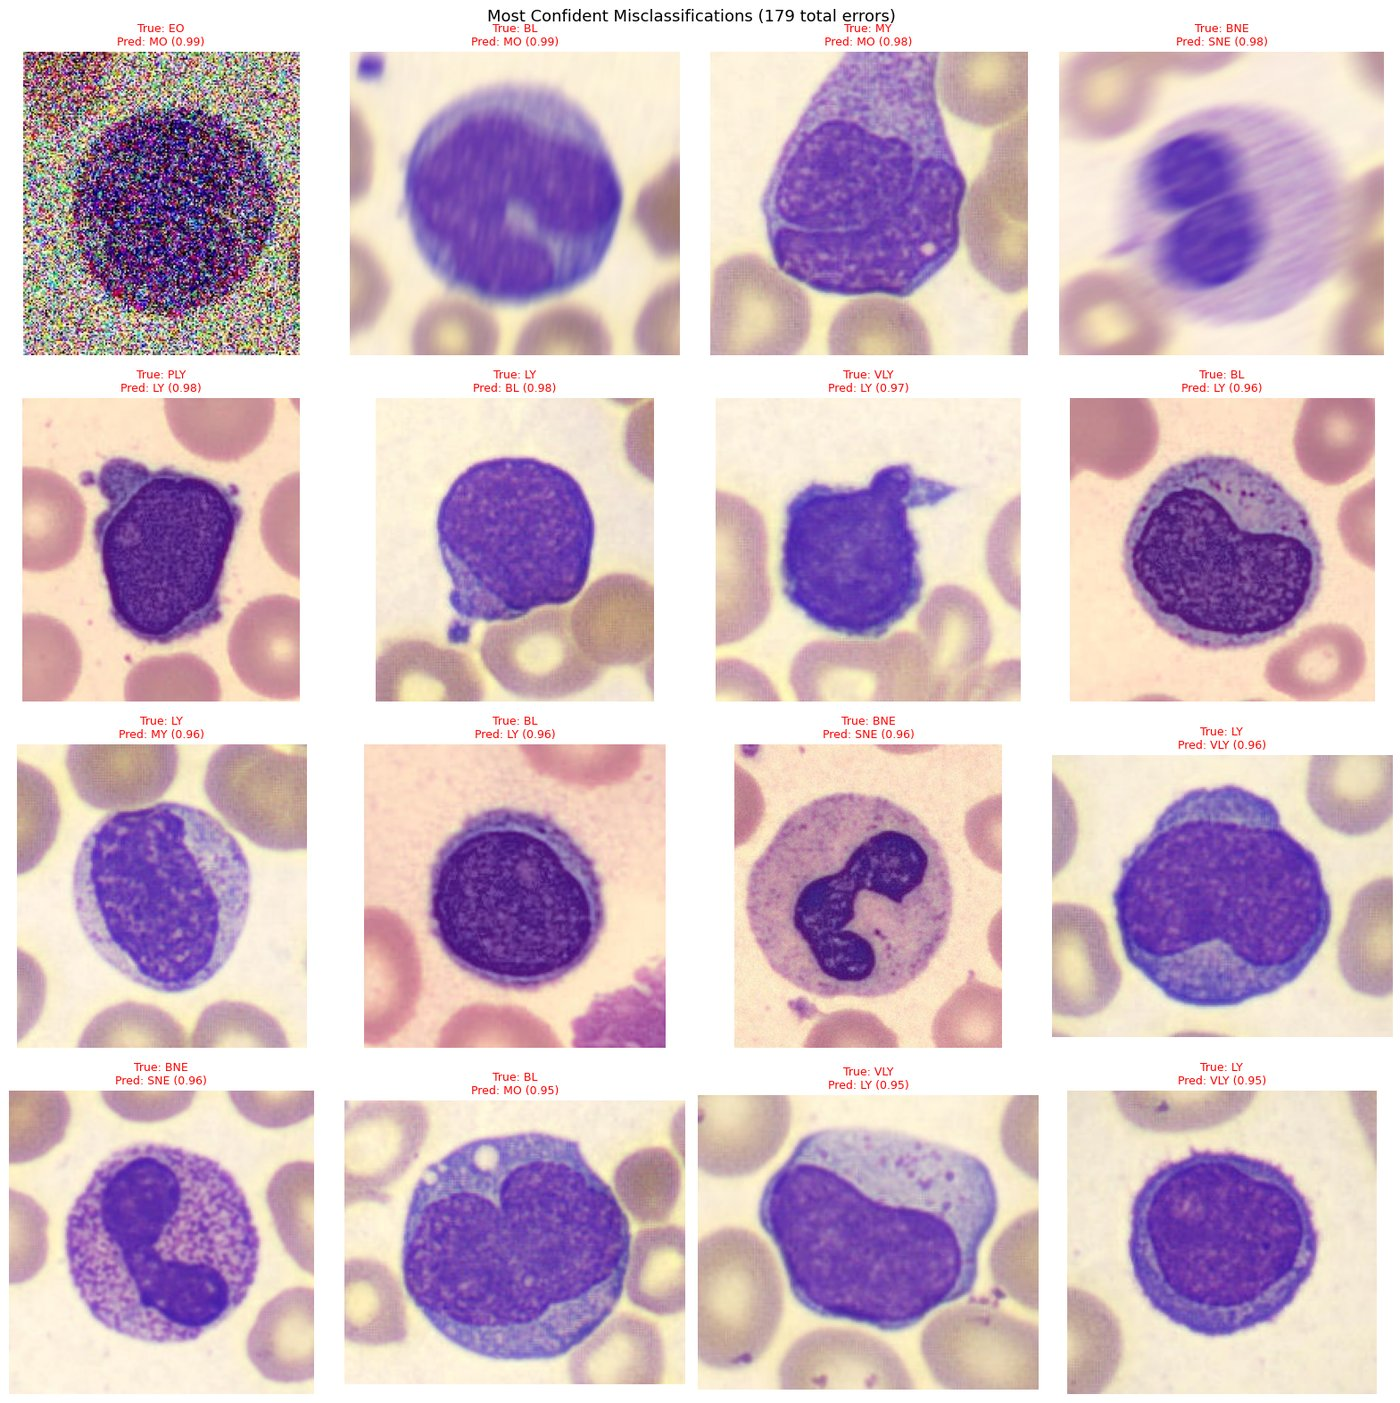


✓ Detailed analysis complete.


In [ ]:
# ============================================================
# 7b. DETAILED RESULTS ANALYSIS
# ============================================================
# Per-class accuracy, precision, recall, F1, support
# Normalized confusion matrix (recall-based)
# Top confused class pairs
# Misclassified examples visualization
# Confidence distribution analysis
# ============================================================

best_preds = best_approach[2]
best_name = best_approach[0]

# ---- 1. Per-class metrics table ----
from sklearn.metrics import precision_recall_fscore_support, accuracy_score

prec, rec, f1_arr, supp = precision_recall_fscore_support(
    val_labels, best_preds, average=None, zero_division=0)

overall_acc = accuracy_score(val_labels, best_preds)
overall_f1 = f1_score(val_labels, best_preds, average='macro')

print(f"{'='*75}")
print(f"  DETAILED RESULTS — {best_name} (Val set)")
print(f"{'='*75}")
print(f"  Overall accuracy: {overall_acc:.4f}  |  Macro-F1: {overall_f1:.4f}")
print(f"{'='*75}")
print(f"  {'Class':<6s}  {'Prec':>6s}  {'Recall':>6s}  {'F1':>6s}  {'Acc':>6s}  {'Support':>7s}  {'Status'}")
print(f"  {'-'*65}")

for i, cls in enumerate(dl_le.classes_):
    cls_mask = val_labels == i
    cls_acc = (best_preds[cls_mask] == i).sum() / max(cls_mask.sum(), 1)
    status = ""
    if f1_arr[i] < 0.5:
        status = "⚠ CRITICAL"
    elif f1_arr[i] < 0.7:
        status = "⚠ Weak"
    elif f1_arr[i] >= 0.9:
        status = "✓ Good"
    print(f"  {cls:<6s}  {prec[i]:>6.3f}  {rec[i]:>6.3f}  {f1_arr[i]:>6.3f}  "
          f"{cls_acc:>6.3f}  {supp[i]:>7d}  {status}")

# Sort by F1 to show worst classes
worst_idx = np.argsort(f1_arr)
print(f"\n  Ranked worst → best:")
for rank, i in enumerate(worst_idx, 1):
    print(f"    {rank:2d}. {dl_le.classes_[i]:<6s} F1={f1_arr[i]:.3f} "
          f"(prec={prec[i]:.3f}, rec={rec[i]:.3f}, n={supp[i]})")

# ---- 2. Normalized Confusion Matrix (recall-based) ----
cm_raw = confusion_matrix(val_labels, best_preds)
cm_norm = cm_raw.astype(float) / cm_raw.sum(axis=1, keepdims=True).clip(min=1)

fig, axes = plt.subplots(1, 2, figsize=(24, 10))

# Raw counts
sns.heatmap(cm_raw, annot=True, fmt='d', cmap='Blues',
            xticklabels=dl_le.classes_, yticklabels=dl_le.classes_, ax=axes[0])
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('True')
axes[0].set_title(f'Confusion Matrix — Counts')

# Normalized (recall per row)
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Reds',
            xticklabels=dl_le.classes_, yticklabels=dl_le.classes_, ax=axes[1])
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('True')
axes[1].set_title(f'Normalized Confusion Matrix — Recall (%)')

plt.suptitle(f'{best_name} — Val macro-F1={overall_f1:.4f}, Acc={overall_acc:.4f}', fontsize=14)
plt.tight_layout()
plt.show()

# ---- 3. Top confused class pairs ----
print(f"\n{'='*60}")
print("  TOP CONFUSED CLASS PAIRS (off-diagonal errors)")
print(f"{'='*60}")
n_errors_shown = 10
errors = []
for true_i in range(num_classes):
    for pred_j in range(num_classes):
        if true_i != pred_j and cm_raw[true_i, pred_j] > 0:
            errors.append((cm_raw[true_i, pred_j],
                          dl_le.classes_[true_i], dl_le.classes_[pred_j],
                          cm_norm[true_i, pred_j]))
errors.sort(reverse=True)
for rank, (cnt, true_cls, pred_cls, rate) in enumerate(errors[:n_errors_shown], 1):
    print(f"  {rank:2d}. {true_cls} → {pred_cls}: {cnt} errors ({rate:.1%} of true {true_cls})")

# ---- 4. Per-class bar chart ----
fig, ax = plt.subplots(figsize=(14, 5))
x = np.arange(num_classes)
width = 0.25
bars_p = ax.bar(x - width, prec, width, label='Precision', color='steelblue')
bars_r = ax.bar(x, rec, width, label='Recall', color='darkorange')
bars_f = ax.bar(x + width, f1_arr, width, label='F1', color='seagreen')
ax.set_xticks(x)
ax.set_xticklabels(dl_le.classes_, rotation=45, ha='right')
ax.set_ylabel('Score')
ax.set_title(f'Per-Class Precision / Recall / F1 — {best_name}')
ax.legend()
ax.axhline(y=overall_f1, color='gray', linestyle='--', alpha=0.5, label=f'Macro-F1={overall_f1:.3f}')
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.show()

# ---- 5. Confidence analysis ----
if val_probs is not None:
    print(f"\n{'='*60}")
    print("  CONFIDENCE ANALYSIS")
    print(f"{'='*60}")

    val_confs = val_probs.max(axis=1)
    val_pred_classes = val_probs.argmax(axis=1)
    correct_mask = val_pred_classes == val_labels

    print(f"  Mean confidence (all):     {val_confs.mean():.3f}")
    print(f"  Mean confidence (correct): {val_confs[correct_mask].mean():.3f}")
    print(f"  Mean confidence (wrong):   {val_confs[~correct_mask].mean():.3f}")

    # Confidence histogram for correct vs wrong
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    axes[0].hist(val_confs[correct_mask], bins=50, alpha=0.7, color='green', label='Correct')
    axes[0].hist(val_confs[~correct_mask], bins=50, alpha=0.7, color='red', label='Wrong')
    axes[0].set_title('Confidence Distribution')
    axes[0].set_xlabel('Max softmax probability')
    axes[0].legend()

    # Per-class mean confidence
    cls_conf = []
    for i in range(num_classes):
        mask = val_labels == i
        cls_conf.append(val_confs[mask].mean() if mask.sum() > 0 else 0)
    axes[1].barh(dl_le.classes_, cls_conf, color='teal')
    axes[1].set_xlabel('Mean Confidence')
    axes[1].set_title('Mean Confidence per True Class')
    plt.tight_layout()
    plt.show()

    # Low confidence predictions (potential errors)
    LOW_CONF_THR = 0.5
    low_conf_mask = val_confs < LOW_CONF_THR
    print(f"\n  Predictions with confidence < {LOW_CONF_THR}: "
          f"{low_conf_mask.sum()} / {len(val_confs)} ({100*low_conf_mask.mean():.1f}%)")
    if low_conf_mask.sum() > 0:
        low_conf_classes = val_labels[low_conf_mask]
        low_conf_dist = pd.Series(dl_le.inverse_transform(low_conf_classes)).value_counts()
        print("  Low-confidence samples come from:")
        for cls, cnt in low_conf_dist.items():
            print(f"    {cls}: {cnt}")

# ---- 6. Show misclassified examples ----
print(f"\n{'='*60}")
print("  MISCLASSIFIED EXAMPLES (worst errors)")
print(f"{'='*60}")

wrong_mask = best_preds != val_labels
wrong_indices = np.where(wrong_mask)[0]

if len(wrong_indices) > 0:
    # Sort by confidence (show most confident wrong predictions first)
    if val_probs is not None:
        wrong_confs = val_probs[wrong_indices].max(axis=1)
        sorted_wrong = wrong_indices[np.argsort(-wrong_confs)]  # highest confidence first
    else:
        sorted_wrong = wrong_indices

    n_show = min(16, len(sorted_wrong))
    ncols = 4
    nrows = (n_show + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 4 * nrows))
    fig.suptitle(f"Most Confident Misclassifications ({len(wrong_indices)} total errors)", fontsize=13)
    axes_flat = axes.flatten() if n_show > ncols else [axes] if n_show == 1 else axes

    for k in range(n_show):
        ax = axes_flat[k] if hasattr(axes_flat, '__len__') else axes_flat
        idx = sorted_wrong[k]
        val_row = val_fold_df.iloc[idx]
        img_path = TRAIN_IMG_DIR / val_row['ID']
        try:
            img = np.array(Image.open(img_path).convert('RGB'))
        except Exception:
            img = np.zeros((100, 100, 3), dtype=np.uint8)

        true_cls = dl_le.inverse_transform([val_labels[idx]])[0]
        pred_cls = dl_le.inverse_transform([best_preds[idx]])[0]
        conf = val_probs[idx].max() if val_probs is not None else 0

        ax = axes_flat[k]
        ax.imshow(img)
        ax.set_title(f"True: {true_cls}\nPred: {pred_cls} ({conf:.2f})",
                     fontsize=9, color='red')
        ax.axis('off')

    # Hide unused axes
    for k in range(n_show, len(axes_flat)):
        axes_flat[k].axis('off')

    plt.tight_layout()
    plt.show()
else:
    print("  No misclassifications!")

print(f"\n✓ Detailed analysis complete.")

### Results — deep_9 no-morph (`USE_HANDCRAFTED_FEATURES = False`)

Val backbone features shape: (2891, 1024)
Train backbone features shape: (27081, 1024)

Hybrid Features+RF val macro-F1:  0.6801
DL ConvNeXt val macro-F1:          0.7052

★ Best approach: ConvNeXt-DL (macro-F1=0.7052)


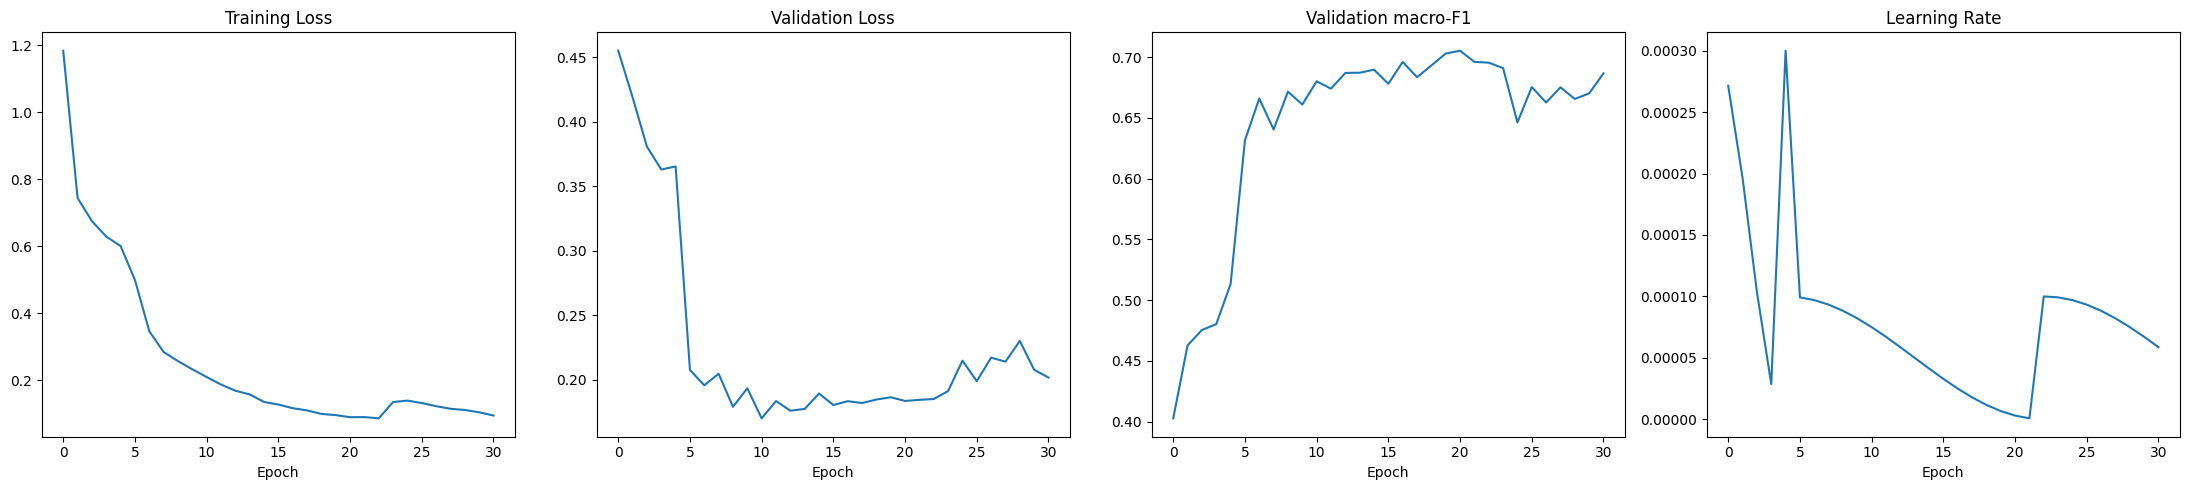

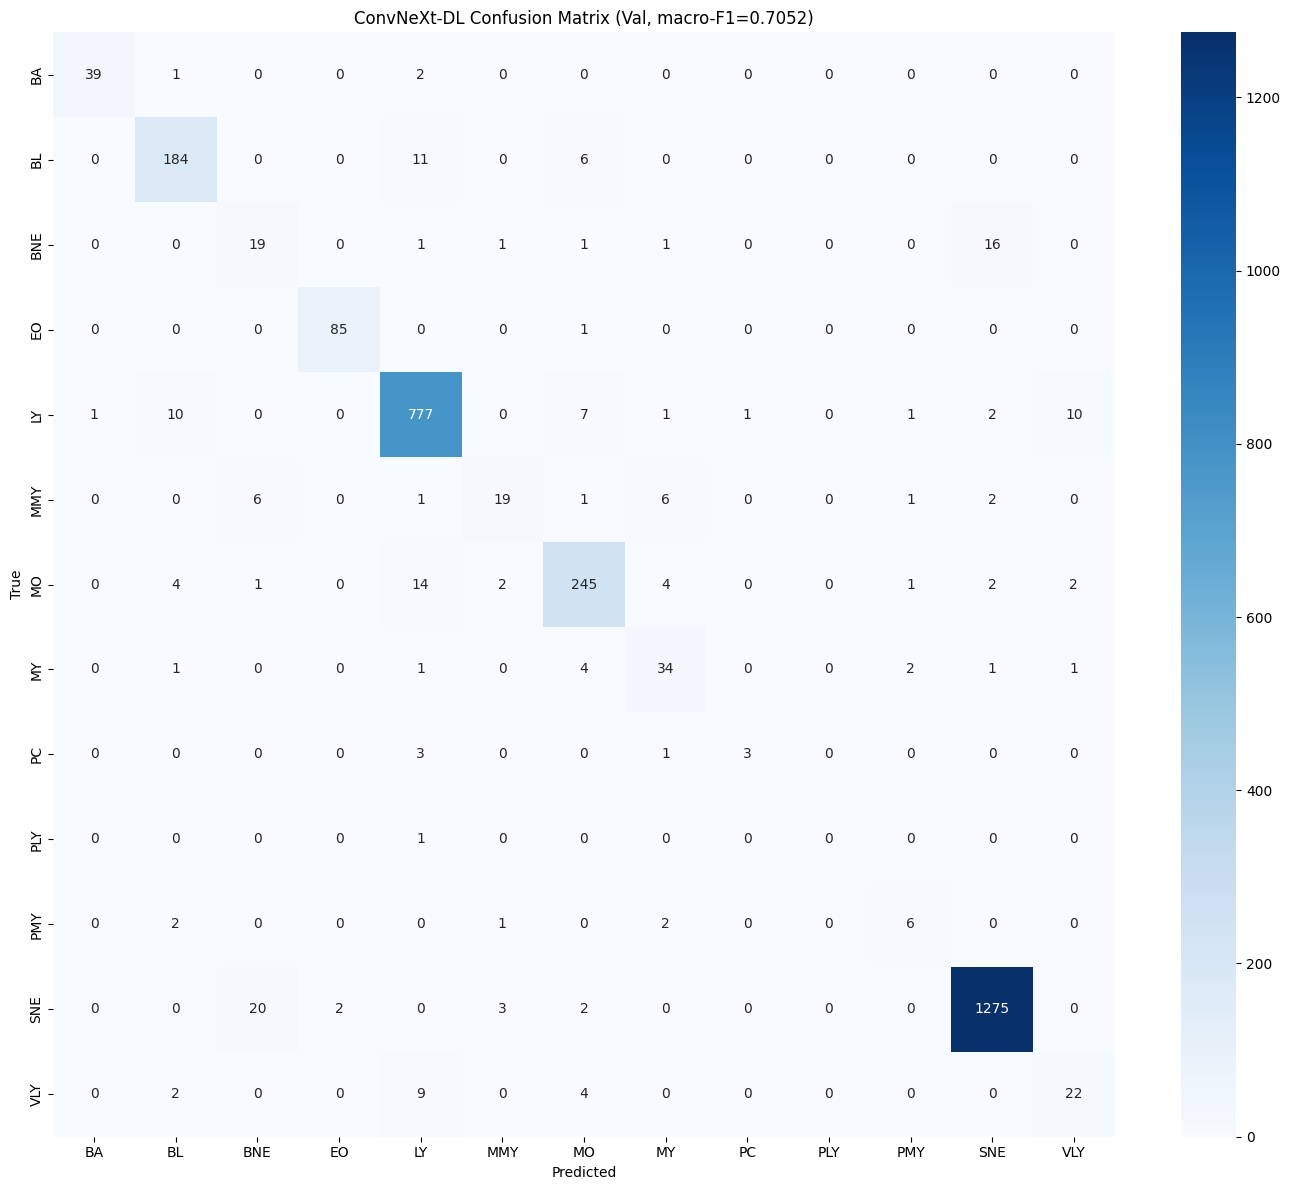

Per-class F1 scores (ConvNeXt-DL):
  BA   (n=   42): F1 = 0.9512
  BL   (n=  201): F1 = 0.9086
  BNE  (n=   39): F1 = 0.4471
  EO   (n=   86): F1 = 0.9827
  LY   (n=  810): F1 = 0.9534
  MMY  (n=   36): F1 = 0.6129
  MO   (n=  275): F1 = 0.8974
  MY   (n=   44): F1 = 0.7312
  PC   (n=    7): F1 = 0.5455
  PLY  (n=    1): F1 = 0.0000
  PMY  (n=   11): F1 = 0.5455
  SNE  (n= 1302): F1 = 0.9808
  VLY  (n=   37): F1 = 0.6111


In [ ]:
# ============================================================
# 7. HYBRID APPROACH: Backbone Features → Random Forest
# ============================================================

print(f"Val backbone features shape: {val_features.shape}")

# ---- Extract train backbone features ----
train_features_list = []
model.eval()
with torch.no_grad():
    for imgs, morph, _ in DataLoader(train_ds, batch_size=BATCH_SIZE,
                                     shuffle=False, num_workers=4, pin_memory=True):
        imgs = imgs.to(device)
        with torch.amp.autocast('cuda'):
            feats = model.extract_features(imgs)
        train_features_list.append(feats.float().cpu().numpy())
train_features = np.concatenate(train_features_list)
train_labels_enc = dl_le.transform(train_fold_df['label'])
print(f"Train backbone features shape: {train_features.shape}")

# ---- Random Forest on backbone features ----
rf = RandomForestClassifier(n_estimators=500, max_depth=None, min_samples_leaf=2,
                             class_weight='balanced', n_jobs=-1, random_state=SEED)
rf.fit(train_features, train_labels_enc)
rf_val_preds = rf.predict(val_features)
rf_val_f1 = f1_score(val_labels, rf_val_preds, average='macro')
print(f"\nHybrid Features+RF val macro-F1:  {rf_val_f1:.4f}")
print(f"DL ConvNeXt val macro-F1:          {val_f1:.4f}")

# ---- Choose best ----
best_approach = max(
    [('ConvNeXt-DL', val_f1, val_preds),
     ('Features+RF', rf_val_f1, rf_val_preds)],
    key=lambda x: x[1]
)
print(f"\n★ Best approach: {best_approach[0]} (macro-F1={best_approach[1]:.4f})")
USE_HYBRID = best_approach[0]
final_val_f1 = best_approach[1]

# ---- Training curves ----
fig, axes = plt.subplots(1, 4, figsize=(22, 5))
for data, ax, title in zip(
    [history['train_loss'], history['val_loss'], history['val_f1'], history['lr']],
    axes, ['Training Loss', 'Validation Loss', 'Validation macro-F1', 'Learning Rate']):
    ax.plot(data)
    ax.set_title(title)
    ax.set_xlabel('Epoch')
plt.tight_layout()
plt.show()

# ---- Confusion Matrix ----
cm = confusion_matrix(val_labels, best_approach[2])
fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=dl_le.classes_, yticklabels=dl_le.classes_, ax=ax)
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
ax.set_title(f'{best_approach[0]} Confusion Matrix (Val, macro-F1={final_val_f1:.4f})')
plt.tight_layout()
plt.show()

# Per-class F1
print(f"Per-class F1 scores ({best_approach[0]}):")
f1_per_class = f1_score(val_labels, best_approach[2], average=None)
for cls_name, f1_val in zip(dl_le.classes_, f1_per_class):
    count = np.sum(val_labels == dl_le.transform([cls_name])[0])
    print(f"  {cls_name:4s} (n={count:5d}): F1 = {f1_val:.4f}")

  DETAILED RESULTS — ConvNeXt-DL (Val set)
  Overall accuracy: 0.9367  |  Macro-F1: 0.7052
  Class     Prec  Recall      F1     Acc  Support  Status
  -----------------------------------------------------------------
  BA       0.975   0.929   0.951   0.929       42  ✓ Good
  BL       0.902   0.915   0.909   0.915      201  ✓ Good
  BNE      0.413   0.487   0.447   0.487       39  ⚠ CRITICAL
  EO       0.977   0.988   0.983   0.988       86  ✓ Good
  LY       0.948   0.959   0.953   0.959      810  ✓ Good
  MMY      0.731   0.528   0.613   0.528       36  ⚠ Weak
  MO       0.904   0.891   0.897   0.891      275  
  MY       0.694   0.773   0.731   0.773       44  
  PC       0.750   0.429   0.545   0.429        7  ⚠ Weak
  PLY      0.000   0.000   0.000   0.000        1  ⚠ CRITICAL
  PMY      0.545   0.545   0.545   0.545       11  ⚠ Weak
  SNE      0.982   0.979   0.981   0.979     1302  ✓ Good
  VLY      0.629   0.595   0.611   0.595       37  ⚠ Weak

  Ranked worst → best:
     1. P

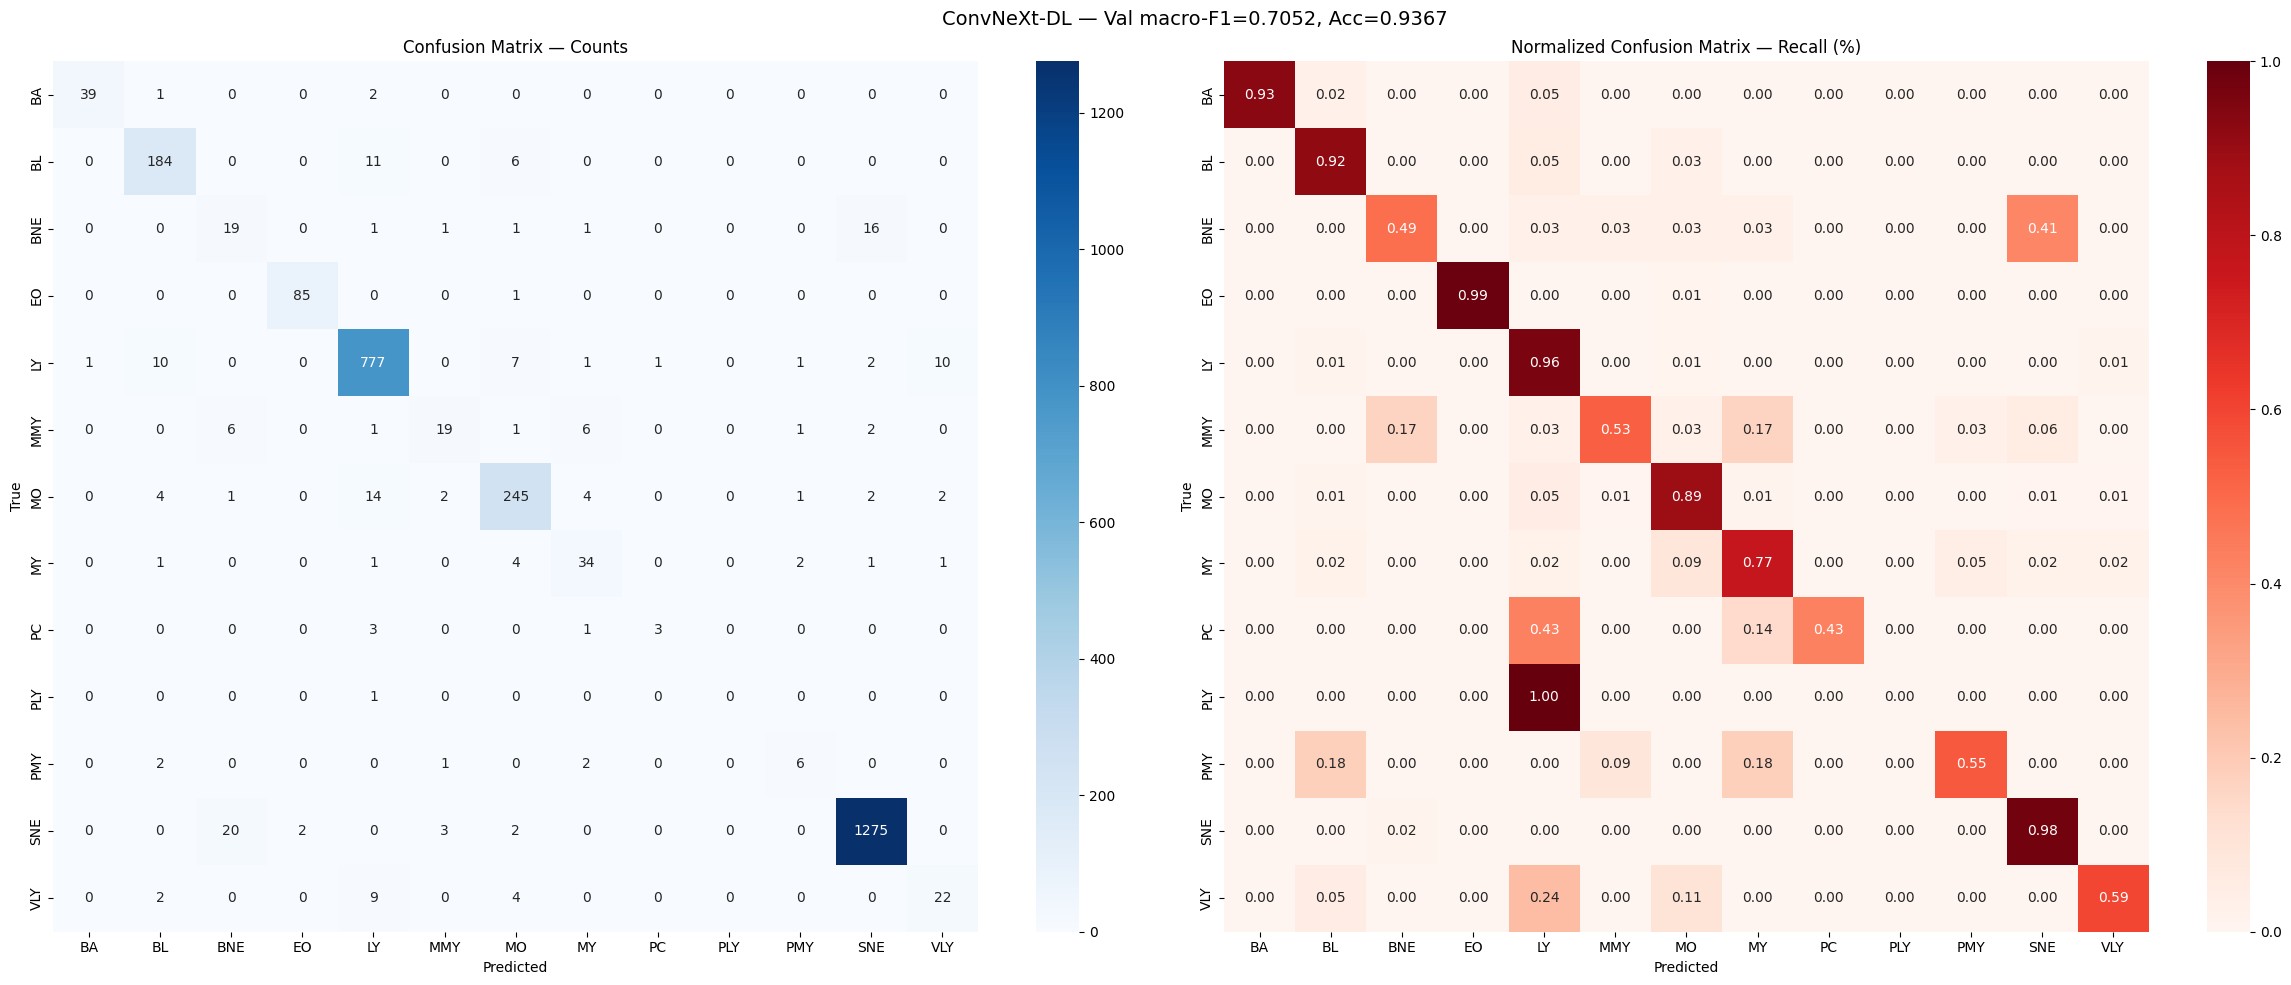


  TOP CONFUSED CLASS PAIRS (off-diagonal errors)
   1. SNE → BNE: 20 errors (1.5% of true SNE)
   2. BNE → SNE: 16 errors (41.0% of true BNE)
   3. MO → LY: 14 errors (5.1% of true MO)
   4. BL → LY: 11 errors (5.5% of true BL)
   5. LY → VLY: 10 errors (1.2% of true LY)
   6. LY → BL: 10 errors (1.2% of true LY)
   7. VLY → LY: 9 errors (24.3% of true VLY)
   8. LY → MO: 7 errors (0.9% of true LY)
   9. MMY → MY: 6 errors (16.7% of true MMY)
  10. MMY → BNE: 6 errors (16.7% of true MMY)


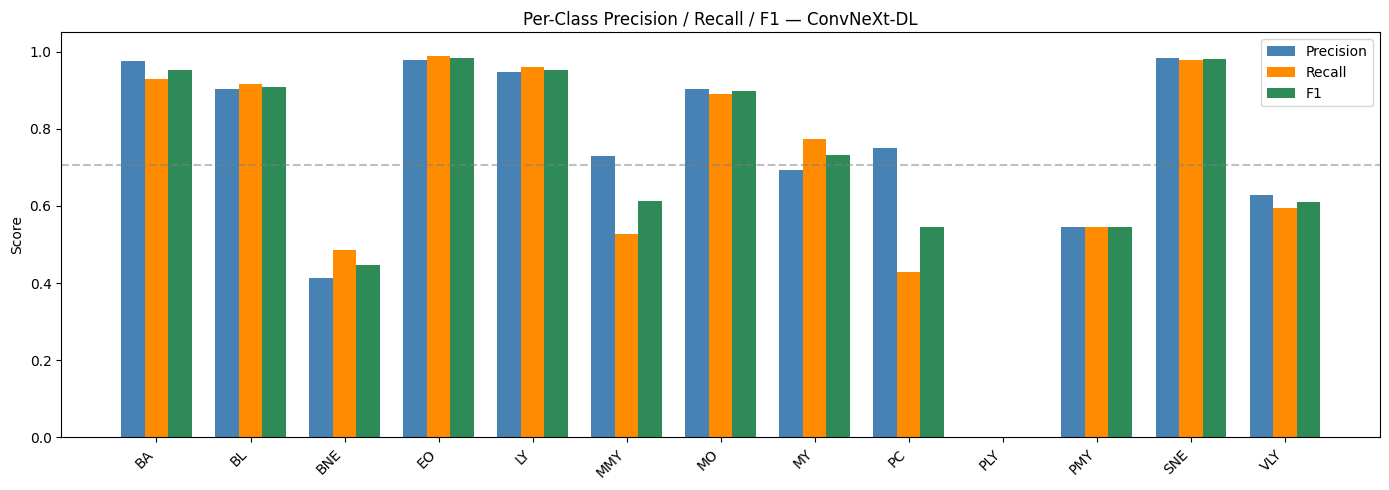


  CONFIDENCE ANALYSIS
  Mean confidence (all):     0.925
  Mean confidence (correct): 0.939
  Mean confidence (wrong):   0.715


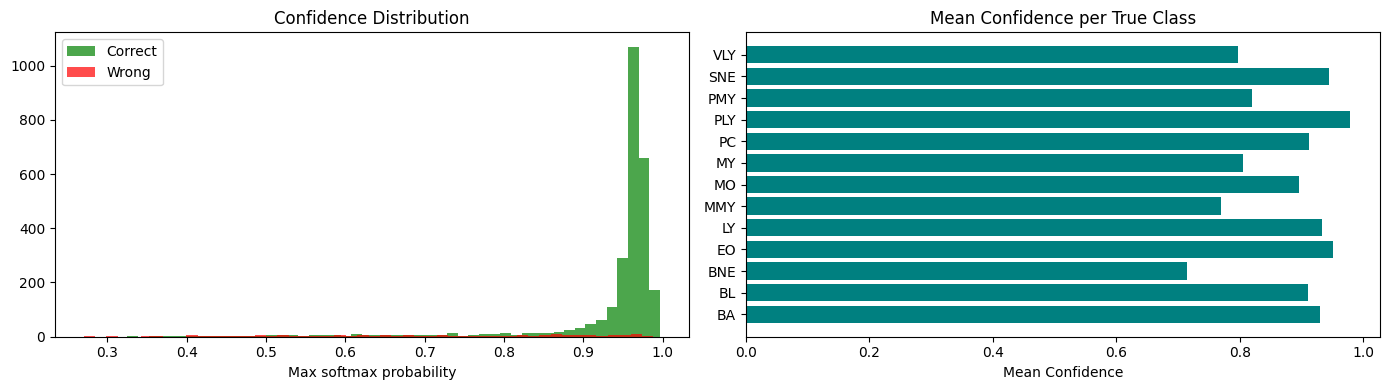


  Predictions with confidence < 0.5: 46 / 2891 (1.6%)
  Low-confidence samples come from:
    MO: 12
    SNE: 7
    MY: 6
    LY: 6
    BNE: 5
    BL: 4
    VLY: 2
    PMY: 1
    BA: 1
    EO: 1
    MMY: 1

  MISCLASSIFIED EXAMPLES (worst errors)


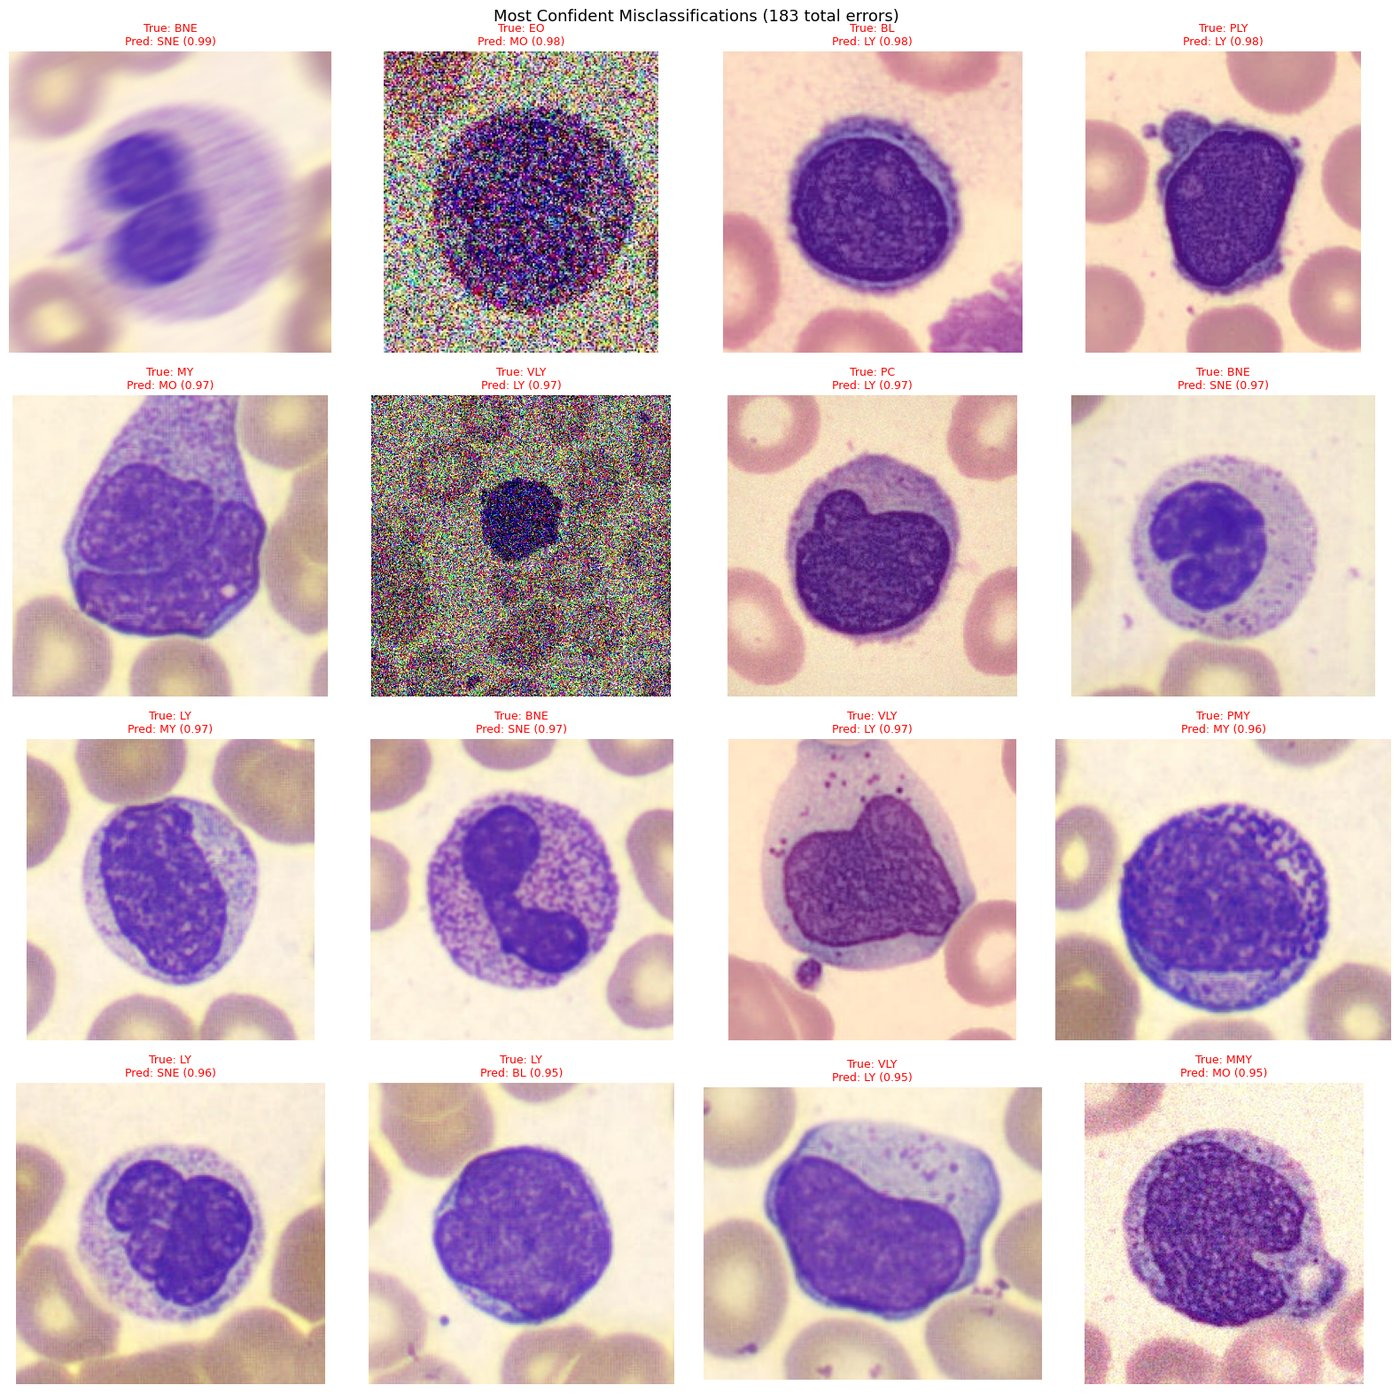


✓ Detailed analysis complete.


In [ ]:
# ============================================================
# 7b. DETAILED RESULTS ANALYSIS
# ============================================================
# Per-class accuracy, precision, recall, F1, support
# Normalized confusion matrix (recall-based)
# Top confused class pairs
# Misclassified examples visualization
# Confidence distribution analysis
# ============================================================

best_preds = best_approach[2]
best_name = best_approach[0]

# ---- 1. Per-class metrics table ----
from sklearn.metrics import precision_recall_fscore_support, accuracy_score

prec, rec, f1_arr, supp = precision_recall_fscore_support(
    val_labels, best_preds, average=None, zero_division=0)

overall_acc = accuracy_score(val_labels, best_preds)
overall_f1 = f1_score(val_labels, best_preds, average='macro')

print(f"{'='*75}")
print(f"  DETAILED RESULTS — {best_name} (Val set)")
print(f"{'='*75}")
print(f"  Overall accuracy: {overall_acc:.4f}  |  Macro-F1: {overall_f1:.4f}")
print(f"{'='*75}")
print(f"  {'Class':<6s}  {'Prec':>6s}  {'Recall':>6s}  {'F1':>6s}  {'Acc':>6s}  {'Support':>7s}  {'Status'}")
print(f"  {'-'*65}")

for i, cls in enumerate(dl_le.classes_):
    cls_mask = val_labels == i
    cls_acc = (best_preds[cls_mask] == i).sum() / max(cls_mask.sum(), 1)
    status = ""
    if f1_arr[i] < 0.5:
        status = "⚠ CRITICAL"
    elif f1_arr[i] < 0.7:
        status = "⚠ Weak"
    elif f1_arr[i] >= 0.9:
        status = "✓ Good"
    print(f"  {cls:<6s}  {prec[i]:>6.3f}  {rec[i]:>6.3f}  {f1_arr[i]:>6.3f}  "
          f"{cls_acc:>6.3f}  {supp[i]:>7d}  {status}")

# Sort by F1 to show worst classes
worst_idx = np.argsort(f1_arr)
print(f"\n  Ranked worst → best:")
for rank, i in enumerate(worst_idx, 1):
    print(f"    {rank:2d}. {dl_le.classes_[i]:<6s} F1={f1_arr[i]:.3f} "
          f"(prec={prec[i]:.3f}, rec={rec[i]:.3f}, n={supp[i]})")

# ---- 2. Normalized Confusion Matrix (recall-based) ----
cm_raw = confusion_matrix(val_labels, best_preds)
cm_norm = cm_raw.astype(float) / cm_raw.sum(axis=1, keepdims=True).clip(min=1)

fig, axes = plt.subplots(1, 2, figsize=(24, 10))

# Raw counts
sns.heatmap(cm_raw, annot=True, fmt='d', cmap='Blues',
            xticklabels=dl_le.classes_, yticklabels=dl_le.classes_, ax=axes[0])
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('True')
axes[0].set_title(f'Confusion Matrix — Counts')

# Normalized (recall per row)
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Reds',
            xticklabels=dl_le.classes_, yticklabels=dl_le.classes_, ax=axes[1])
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('True')
axes[1].set_title(f'Normalized Confusion Matrix — Recall (%)')

plt.suptitle(f'{best_name} — Val macro-F1={overall_f1:.4f}, Acc={overall_acc:.4f}', fontsize=14)
plt.tight_layout()
plt.show()

# ---- 3. Top confused class pairs ----
print(f"\n{'='*60}")
print("  TOP CONFUSED CLASS PAIRS (off-diagonal errors)")
print(f"{'='*60}")
n_errors_shown = 10
errors = []
for true_i in range(num_classes):
    for pred_j in range(num_classes):
        if true_i != pred_j and cm_raw[true_i, pred_j] > 0:
            errors.append((cm_raw[true_i, pred_j],
                          dl_le.classes_[true_i], dl_le.classes_[pred_j],
                          cm_norm[true_i, pred_j]))
errors.sort(reverse=True)
for rank, (cnt, true_cls, pred_cls, rate) in enumerate(errors[:n_errors_shown], 1):
    print(f"  {rank:2d}. {true_cls} → {pred_cls}: {cnt} errors ({rate:.1%} of true {true_cls})")

# ---- 4. Per-class bar chart ----
fig, ax = plt.subplots(figsize=(14, 5))
x = np.arange(num_classes)
width = 0.25
bars_p = ax.bar(x - width, prec, width, label='Precision', color='steelblue')
bars_r = ax.bar(x, rec, width, label='Recall', color='darkorange')
bars_f = ax.bar(x + width, f1_arr, width, label='F1', color='seagreen')
ax.set_xticks(x)
ax.set_xticklabels(dl_le.classes_, rotation=45, ha='right')
ax.set_ylabel('Score')
ax.set_title(f'Per-Class Precision / Recall / F1 — {best_name}')
ax.legend()
ax.axhline(y=overall_f1, color='gray', linestyle='--', alpha=0.5, label=f'Macro-F1={overall_f1:.3f}')
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.show()

# ---- 5. Confidence analysis ----
if val_probs is not None:
    print(f"\n{'='*60}")
    print("  CONFIDENCE ANALYSIS")
    print(f"{'='*60}")

    val_confs = val_probs.max(axis=1)
    val_pred_classes = val_probs.argmax(axis=1)
    correct_mask = val_pred_classes == val_labels

    print(f"  Mean confidence (all):     {val_confs.mean():.3f}")
    print(f"  Mean confidence (correct): {val_confs[correct_mask].mean():.3f}")
    print(f"  Mean confidence (wrong):   {val_confs[~correct_mask].mean():.3f}")

    # Confidence histogram for correct vs wrong
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    axes[0].hist(val_confs[correct_mask], bins=50, alpha=0.7, color='green', label='Correct')
    axes[0].hist(val_confs[~correct_mask], bins=50, alpha=0.7, color='red', label='Wrong')
    axes[0].set_title('Confidence Distribution')
    axes[0].set_xlabel('Max softmax probability')
    axes[0].legend()

    # Per-class mean confidence
    cls_conf = []
    for i in range(num_classes):
        mask = val_labels == i
        cls_conf.append(val_confs[mask].mean() if mask.sum() > 0 else 0)
    axes[1].barh(dl_le.classes_, cls_conf, color='teal')
    axes[1].set_xlabel('Mean Confidence')
    axes[1].set_title('Mean Confidence per True Class')
    plt.tight_layout()
    plt.show()

    # Low confidence predictions (potential errors)
    LOW_CONF_THR = 0.5
    low_conf_mask = val_confs < LOW_CONF_THR
    print(f"\n  Predictions with confidence < {LOW_CONF_THR}: "
          f"{low_conf_mask.sum()} / {len(val_confs)} ({100*low_conf_mask.mean():.1f}%)")
    if low_conf_mask.sum() > 0:
        low_conf_classes = val_labels[low_conf_mask]
        low_conf_dist = pd.Series(dl_le.inverse_transform(low_conf_classes)).value_counts()
        print("  Low-confidence samples come from:")
        for cls, cnt in low_conf_dist.items():
            print(f"    {cls}: {cnt}")

# ---- 6. Show misclassified examples ----
print(f"\n{'='*60}")
print("  MISCLASSIFIED EXAMPLES (worst errors)")
print(f"{'='*60}")

wrong_mask = best_preds != val_labels
wrong_indices = np.where(wrong_mask)[0]

if len(wrong_indices) > 0:
    # Sort by confidence (show most confident wrong predictions first)
    if val_probs is not None:
        wrong_confs = val_probs[wrong_indices].max(axis=1)
        sorted_wrong = wrong_indices[np.argsort(-wrong_confs)]  # highest confidence first
    else:
        sorted_wrong = wrong_indices

    n_show = min(16, len(sorted_wrong))
    ncols = 4
    nrows = (n_show + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 4 * nrows))
    fig.suptitle(f"Most Confident Misclassifications ({len(wrong_indices)} total errors)", fontsize=13)
    axes_flat = axes.flatten() if n_show > ncols else [axes] if n_show == 1 else axes

    for k in range(n_show):
        ax = axes_flat[k] if hasattr(axes_flat, '__len__') else axes_flat
        idx = sorted_wrong[k]
        val_row = val_fold_df.iloc[idx]
        img_path = TRAIN_IMG_DIR / val_row['ID']
        try:
            img = np.array(Image.open(img_path).convert('RGB'))
        except Exception:
            img = np.zeros((100, 100, 3), dtype=np.uint8)

        true_cls = dl_le.inverse_transform([val_labels[idx]])[0]
        pred_cls = dl_le.inverse_transform([best_preds[idx]])[0]
        conf = val_probs[idx].max() if val_probs is not None else 0

        ax = axes_flat[k]
        ax.imshow(img)
        ax.set_title(f"True: {true_cls}\nPred: {pred_cls} ({conf:.2f})",
                     fontsize=9, color='red')
        ax.axis('off')

    # Hide unused axes
    for k in range(n_show, len(axes_flat)):
        axes_flat[k].axis('off')

    plt.tight_layout()
    plt.show()
else:
    print("  No misclassifications!")

print(f"\n✓ Detailed analysis complete.")

### deep_9 summary

| Run | Morphology branch | Val macro-F1 | Accuracy |
|---|---|---|---|
| deep_9 with-morph | 6 features | 0.7036 | 0.9381 |
| **deep_9 no-morph** | none | **0.7052** | **0.9367** |

Macro-F1 difference (with-morph − no-morph): **-0.0016**. The no-morph run is even very
slightly better, which suggests that the handcrafted morphology branch does not help a strong ConvNeXt-Base
backbone. By contrast, zeroing the branch at inference cost 0.0173 macro-F1 for ResNet50 (deep_7, a
slight reliance) and 0.1733 for ResNeXt101 (deep_8, a strong one).

## Summary of the 9 iterations

| Iteration | Backbone | Main change | Val macro-F1 |
|---|---|---|---|
| deep_1 | EfficientNet-B3 | Baseline, weighted CE + TTA | 0.552 (re-run, single 85/15 split) |
| deep_2 | EfficientNet-B3 + CBAM | Nucleus crop + hybrid CNN+SVM | 0.633 |
| deep_3 | same + Late Fusion | Wiener/Laplacian + 4th channel + 8 morphology features | 0.641 |
| deep_4 | same | "Paper 2014" segmentation (regression) | 0.591 |
| deep_5 | ConvNeXt-Base | Focal Loss, CutMix, 2-phase training (data leakage) | 0.822 (invalid) |
| deep_6 | ConvNeXt-Base | Leakage fix — first trustworthy score | 0.6994 |
| deep_7 | ResNet50 + spatial attention | Light Late Fusion, 4 features | 0.6507 |
| deep_8 | ResNeXt101 + CBAM | Multi-task, 6 features | 0.6654 |
| deep_9 with-morph | ConvNeXt-Base + SE gate | Morphology branch (6 features) | 0.7036 |
| **deep_9 no-morph** | **ConvNeXt-Base + SE gate** | **No morphology branch — final model** | **0.7052** |

**Conclusion**: fixing the leak in deep_6 gave the first trustworthy ConvNeXt-Base score
(0.6994). Other backbones (deep_7, deep_8) and more handcrafted features did not beat it. The final
model, deep_9 no-morph, scores 0.7052 (accuracy 0.9367), +0.006 over deep_6, a difference
within the noise of the validation split; the changes are the SE-style attention gate, HSV V-channel CLAHE preprocessing and stronger
augmentation, while the handcrafted morphology branch brings nothing on this backbone. It is
reproduced in `notebooks/04_final_model.ipynb` (evaluation and inference from
`models/best_model.pt`).